In [89]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import protfasta
import os
#os.chdir("..")

# Loading in activities, yeast TF tiles, and sanborn annotations

Yeast TFs are from # Names of yeast TFs from StallerLabShared/LabDocs/proteinSequences/TFs_Yeast/SGDresources/yeast_TFs_MitraLab

Focusing on t = 30 minutes Z-scored results

In [90]:
chopTFs_design = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/ChopYeastTFsDesign.csv", index_col = 0)
chopTFs_design["id"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[0]
chopTFs_design["tile_start"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[1]
chopTFs_design = chopTFs_design.dropna()
chopTFs_design["tile_start"] = chopTFs_design["tile_start"].astype(int)
chopTFs_design["tile_end"] = chopTFs_design["tile_start"] + 40
chopTFs_design = chopTFs_design.rename(columns = {"ADseq" : "seq"})
chopTFs_design = chopTFs_design.drop(columns = ["ArrayDNA", "Name"])
chopTFs_design

,seq,id,tile_start,tile_end
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61
...,...,...,...,...
18413,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451
18414,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456
18415,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461
18416,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466


In [91]:
yeast_TF_lens = pd.DataFrame(chopTFs_design.groupby("id")["tile_start"].max()).reset_index().rename(columns = {"tile_start" : "last_start"})
yeast_TF_lens

,id,last_start
0,YAL051W,1007
1,YAR007C,581
2,YBL021C,104
3,YBL022C,1093
4,YBL054W,485
...,...,...
156,YPR022C,1093
157,YPR052C,53
158,YPR065W,328
159,YPR104C,896


In [92]:
chopTFs_design = pd.merge(chopTFs_design, yeast_TF_lens)
chopTFs_design

,seq,id,tile_start,tile_end,last_start
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41,1007
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46,1007
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51,1007
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56,1007
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61,1007
...,...,...,...,...,...
18412,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451,430
18413,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456,430
18414,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461,430
18415,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466,430


In [93]:
AD_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
AD_activities = AD_activities.rename(columns = {"mean" : "activity", "ADseq" : "seq"})
AD_activities = AD_activities[AD_activities["time"] == 30]
AD_activities["error"] = AD_activities["ci_hi"] - AD_activities["ci_low"]
AD_activities

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294
15,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510
25,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895
35,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885
45,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071
...,...,...,...,...,...,...,...,...,...
118767,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061
118775,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938
118785,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447
118795,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704


In [94]:
# AD_activities_confident = AD_activities[AD_activities["error"] < AD_activities["activity"] * 2]
# AD_activities_confident

In [95]:
merged_activities = AD_activities.merge(
    chopTFs_design,
    on="seq"
)
merged_activities["tile_center"] = merged_activities["tile_start"] + 19
merged_activities

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294,YBR049C,616,656,770,635
1,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510,YBR049C,591,631,770,610
2,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895,YKL032C,221,261,557,240
3,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885,YBR267W,56,96,353,75
4,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071,YKL062W,466,506,590,485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11876,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061,YMR280C,531,571,1393,550
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938,YOR172W,596,636,746,615
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447,YMR016C,171,211,745,190
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704,YPL230W,211,251,351,230


In [96]:
proteins_per_seq = pd.DataFrame(merged_activities[["seq", "id"]].groupby("seq").count()).reset_index().sort_values(by = "id")
proteins_per_seq

,seq,id
11864,YVVDNMNDLKKKGEVKEIIDILKKSYDRLVGENDEQLLFD,1
11865,YVVPEQWPYPQYYQQPQSQSQQQLQSQPQMYQVQESFQSS,1
11866,YVYDPDFTGGVKHLIQIFQILFCLEDSNIPKSNNFENPKL,1
11867,YWIDDPFVLGRIISTMSRRSLDAGLNRWEYYIGQDEDTAE,1
11868,YWLHEVQKSCTDPKACRISTPSEETLTNRKIDEDNGDGLC,1
...,...,...
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,1
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,1
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,1
11880,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,1


In [97]:
# Each tile mapped to an average of 1 protein
np.mean(proteins_per_seq["id"])

1.0

Text(0.5, 1.0, 'ChopTFs')

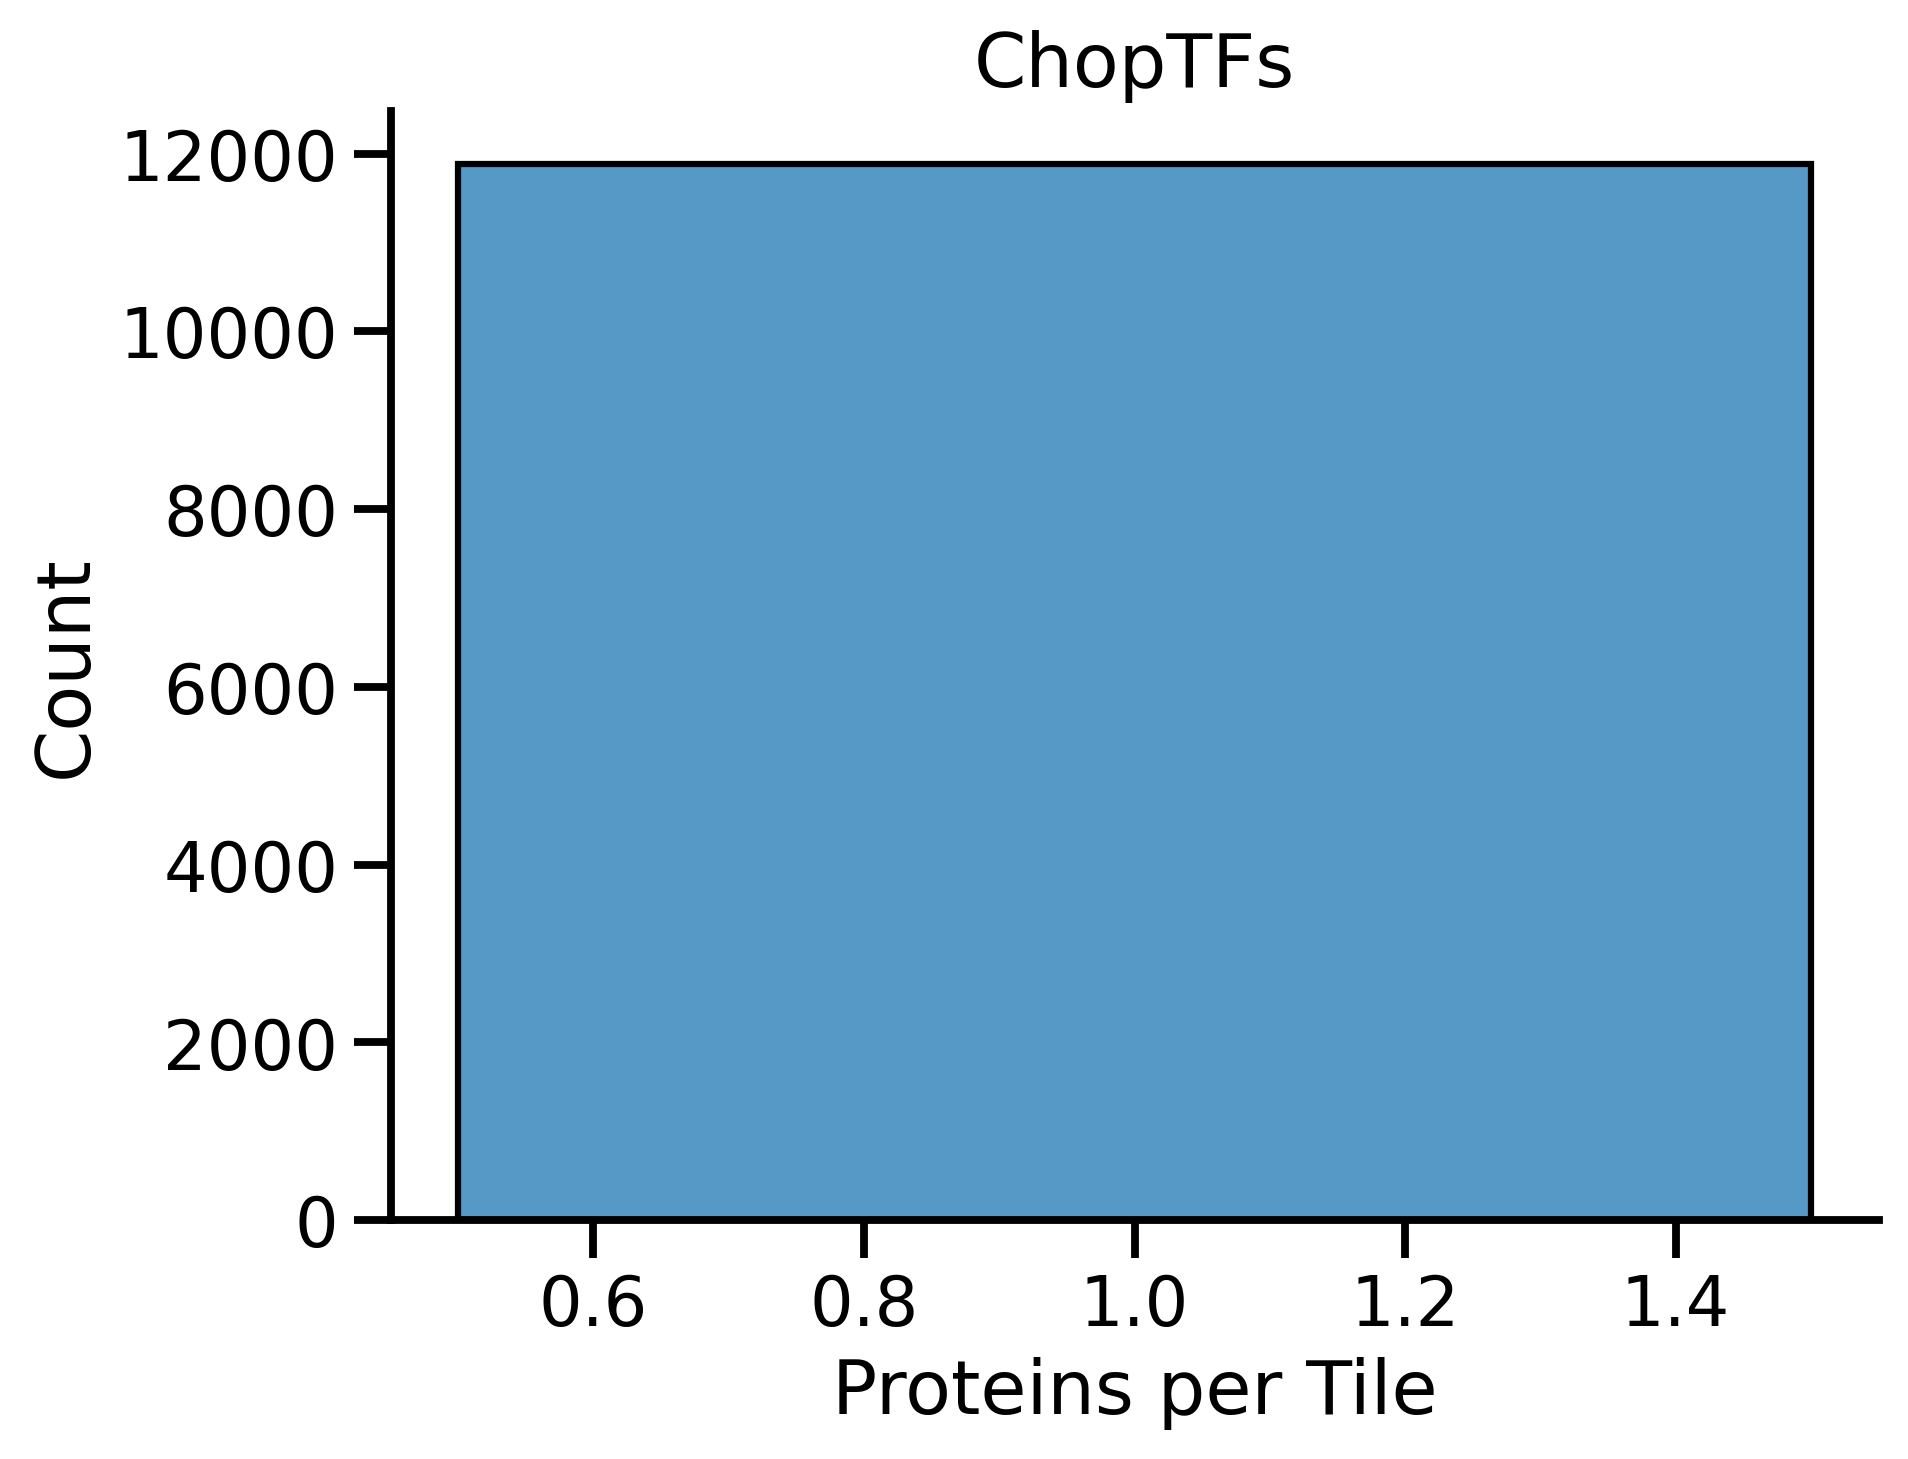

In [98]:
plt.figure(dpi = 300)
sns.histplot(proteins_per_seq["id"], discrete = True)
sns.despine()
plt.xlabel("Proteins per Tile")
plt.title("ChopTFs")

In [99]:
sanborn_ADs = pd.read_excel("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/sanborn_known_ADs_elife-68068-fig1-data2-v3.xlsx")
sanborn_ADs = sanborn_ADs.rename(columns = {"protein ID" : "uniprotID"})
sanborn_ADs

,protein,uniprotID,start,stop,maximal activation,maximal Z score,maximal fragment,sequence
0,GCN4,P03069,63,142,128.273405,11.910003,A_tiles_P03069:76,NLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFE...
1,GAL4,P04386,832,880,44.019965,9.285866,A_tiles_P04386:828,SKPLSPGWTDQTAYNAFGITTGMFNTTTMDDVYNYLFDDEDTPPNPKK
2,GAL4,P04386,146,199,59.660889,10.031831,A_controls-mean_GAL4,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...
3,ARG81,P05085,194,256,32.070085,8.508774,A_tiles_P05085:194,KGHVKTGILSANDGVPPTPNLLDYDWNNLNITGYEWISSELRDDAL...
4,ARG81,P05085,69,126,13.391200,6.366012,A_tiles_P05085:65,IPQNSPATTTNLSGSVDEPQYQRRNIDFVRYDEEYVYHEDMDDELT...
...,...,...,...,...,...,...,...,...
145,YRM1,Q12340,737,785,73.486889,10.543228,A_tiles_Q12340:733,SENASHNNETGPIETELAQTISNEFWTAYNLGWEELMSQPDYKYLFDT
146,YRM1,Q12340,184,241,21.275056,7.501859,A_tiles_Q12340:193,PLEKTGSDILQQVCNVLPSFEQSSKIITDFFNTELETNEVSEVLDK...
147,HAA1,Q12753,658,693,35.587427,8.764113,A_tiles_Q12753:641,DLPDTSPMSSIQTASPPSQLLTDQGFADLDNFMSS
148,HAA1,Q12753,274,335,28.366703,8.207702,A_tiles_Q12753:282,NSRVGEVSVPLEEYIPSDIDGVGRVTDKSSLVYDWPFDESIERNFS...


In [100]:
min(sanborn_ADs["maximal Z score"])

3.48846111960084

In [101]:
min(sanborn_ADs["sequence"].str.len())

22

In [102]:
sanborn_ADs["sequence"].str.len().value_counts().sort_index()

22      3
35     12
36      2
44      1
47      1
48     14
49      7
52     11
53     19
56      2
57      5
58      3
59      2
60      5
61      6
62     12
64      1
65      6
66      7
70      1
71      1
73      1
74      7
75      3
76      1
79      2
82      1
86      1
87      2
91      1
92      1
95      2
96      1
100     1
111     1
117     1
118     1
124     1
129     1
Name: sequence, dtype: int64

In [103]:
len(sanborn_ADs["uniprotID"].unique())

96

In [104]:
tiles = []

for _, row in sanborn_ADs.iterrows():
    tf_id = row["uniprotID"]
    seq = row["sequence"]

    for i in range(len(seq) - 39):   # 40-mer window
        tile = seq[i:i+40]
        tiles.append({
            "seq": tile,
            "uniprotID": tf_id,
            "tile_start": i + 1,
            "tile_end": i + 40
        })

sanborn_tiles_df = pd.DataFrame(tiles)
sanborn_tiles_df["sanborn"] = "yes"
sanborn_tiles_df

,seq,uniprotID,tile_start,tile_end,sanborn
0,NLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTD,P03069,1,40,yes
1,LDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDS,P03069,2,41,yes
2,DFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDST,P03069,3,42,yes
3,FDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTP,P03069,4,43,yes
4,DFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPM,P03069,5,44,yes
...,...,...,...,...,...
3209,SLQSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHS,Q12753,18,57,yes
3210,LQSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSN,Q12753,19,58,yes
3211,QSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSNH,Q12753,20,59,yes
3212,SSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSNHQ,Q12753,21,60,yes


In [105]:
len(sanborn_tiles_df["uniprotID"].unique())

85

In [106]:
merged_activities_with_sanborn = merged_activities.merge(
    sanborn_tiles_df[["seq", "sanborn"]],
    on="seq",
    how="left"
)
merged_activities_with_sanborn["sanborn"] = merged_activities_with_sanborn["sanborn"].fillna("no")
merged_activities_with_sanborn

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center,sanborn
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294,YBR049C,616,656,770,635,no
1,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510,YBR049C,591,631,770,610,no
2,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895,YKL032C,221,261,557,240,no
3,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885,YBR267W,56,96,353,75,no
4,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071,YKL062W,466,506,590,485,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11876,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061,YMR280C,531,571,1393,550,no
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938,YOR172W,596,636,746,615,no
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447,YMR016C,171,211,745,190,no
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704,YPL230W,211,251,351,230,no


In [107]:
len(merged_activities_with_sanborn["id"].unique())

161

In [108]:
activator_ids = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"]["id"].unique()
len(activator_ids)

112

In [109]:
merged_activities_with_sanborn_activators = merged_activities_with_sanborn[merged_activities_with_sanborn["id"].isin(activator_ids)]
merged_activities_with_sanborn_activators = merged_activities_with_sanborn_activators.sort_values(by = ["id", "last_start"])
merged_activities_with_sanborn_activators

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center,sanborn
253,ALFDVIVQRMRKGELWHGIFTMIQMEQMHSRIIKTLSITL,30,0.102826,-0.116562,0.268878,ns,NaN,NaN,0.385440,YAL051W,836,876,1007,855,no
287,AMKLLTEREVNESGKRSASPINTNNASGDSPDTKKQHKME,30,-0.725844,-1.015244,-0.453333,ns,-0.219307,0.211242,0.561910,YAL051W,126,166,1007,145,no
303,ANFSVEDIDELNRNIKKEIQISSGLKPPVNTIDLTNGEPF,30,0.586033,0.501576,0.731945,ns,NaN,NaN,0.230369,YAL051W,896,936,1007,915,no
438,ASENWCACANENIISCLLYIWSFFAFSPEEGDFFLEHPTD,30,0.428499,-0.016103,0.759183,ns,NaN,NaN,0.775285,YAL051W,451,491,1007,470,no
560,AVFLHFETLITKDKSIFPFYKKYFMVSCMDALSLINYFNK,30,0.048562,-0.134961,0.233084,ns,-0.143054,0.271540,0.368045,YAL051W,691,731,1007,710,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11479,VYIKCVTSLDTTISPPQPEIVTDSRLSLDSFLEVIKVFTV,30,0.186803,-0.165304,0.527062,ns,0.232772,0.469328,0.692367,YPR196W,241,281,430,260,no
11604,YDHNMKLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQS,30,-0.099001,-0.300222,0.055597,ns,0.014028,0.986975,0.355819,YPR196W,406,446,430,425,no
11618,YDVHGPVIPMKALEIANALVDVVSKYDHNMKLEAWNILCD,30,0.411517,-0.160687,1.125879,ns,0.352830,0.290085,1.286567,YPR196W,381,421,430,400,no
11726,YLQPLRKRGPKSIGESNLERAAEIQMVTVNNNIMAAPVMY,30,0.196777,-0.013827,0.486479,ns,NaN,NaN,0.500307,YPR196W,36,76,430,55,no


# Counting intervals

In [110]:
def intervals_overlap(a_start, a_end, b_start, b_end):
    return (a_start <= b_end) and (b_start <= a_end)

In [111]:
def merge_intervals(df, min_len=None):
    merged = []
    for uid, group in df.groupby("id"):
        intervals = group[["tile_start", "tile_end"]].sort_values("tile_start").to_numpy()
        current_start, current_end = intervals[0]
        for start, end in intervals[1:]:
            if start < current_end:
                current_end = max(current_end, end)
            else:
                merged.append((uid, current_start, current_end))
                current_start, current_end = start, end
        merged.append((uid, current_start, current_end))
    
    merged = np.array(merged, dtype=object)
    
    if min_len is not None:
        lengths = merged[:, 2].astype(float) - merged[:, 1].astype(float)
        merged = merged[lengths >= min_len]
    
    return merged

In [112]:
sanborn = merged_activities_with_sanborn[merged_activities_with_sanborn["sanborn"] == "yes"].copy()

In [113]:
sanborn_merged = merge_intervals(sanborn)
len(sanborn_merged)

98

In [114]:
our_activators = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"].copy()
our_activators_merged = merge_intervals(our_activators)
len(our_activators_merged)

267

In [115]:
our_repressors = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "repressor"].copy()
our_repressors_merged = merge_intervals(our_repressors)
len(our_repressors_merged)

13

In [116]:
def compare_intervals(a, b, names=("A", "B")):
    a = np.array(a)
    b = np.array(b)

    overlap_matrix = (
        (a[:, None, 0] == b[None, :, 0]) &
        (a[:, None, 1].astype(float) < b[None, :, 2].astype(float)) &
        (b[None, :, 1].astype(float) < a[:, None, 2].astype(float))  # fix here
    )

    a_overlap = overlap_matrix.any(axis=1).sum()
    b_overlap = overlap_matrix.any(axis=0).sum()
    a_missed  = len(a) - a_overlap
    b_missed  = len(b) - b_overlap

    print(f"{names[0]} intervals overlapping {names[1]}: {a_overlap} / {len(a)} ({100*a_overlap/len(a):.1f}%)")
    print(f"{names[0]} intervals missed by {names[1]}:  {a_missed} / {len(a)} ({100*a_missed/len(a):.1f}%)")
    print(f"{names[1]} intervals overlapping {names[0]}: {b_overlap} / {len(b)} ({100*b_overlap/len(b):.1f}%)")
    print(f"{names[1]} intervals missed by {names[0]}:  {b_missed} / {len(b)} ({100*b_missed/len(b):.1f}%)")

    return overlap_matrix


In [117]:
compare_intervals(our_activators_merged, sanborn_merged, names=("Our Activators", "Sanborn"));

Our Activators intervals overlapping Sanborn: 92 / 267 (34.5%)
Our Activators intervals missed by Sanborn:  175 / 267 (65.5%)
Sanborn intervals overlapping Our Activators: 90 / 98 (91.8%)
Sanborn intervals missed by Our Activators:  8 / 98 (8.2%)


In [118]:
compare_intervals(our_repressors_merged, sanborn_merged, names=("Our Repressors", "Sanborn"));

Our Repressors intervals overlapping Sanborn: 1 / 13 (7.7%)
Our Repressors intervals missed by Sanborn:  12 / 13 (92.3%)
Sanborn intervals overlapping Our Repressors: 1 / 98 (1.0%)
Sanborn intervals missed by Our Repressors:  97 / 98 (99.0%)


In [119]:
overlap_matrix = compare_intervals(our_activators_merged, our_repressors_merged, names=("Our Activators", "Our Repressors"));

Our Activators intervals overlapping Our Repressors: 4 / 267 (1.5%)
Our Activators intervals missed by Our Repressors:  263 / 267 (98.5%)
Our Repressors intervals overlapping Our Activators: 3 / 13 (23.1%)
Our Repressors intervals missed by Our Activators:  10 / 13 (76.9%)


In [120]:
overlap_matrix = compare_intervals(our_activators_merged, our_repressors_merged, names=("Activators", "Repressors"))

our_activators_overlapping_repressors = our_activators_merged[overlap_matrix.any(axis=1)]
our_activators_overlapping_repressors

Activators intervals overlapping Repressors: 4 / 267 (1.5%)
Activators intervals missed by Repressors:  263 / 267 (98.5%)
Repressors intervals overlapping Activators: 3 / 13 (23.1%)
Repressors intervals missed by Activators:  10 / 13 (76.9%)


array([['YDR216W', 401, 461],
       ['YIL101C', 291, 346],
       ['YPL248C', 76, 116],
       ['YPL248C', 141, 206]], dtype=object)

In [121]:
our_repressors_overlapping_activators = our_repressors_merged[overlap_matrix.any(axis=0)]
our_repressors_overlapping_activators

array([['YDR216W', 381, 421],
       ['YIL101C', 331, 371],
       ['YPL248C', 106, 146]], dtype=object)

In [122]:
# Per max slack 5/13/25
rds2_search = pd.DataFrame(our_activators_merged)
rds2_search[rds2_search[0] == "YPL133C"]

,0,1,2
250,YPL133C,101,171
251,YPL133C,261,301


# RD Overlap?

Ash1
Matα2
Mig1
Rap1
Rgt1
Rme1
Rox1
Ume6

YKL185W
YCR039C
YGL035C
YNL216W
YKL038W
YGR044C
YPR065W
YDR207C

In [123]:
RD_ids = ["YKL185W", "YCR039C", "YGL035C", "YNL216W", "YKL038W", "YGR044C", "YPR065W", "YDR207C"]
RD_ids

['YKL185W',
 'YCR039C',
 'YGL035C',
 'YNL216W',
 'YKL038W',
 'YGR044C',
 'YPR065W',
 'YDR207C']

In [124]:
our_repressors_merged_df = pd.DataFrame(our_repressors_merged)
our_repressors_merged_df

,0,1,2
0,YAR007C,456,496
1,YCR039C,76,116
2,YCR096C,66,106
3,YDL048C,121,171
4,YDL056W,36,76
5,YDR216W,381,421
6,YIL101C,331,371
7,YKL038W,576,616
8,YKL185W,341,381
9,YNL068C,411,451


In [125]:
our_repressors_merged_df[our_repressors_merged_df[0].isin(RD_ids)]

,0,1,2
1,YCR039C,76,116
7,YKL038W,576,616
8,YKL185W,341,381


# 1. Loess

In [126]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import pearsonr

WINDOW = 40  # your tile size


# ------------------------------------------------------------
# 1. FIXED TILE EXPANSION (for overlap method)
# ------------------------------------------------------------
def build_overlap_profile(df):
    results = []

    for pid, g in df.groupby("id"):
        pos_vals = defaultdict(list)

        for _, r in g.iterrows():
            start = int(r["tile_start"])
            end = start + WINDOW - 1  # IMPORTANT FIX

            for p in range(start, end + 1):
                pos_vals[p].append(r["activity"])

        positions = np.array(sorted(pos_vals.keys()))
        values = np.array([np.mean(pos_vals[p]) for p in positions])

        results.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "activity_overlap": values
        }))

    return pd.concat(results, ignore_index=True)


# ------------------------------------------------------------
# 2. FIXED-K LOESS (matches "20 nearest points" idea)
# ------------------------------------------------------------
def loess_per_protein(df, k=5):
    out = []

    for pid, g in df.groupby("id"):
        g = g.sort_values("tile_center")

        x = g["tile_center"].values
        y = g["activity"].values

        frac = min(1.0, k / len(g))  # fixed-k approximation

        smooth = lowess(y, x, frac=frac, it=1, return_sorted=False)

        # clamp to observed range (paper step)
        smooth = np.clip(smooth, y.min(), y.max())

        out.append(pd.DataFrame({
            "id": pid,
            "tile_center": x,
            "activity_loess": smooth
        }))

    return pd.concat(out, ignore_index=True)


# ------------------------------------------------------------
# 3. EXPAND LOESS TO POSITION SCALE
# ------------------------------------------------------------
def expand_loess_to_positions(df_loess, df_raw):
    out = []

    for pid, g in df_loess.groupby("id"):
        raw = df_raw[df_raw["id"] == pid]

        min_pos = raw["tile_start"].min()
        max_pos = (raw["tile_start"] + WINDOW - 1).max()

        positions = np.arange(min_pos, max_pos + 1)

        x = g["tile_center"].values
        y = g["activity_loess"].values

        # extend domain to full tile coverage instead of just tile centers
        f = np.full_like(positions, np.nan, dtype=float)
        valid = (positions >= min_pos) & (positions <= max_pos)
        f[valid] = np.interp(positions[valid], x, y)

        out.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "activity_loess_pos": f
        }))

    return pd.concat(out, ignore_index=True)

# ------------------------------------------------------------
# 4. COVERAGE MASK (CRITICAL for fair comparison)
# ------------------------------------------------------------
def compute_coverage(df):
    cov = Counter()

    for _, r in df.iterrows():
        start = int(r["tile_start"])
        end = start + WINDOW - 1

        for p in range(start, end + 1):
            cov[p] += 1

    return cov


# ------------------------------------------------------------
# 5. MERGE + VALID CORRELATION
# ------------------------------------------------------------
def compare_methods(df, loess_pos, overlap_pos):
    merged = loess_pos.merge(overlap_pos, on=["id", "position"])

    results = []

    for pid, g in merged.groupby("id"):
        cov = compute_coverage(df[df["id"] == pid])

        # ---------------------------
        # DEFINE SHARED VALID DOMAIN
        # ---------------------------
        valid = g["position"].map(lambda p: cov[p] >= 2)
        g = g[valid].dropna()

        if len(g) < 10:
            continue

        x = g["activity_loess_pos"].values
        y = g["activity_overlap"].values

        # normalize per protein
        x = (x - x.mean()) / (x.std() + 1e-8)
        y = (y - y.mean()) / (y.std() + 1e-8)

        r, _ = pearsonr(x, y)

        results.append((pid, r))

    return pd.DataFrame(results, columns=["id", "pearson_r"])


def filter_to_high_confidence(overlap, loess_pos, df, min_coverage=2):
    cov_rows = []
    for _, r in df.iterrows():
        start = int(r["tile_start"])
        for p in range(start, start + WINDOW):
            cov_rows.append((r["id"], p))
    
    cov_df = (pd.DataFrame(cov_rows, columns=["id", "position"])
                .groupby(["id", "position"])
                .size()
                .reset_index(name="coverage"))  # explicit name, works all pandas versions

    overlap_hc = overlap.merge(cov_df, on=["id", "position"])
    overlap_hc = overlap_hc[overlap_hc["coverage"] >= min_coverage]

    loess_hc = loess_pos.merge(cov_df, on=["id", "position"])
    loess_hc = loess_hc[loess_hc["coverage"] >= min_coverage].dropna(subset=["activity_loess_pos"])

    return overlap_hc, loess_hc
    
# ------------------------------------------------------------
# 6. ONE-CALL PIPELINE
# ------------------------------------------------------------
def run_pipeline(df):
    overlap = build_overlap_profile(df)
    loess = loess_per_protein(df, k=5)
    loess_pos = expand_loess_to_positions(loess, df)
    summary = compare_methods(df, loess_pos, overlap)

    overlap_hc, loess_hc = filter_to_high_confidence(overlap, loess_pos, df)

    return overlap_hc, loess, loess_hc, summary

In [166]:
overlap, loess, loess_pos, summary = run_pipeline(merged_activities_with_sanborn)

(summary["pearson_r"] > 0.8).mean()

0.9503105590062112

In [167]:
summary[summary["pearson_r"] < 0.8]

,id,pearson_r
20,YCR097W,0.792693
26,YDL170W,0.737337
28,YDR043C,0.766218
34,YDR253C,0.298312
56,YGL013C,0.780331
77,YIR013C,0.468540
98,YKR034W,0.779416
114,YML027W,0.763052


In [168]:
summary[summary["pearson_r"] > 0.8].sort_values(by = "pearson_r")

,id,pearson_r
76,YIL131C,0.804203
157,YPR052C,0.804204
35,YDR259C,0.809134
111,YLR375W,0.815557
6,YBR033W,0.820461
...,...,...
140,YOR298C-A,0.974661
73,YIL036W,0.975935
42,YEL009C,0.975991
88,YKL015W,0.978860


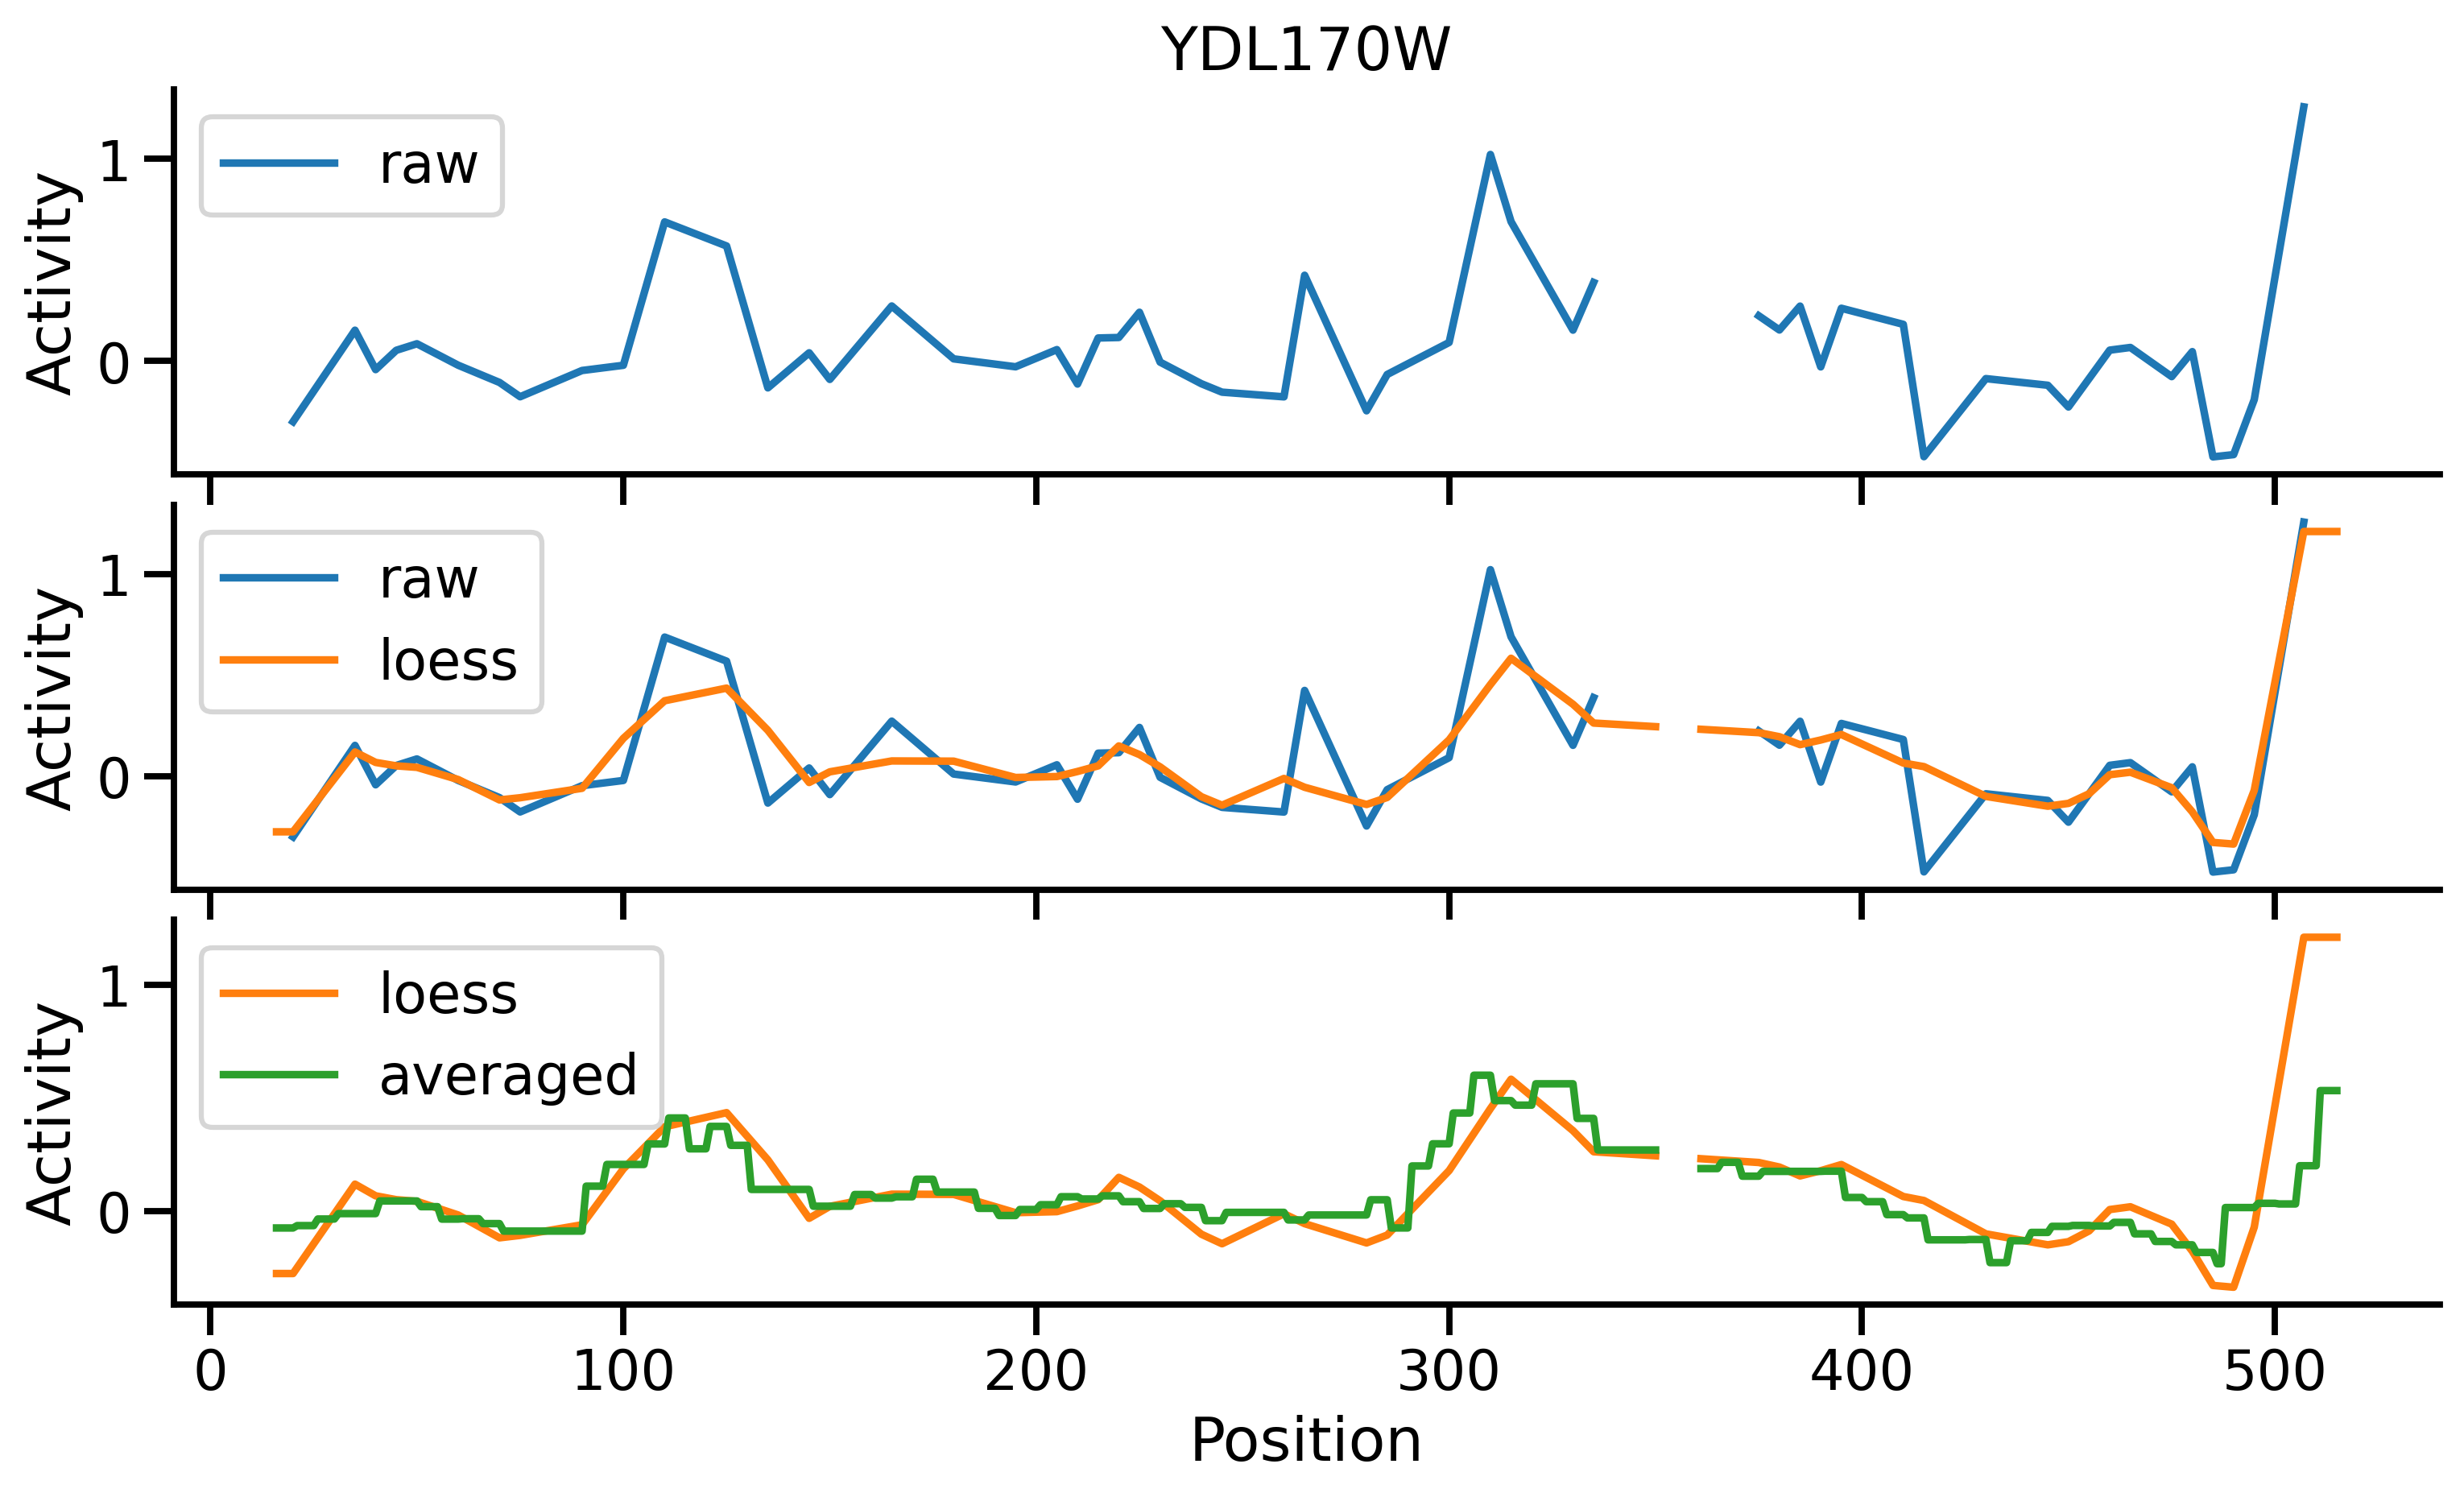

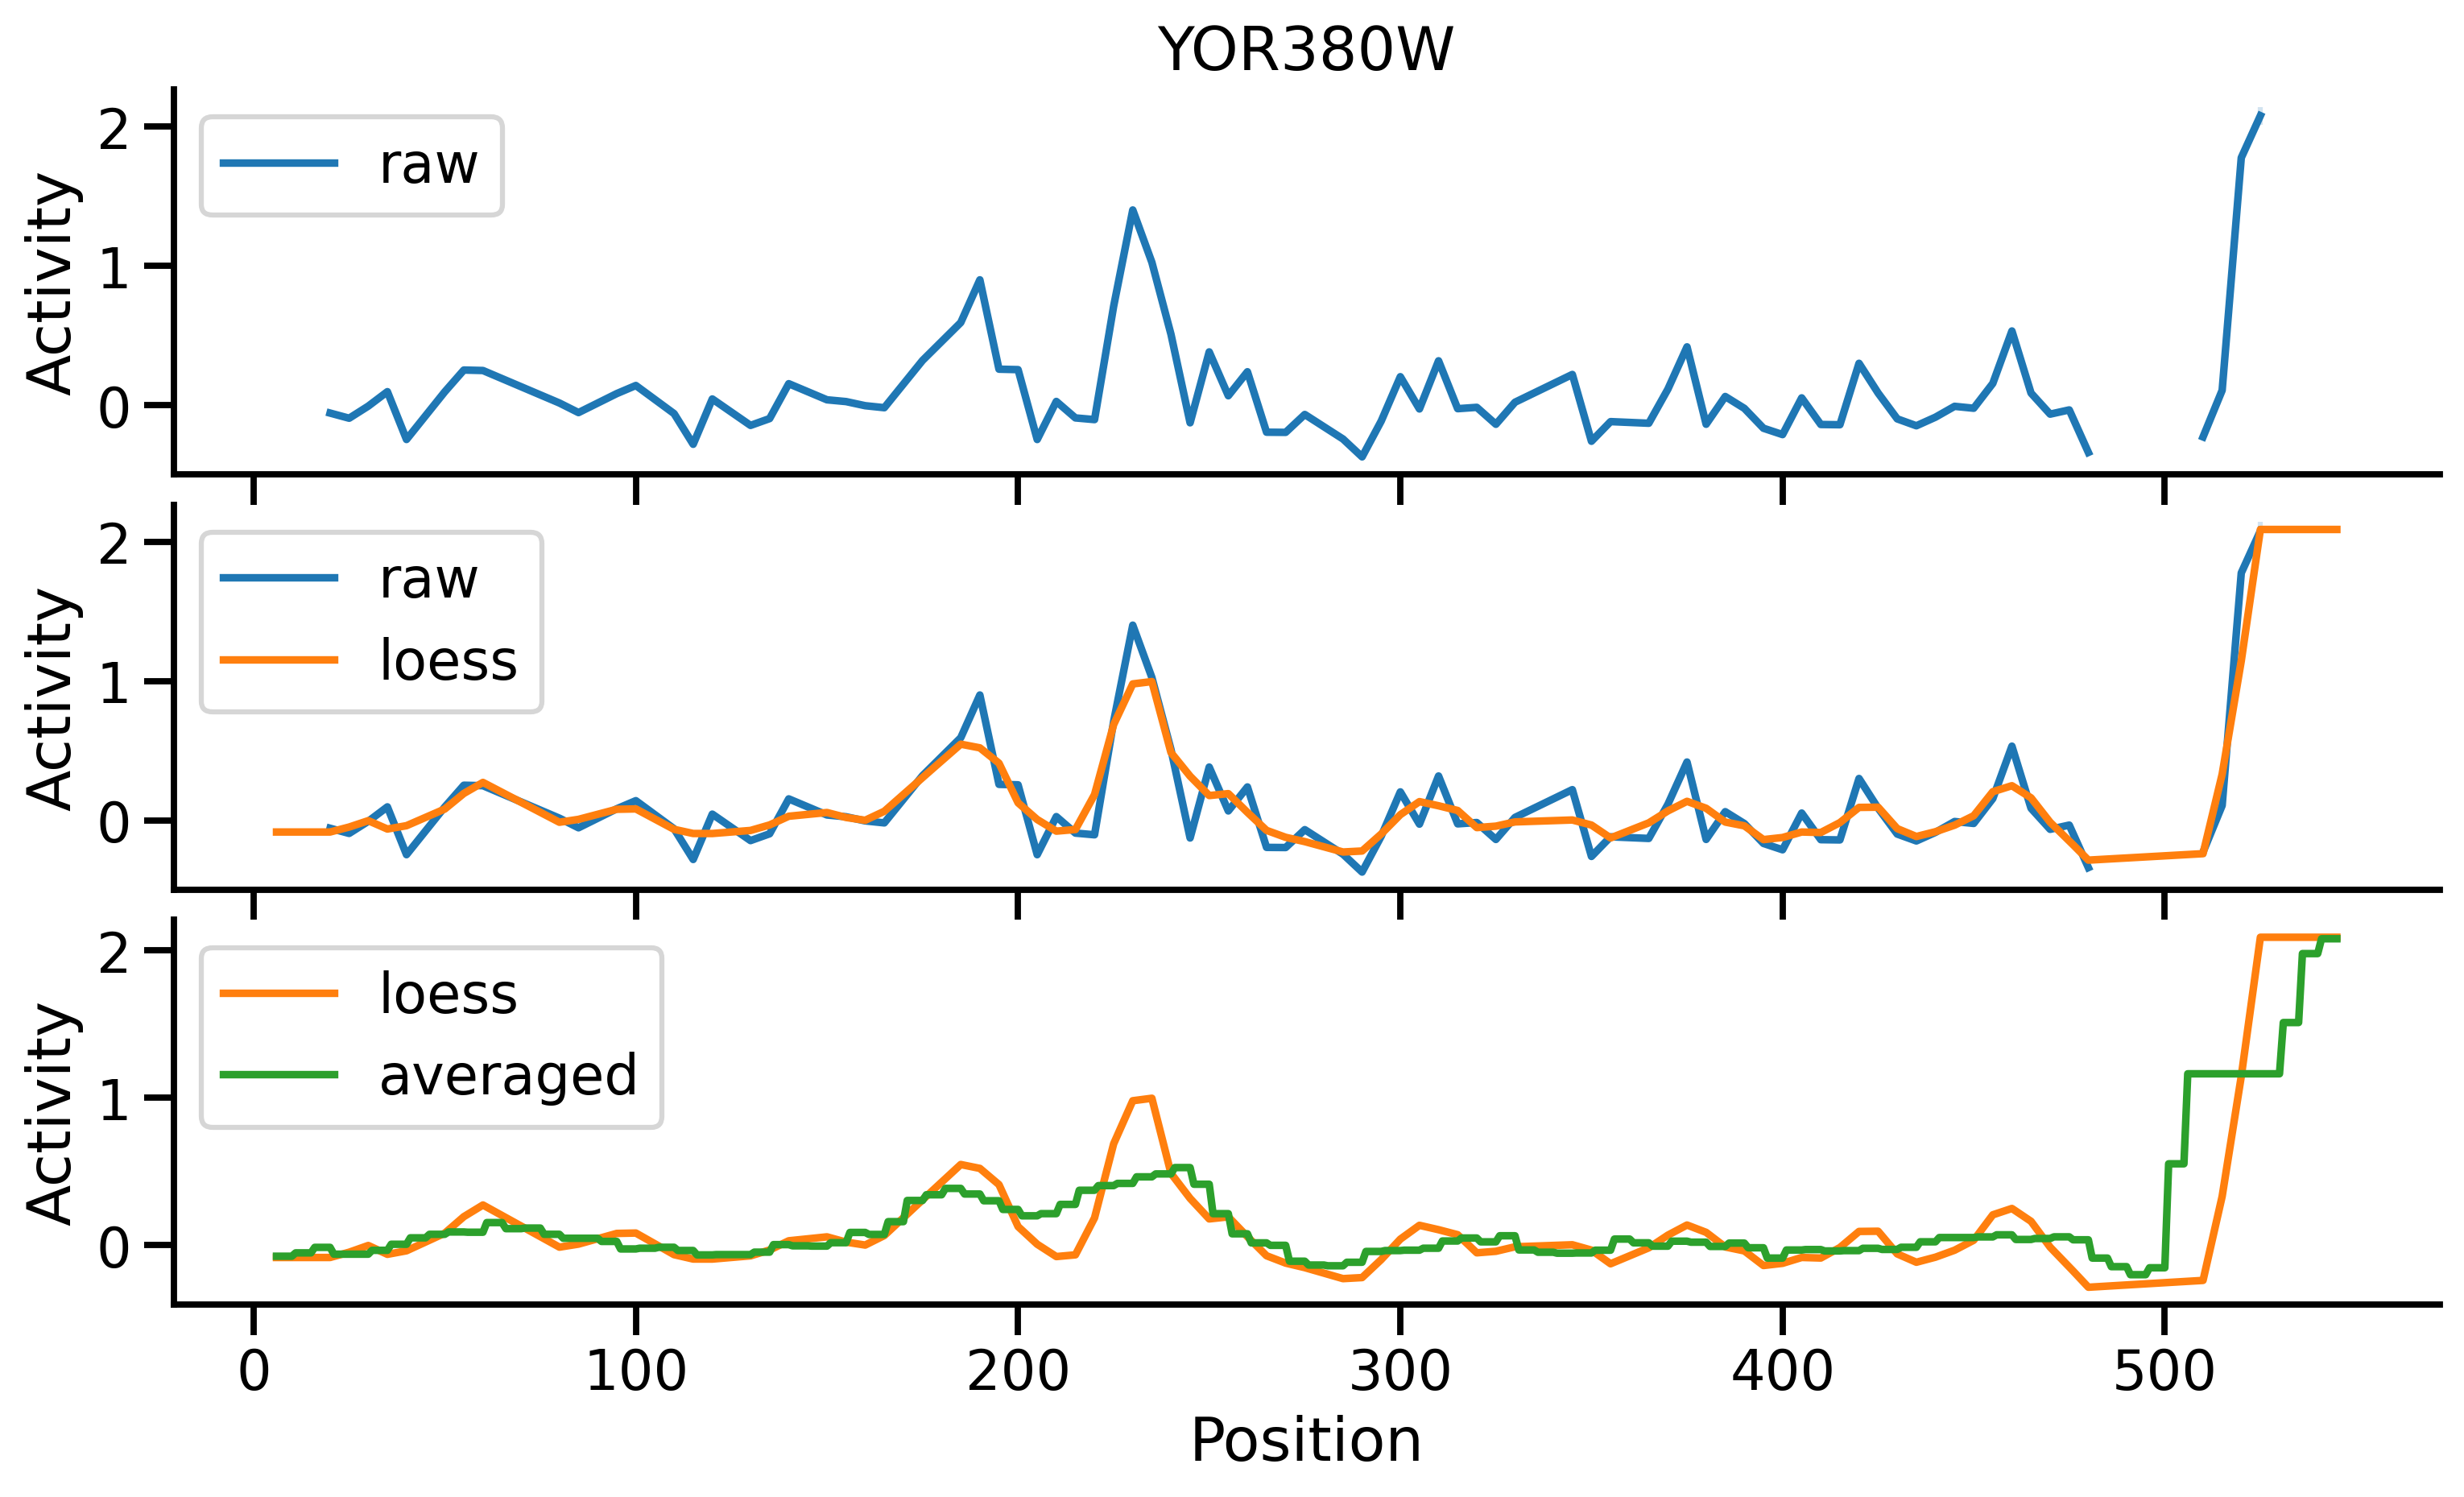

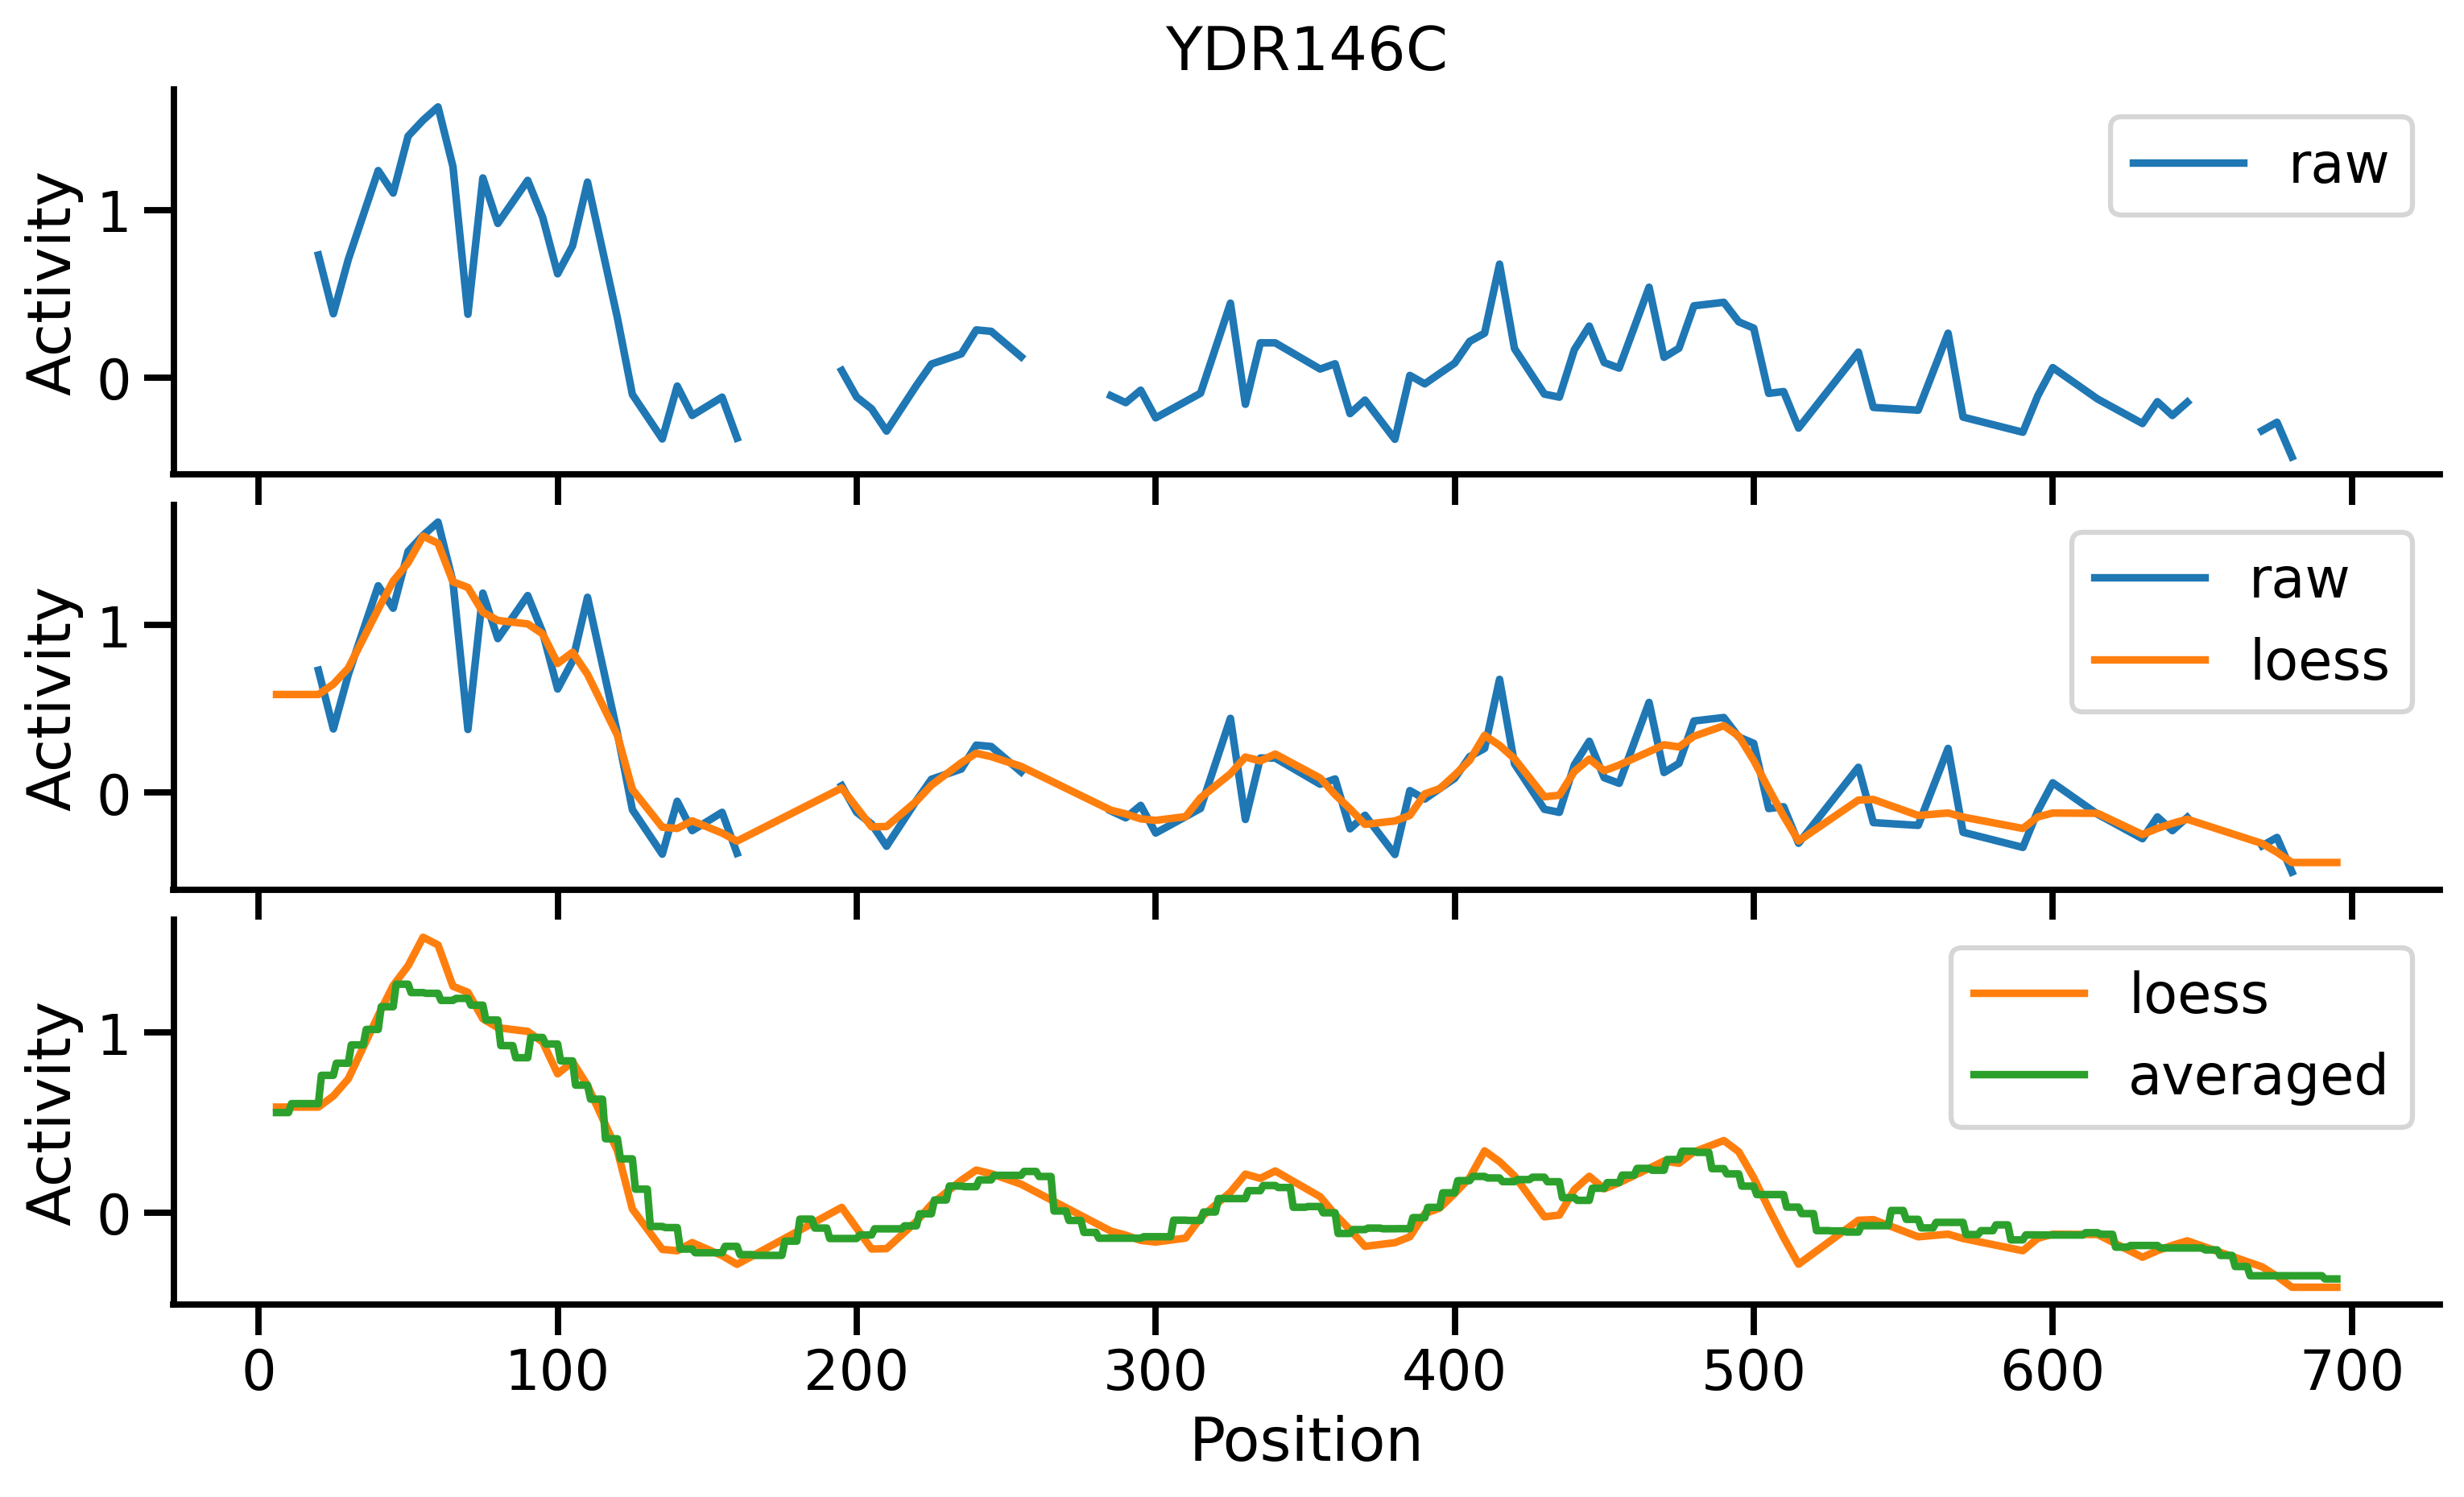

In [169]:
def split_continuous_segments(df, pos_col="position", gap=1):
    df = df.sort_values(pos_col).reset_index(drop=True)
    breaks = df[pos_col].diff() > gap
    segment_ids = breaks.cumsum()
    return [seg for _, seg in df.groupby(segment_ids)]

sns.set_context('talk')

for id in ["YDL170W", "YOR380W", "YDR146C"]:
    fig, axes = plt.subplots(3, 1, figsize=(10,6), sharex=True, dpi = 300)

    raw_data = merged_activities_with_sanborn_activators[
        merged_activities_with_sanborn_activators["id"] == id]
    loess_data = loess_pos[loess_pos["id"] == id].dropna()
    overlap_data = overlap[overlap["id"] == id].dropna()

    raw_segs     = split_continuous_segments(raw_data, pos_col="tile_center", gap=20)
    loess_segs   = split_continuous_segments(loess_data)
    overlap_segs = split_continuous_segments(overlap_data)

    # --- panel 1: raw only ---
    ax = axes[0]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="activity",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("")
    ax.legend()
    ax.set_title(id)

    # --- panel 2: raw + loess ---
    ax = axes[1]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="activity",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)

    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="activity_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("")
    ax.legend()

    # --- panel 3: loess + averaged ---
    ax = axes[2]
    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="activity_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    for i, seg in enumerate(overlap_segs):
        sns.lineplot(data=seg, x="position", y="activity_overlap",
                     color="C2", label="averaged" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("Position")
    ax.legend()

    sns.despine()
    plt.tight_layout(pad = 0)
    plt.show()

# Plotting heatmap

In [170]:
import numpy as np
import pandas as pd
from collections import Counter

WINDOW = 40


def build_heatmap_matrix_sorted(loess_pos_df, df_raw):
    id_order = (
        df_raw.groupby("id")["last_start"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    pivot = (loess_pos_df
             .pivot(index="id", columns="position", values="activity_loess_pos")
             .reindex(id_order))

    pivot.columns.name = None
    return pivot

In [173]:
mat = build_heatmap_matrix_sorted(loess_pos, merged_activities_with_sanborn)

In [174]:
mat

,6,7,8,9,10,11,12,13,14,15,...,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495
id,,,,,,,,,,,,,,,,,,,,,
YLR256W,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,...,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438
YMR280C,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YCR042C,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YJR127C,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YLR278C,NaN,NaN,NaN,NaN,NaN,-0.148062,-0.148062,-0.148062,-0.148062,-0.148062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YJL173C,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YIR013C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YCR096C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
import matplotlib.colors as mcolors
import matplotlib as mpl

def make_vlag_dark_center(dark_gray="#eeeeee", n=256):
    vlag = mpl.cm.get_cmap("vlag", n)
    colors = vlag(np.linspace(0, 1, n))
    
    # replace the middle portion with a gradient through dark gray
    mid = n // 2
    width = n // 6  # how wide the dark center region is — increase to widen it
    
    center_color = mcolors.to_rgba(dark_gray)
    
    for i in range(mid - width, mid + width):
        t = abs(i - mid) / width  # 0 at center, 1 at edges
        colors[i] = (
            t * colors[i][0] + (1 - t) * center_color[0],
            t * colors[i][1] + (1 - t) * center_color[1],
            t * colors[i][2] + (1 - t) * center_color[2],
            1.0
        )
    
    return mcolors.LinearSegmentedColormap.from_list("vlag_dark", colors)

cmap = make_vlag_dark_center(dark_gray="#eeeeee")

/tmp/ipykernel_229633/3554710520.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vlag = mpl.cm.get_cmap("vlag", n)


In [240]:
def plot_heatmap(
    mat,
    should_add_boxes=True,
    ADs=our_activators_merged,
    RDs=our_repressors_merged,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

    sns.heatmap(
        mat,
        cmap=cmap,
        mask=mat.isna(),
        center=0,
        vmin=mat.stack().quantile(0),
        vmax=mat.stack().quantile(1),
        ax=ax,
    )

    row_lookup = {pid: i for i, pid in enumerate(mat.index)}
    col_positions = np.array(mat.columns)

    for i in range(1, len(mat) - 1):
        ax.axhline(i, color="white", linewidth=0.5, zorder=1)

    def add_boxes(regions, color):
        for pid, start, end in regions:
            if pid not in row_lookup:
                continue

            row = row_lookup[pid]

            col_start = np.searchsorted(col_positions, int(start))
            col_end = np.searchsorted(col_positions, int(end))

            ax.add_patch(
                plt.Rectangle(
                    (col_start, row),
                    col_end - col_start,
                    1,
                    fill=False,
                    edgecolor=color,
                    linewidth=0.75,
                    zorder=3,
                )
            )

    if should_add_boxes:
        if ADs is not None:
            add_boxes(ADs, color="red")

        if RDs is not None:
            add_boxes(RDs, color="blue")

        add_boxes(sanborn_merged, color="green")

    # -----------------------------
    # scale bar
    # -----------------------------
    scale_bp = 200
    n_cols = len(col_positions)

    start_pos = col_positions[0]
    end_pos = start_pos + scale_bp

    col_start = np.searchsorted(col_positions, start_pos)
    col_end = np.searchsorted(col_positions, end_pos)

    scale_cols = col_end - col_start

    bar_y = len(mat) - 20
    bar_x = n_cols * 0.75

    tick_height = 0.3

    ax.plot(
        [bar_x, bar_x + scale_cols],
        [bar_y, bar_y],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x, bar_x],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x + scale_cols, bar_x + scale_cols],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.text(
        bar_x + scale_cols / 2,
        bar_y - 1,
        f"{scale_bp} AAs",
        ha="center",
        va="bottom",
        fontsize="medium",
        clip_on=False,
    )

    # -----------------------------
    # axis cleanup
    # -----------------------------
    ax.set_xticks([])
    ax.set_xlabel("")

    if should_add_boxes:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[
                Patch(
                    facecolor="none",
                    edgecolor="green",
                    label="Sanborn Activation Domains",
                ),
                Patch(
                    facecolor="none",
                    edgecolor="red",
                    label="Chop TFs Activation Domains",
                ),
                Patch(
                    facecolor="none",
                    edgecolor="blue",
                    label="Chop TFs Repression Domains",
                ),
            ],
            loc="lower right",
        )

    plt.ylabel("")
    plt.yticks([])

    # -----------------------------
    # save
    # -----------------------------
    if save_path is not None:
        fig.savefig(
            f"{save_path}.png",
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            f"{save_path}.pdf",
            bbox_inches="tight",
        )

    plt.show()

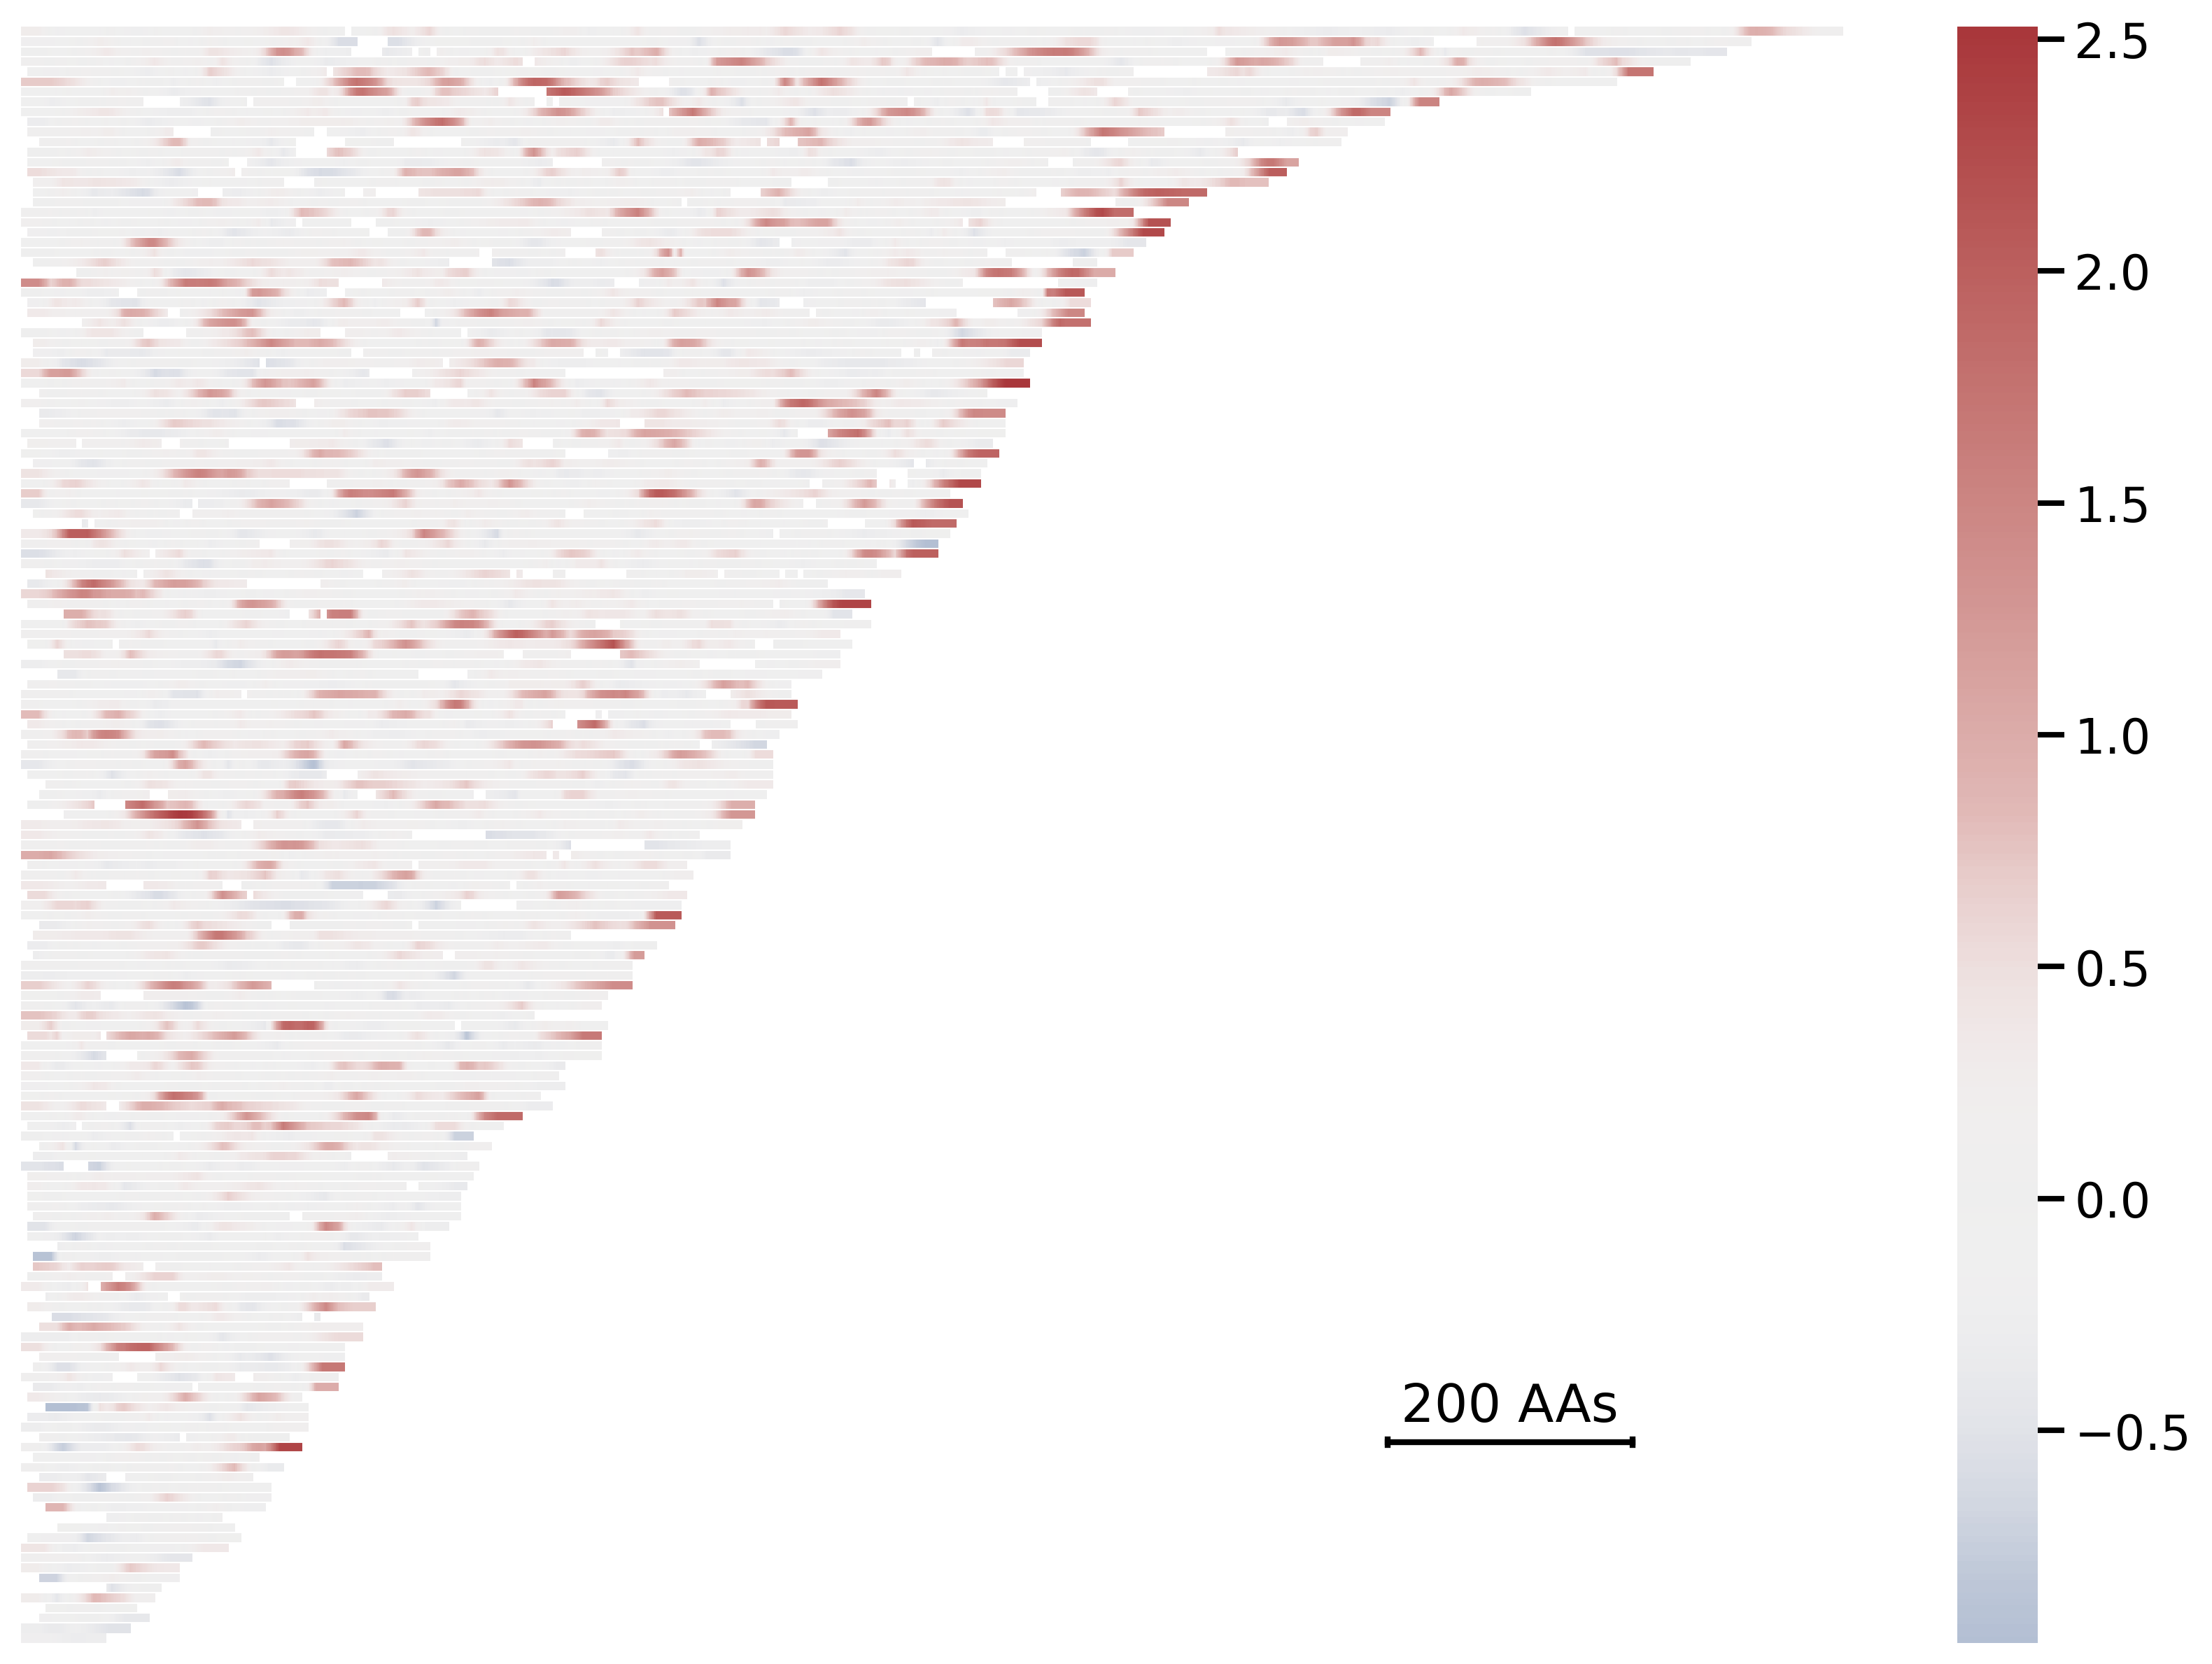

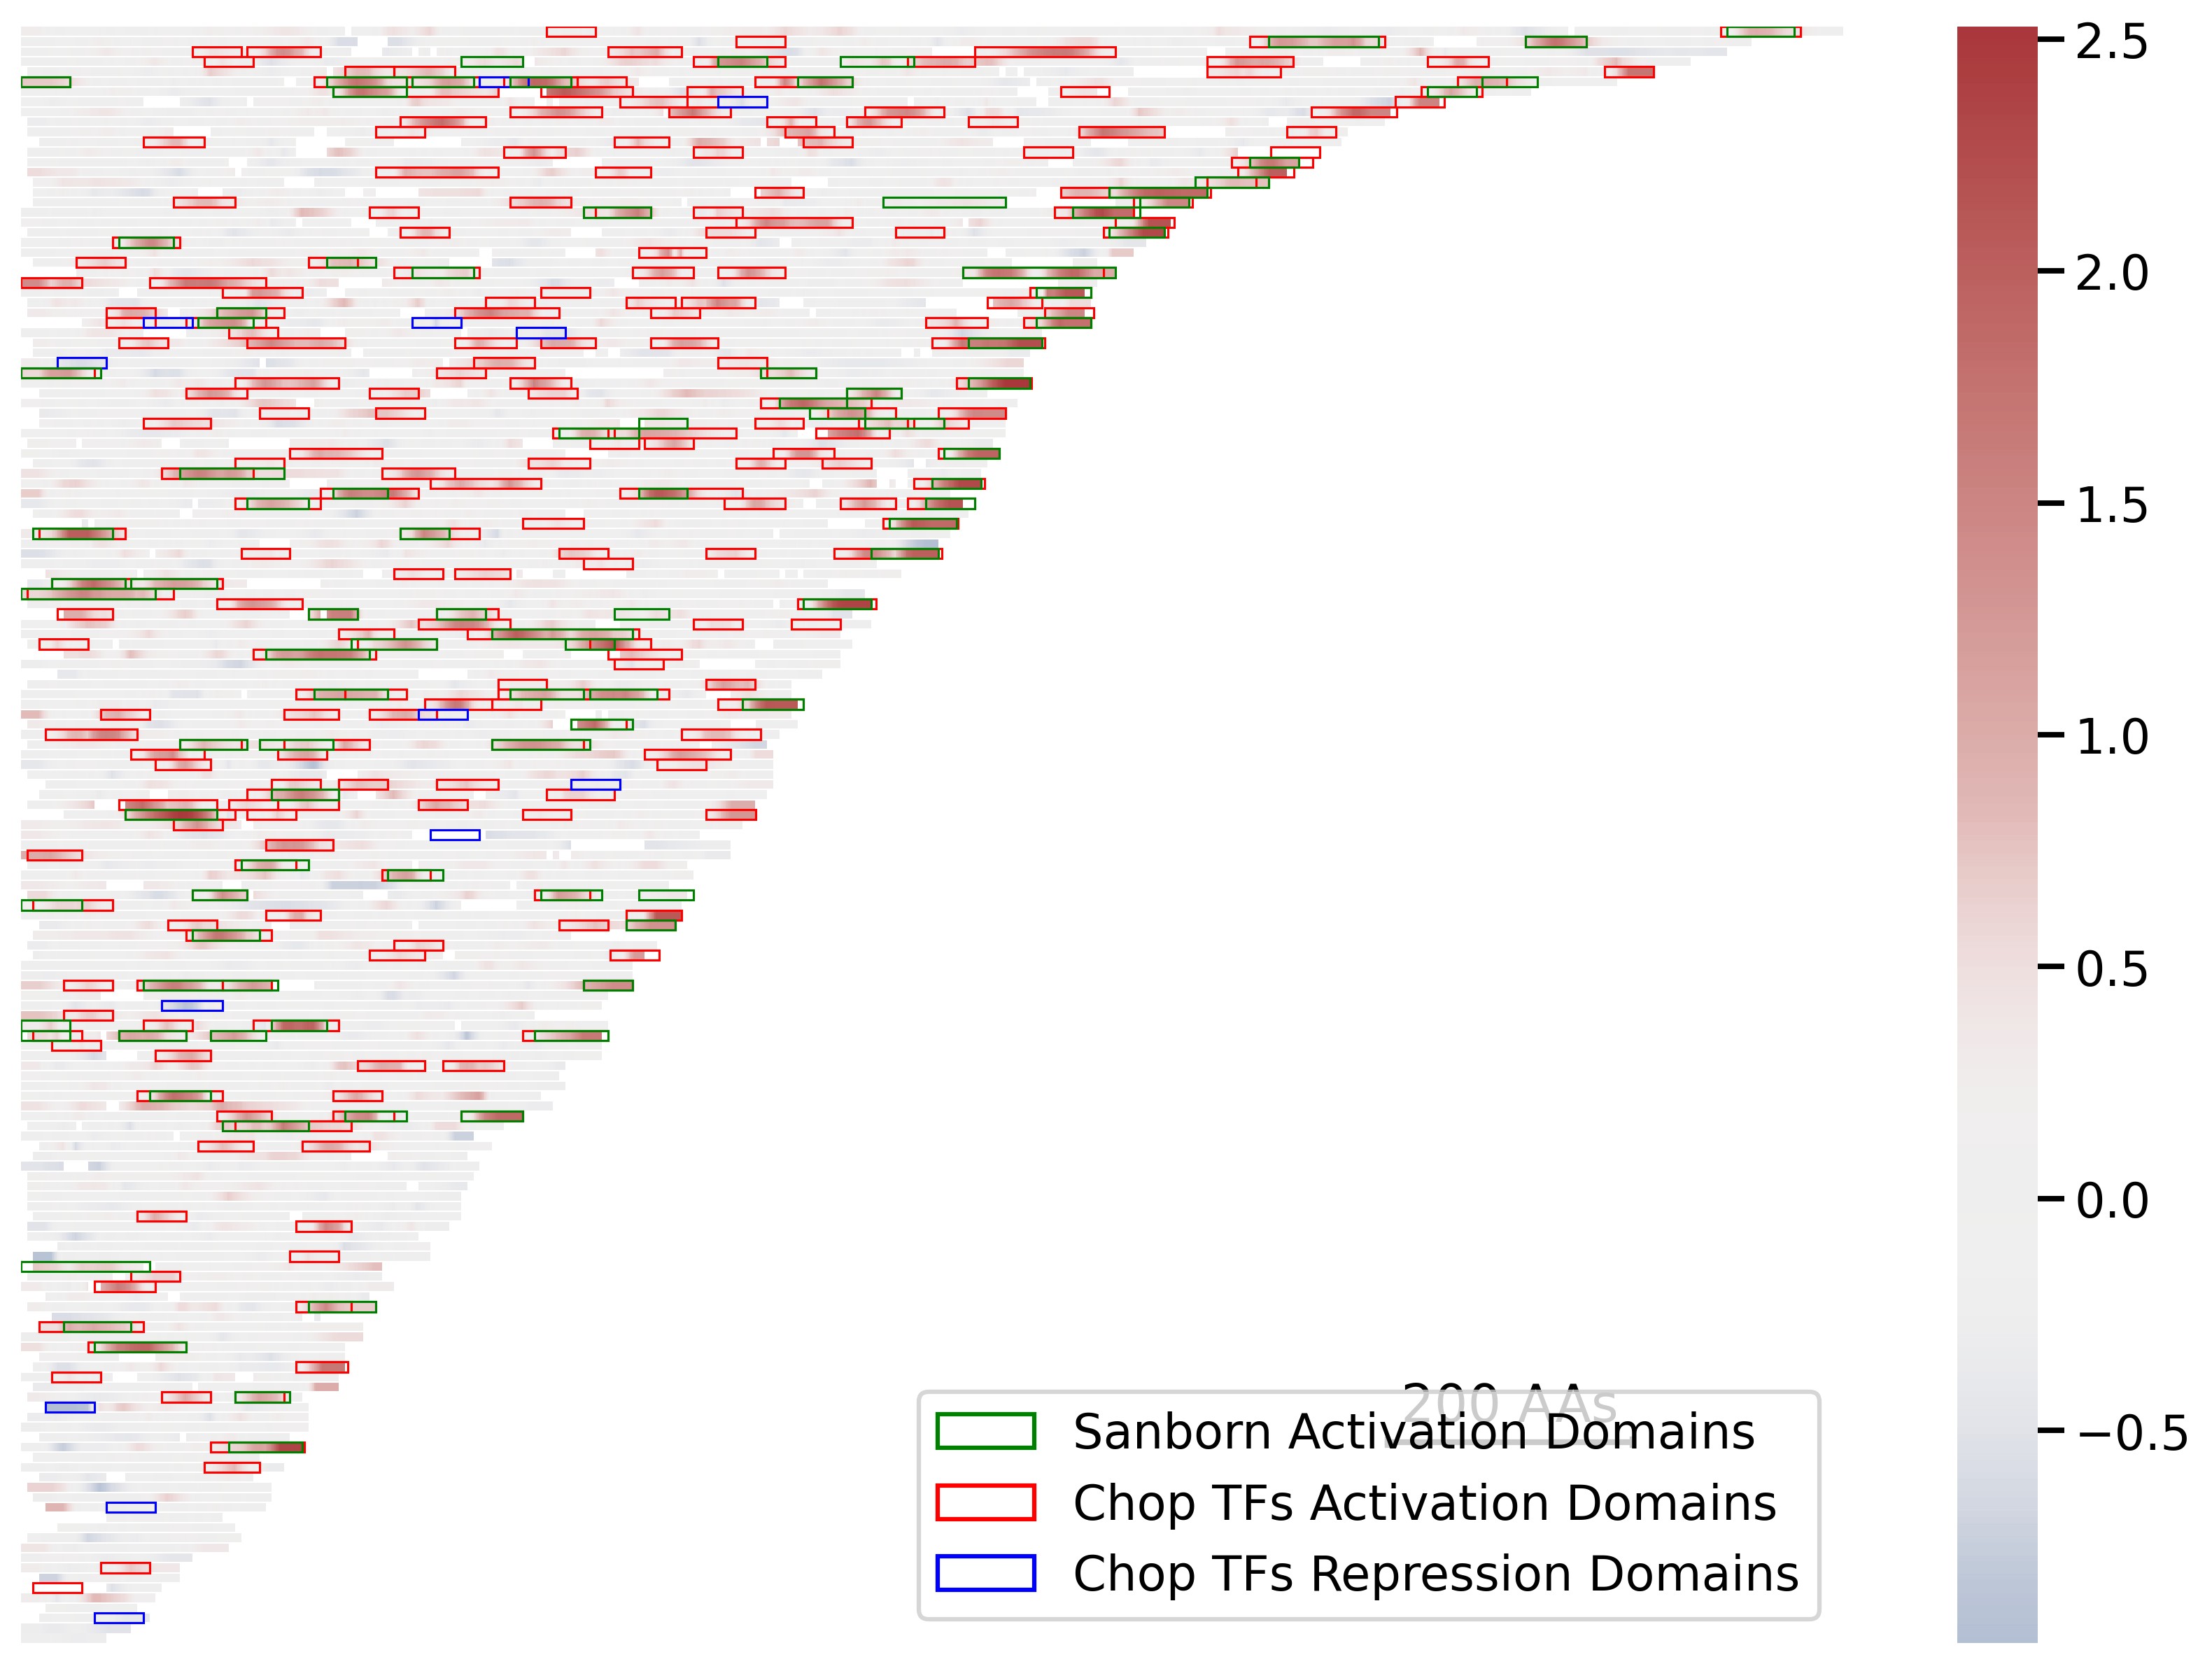

In [177]:
plot_heatmap(mat, should_add_boxes=False)
plot_heatmap(mat)

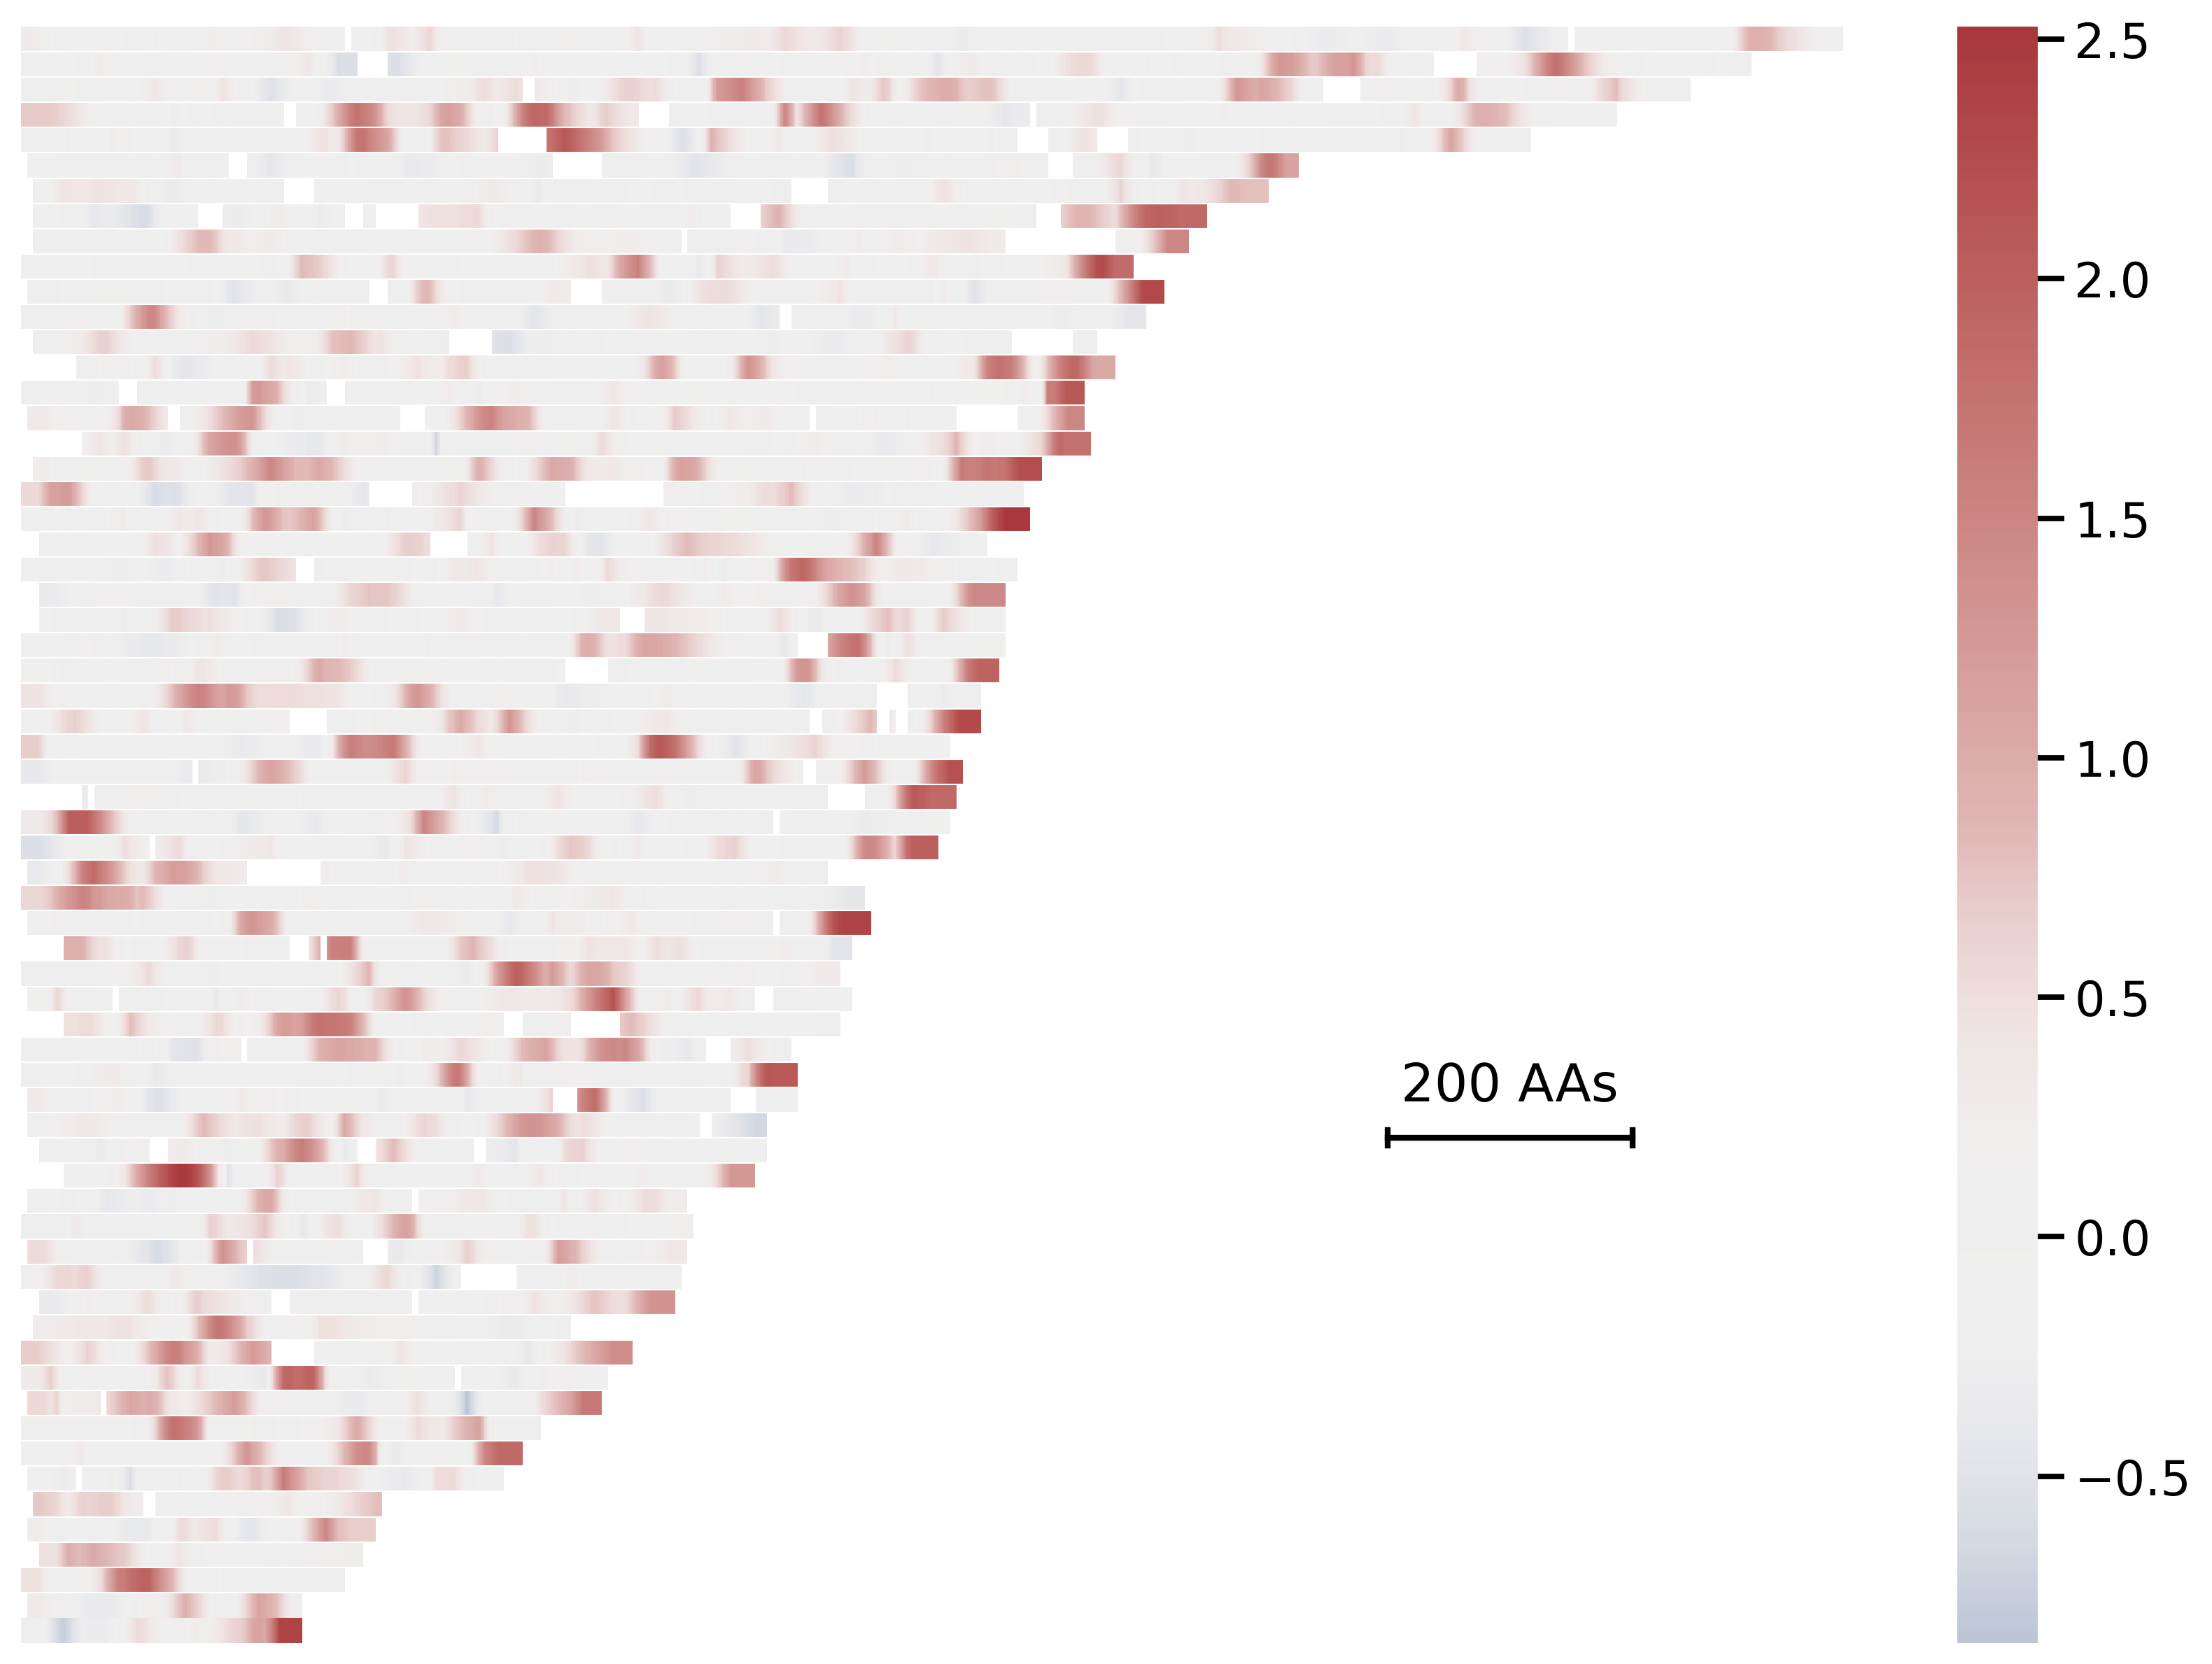

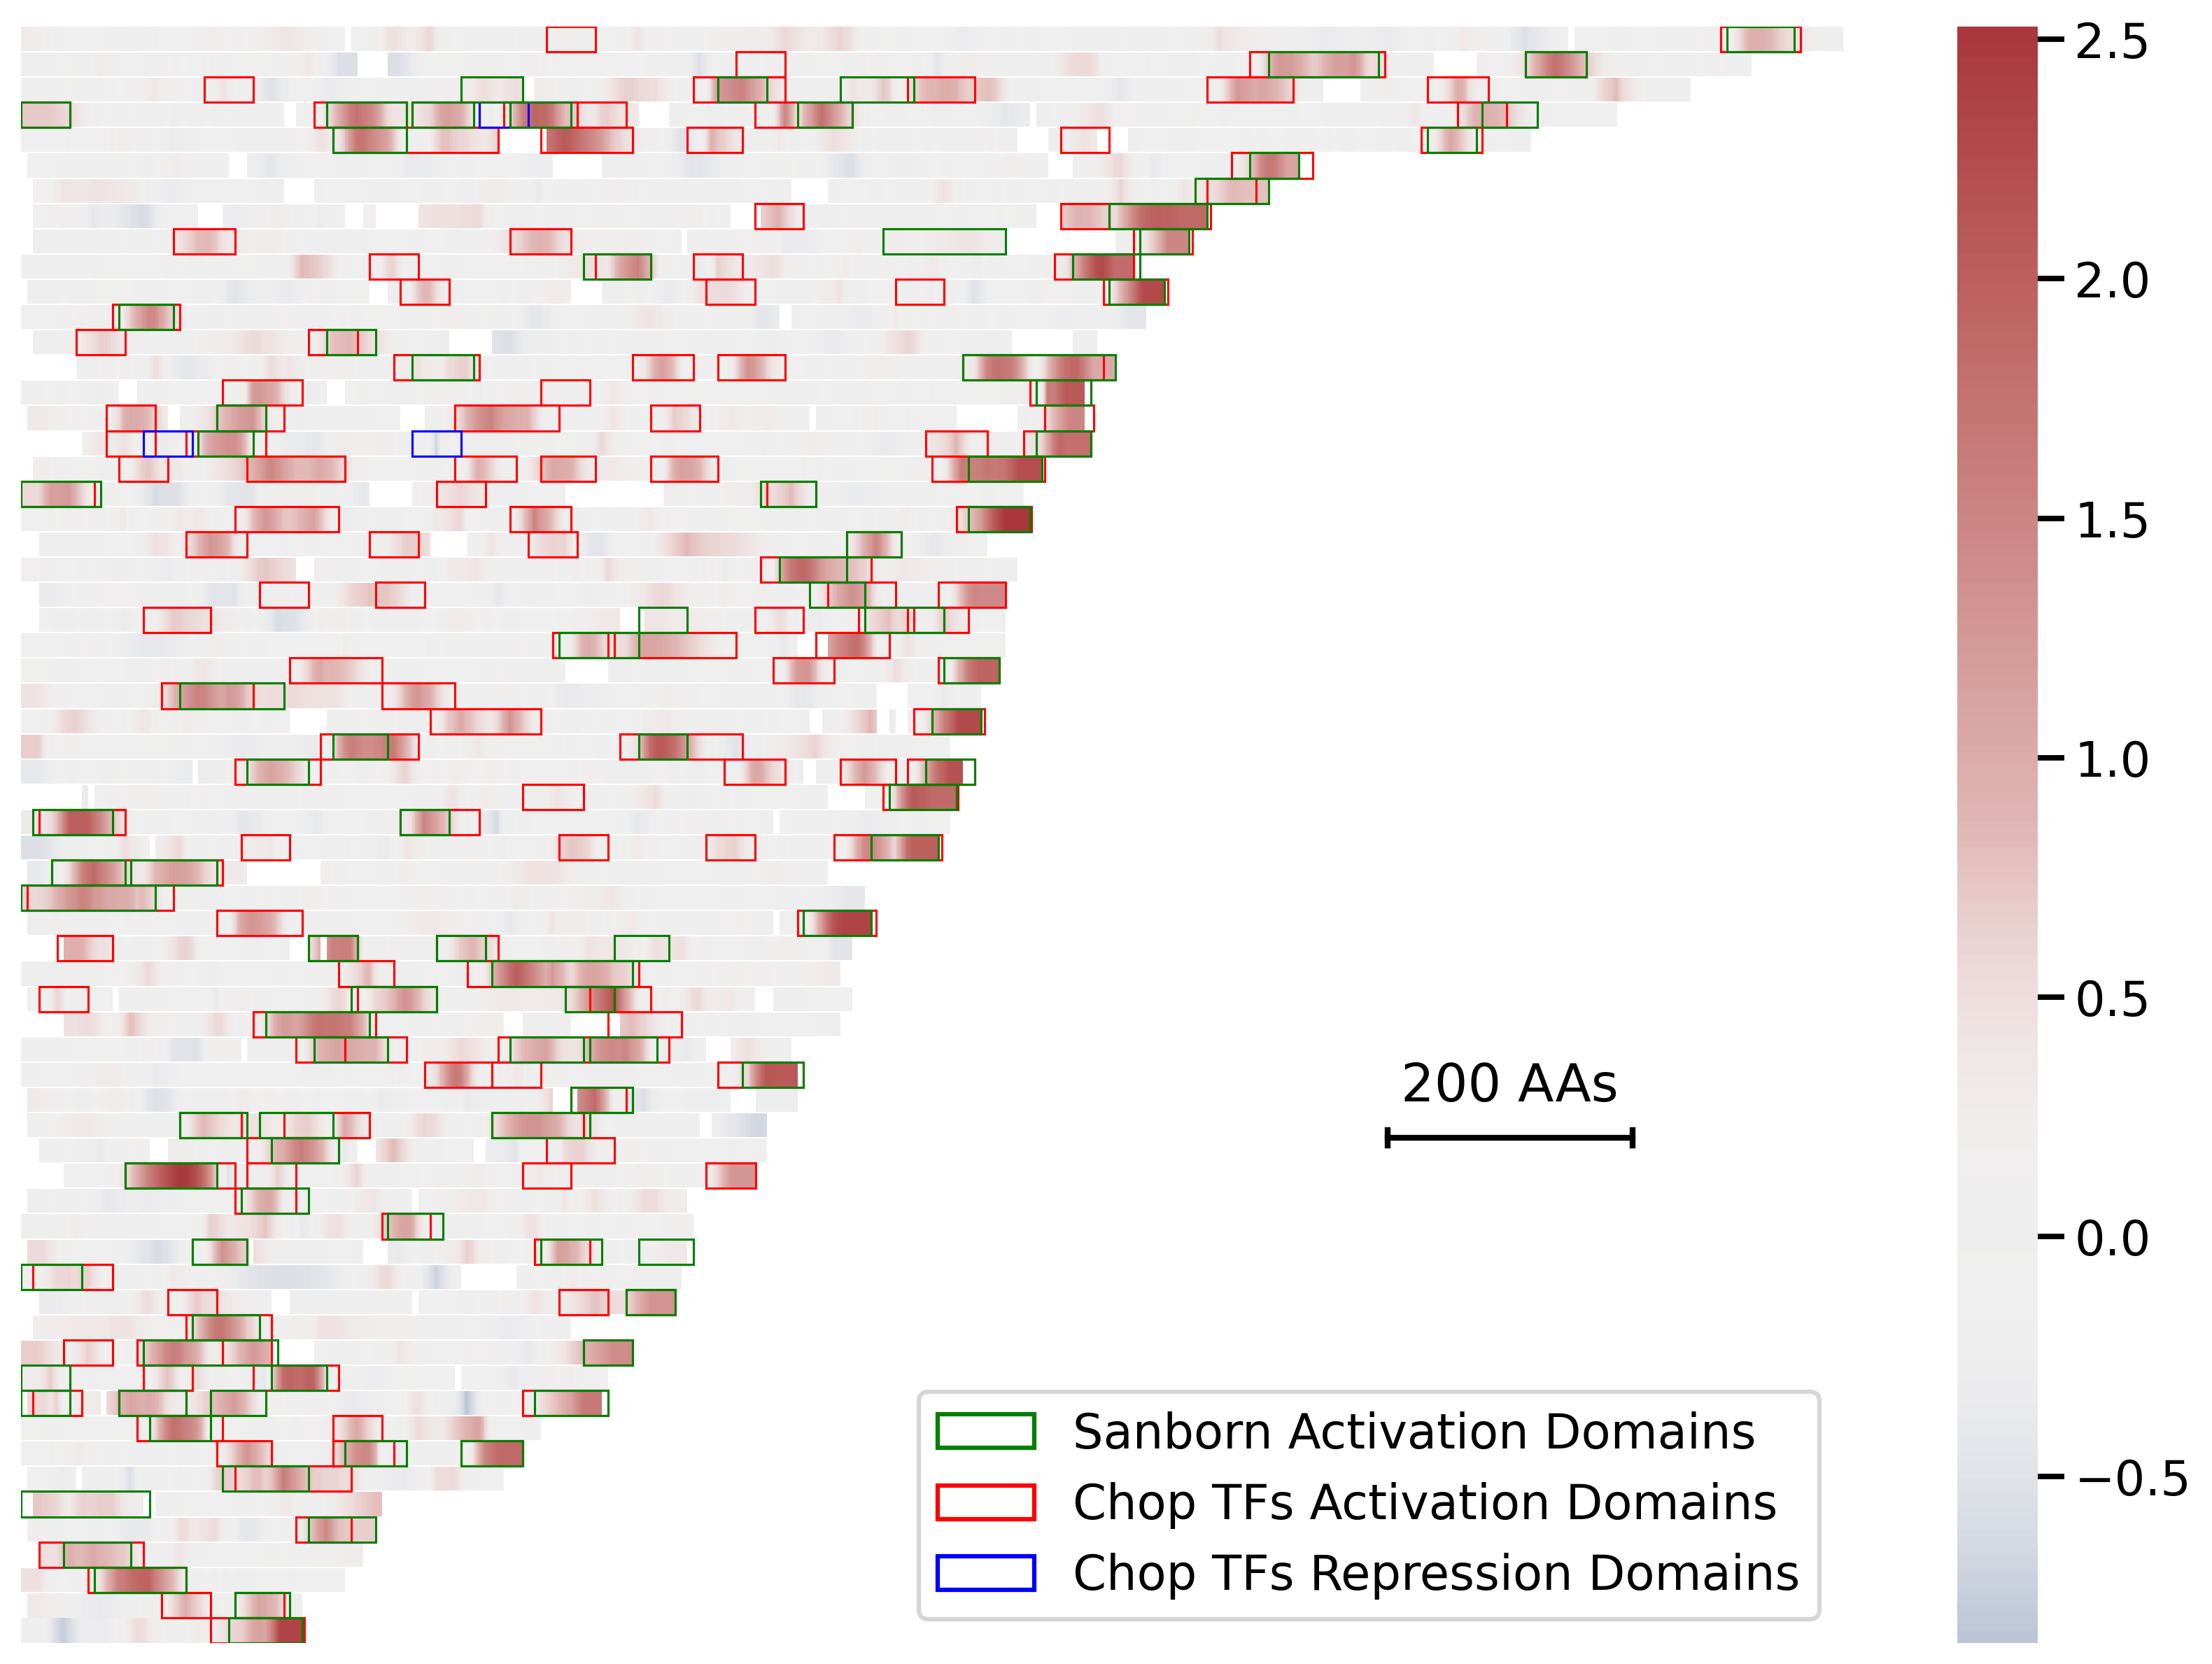

In [179]:
plot_heatmap(mat[mat.index.isin(sanborn["id"])], should_add_boxes=False)
plot_heatmap(mat[mat.index.isin(sanborn["id"])])

# Using loess to get activity

In [244]:
loess_pos["activity_loess_pos"].quantile(0.90)

0.5848858577891315

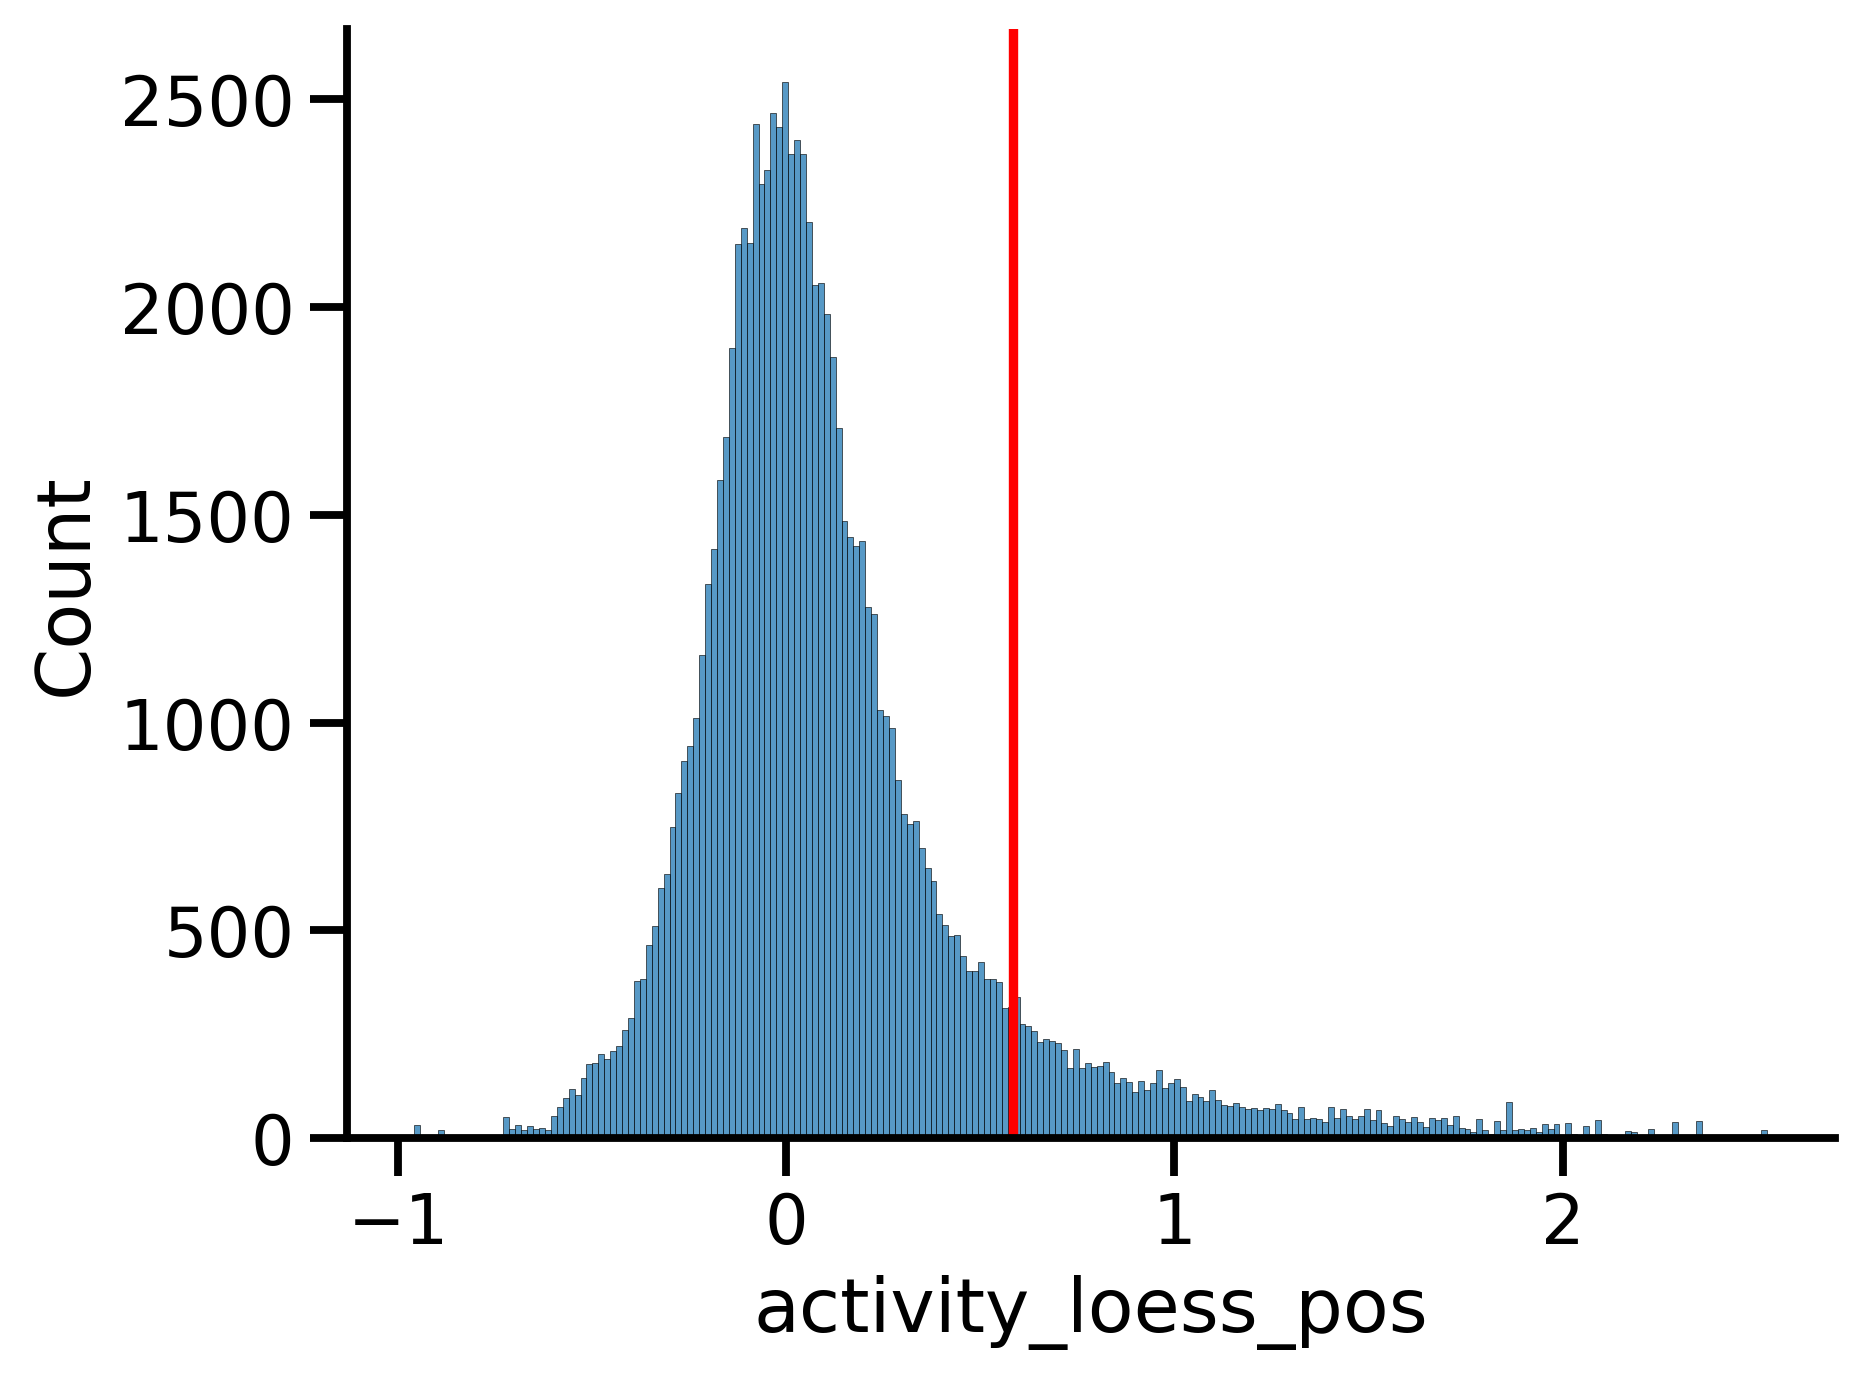

In [243]:
# I will consider positions above 1 to be active- a fold change of 10
plt.figure(dpi = 300)
sns.histplot(data = loess_pos, x = "activity_loess_pos")
plt.axvline(loess_pos["activity_loess_pos"].quantile(0.90), color = 'red')
sns.despine()

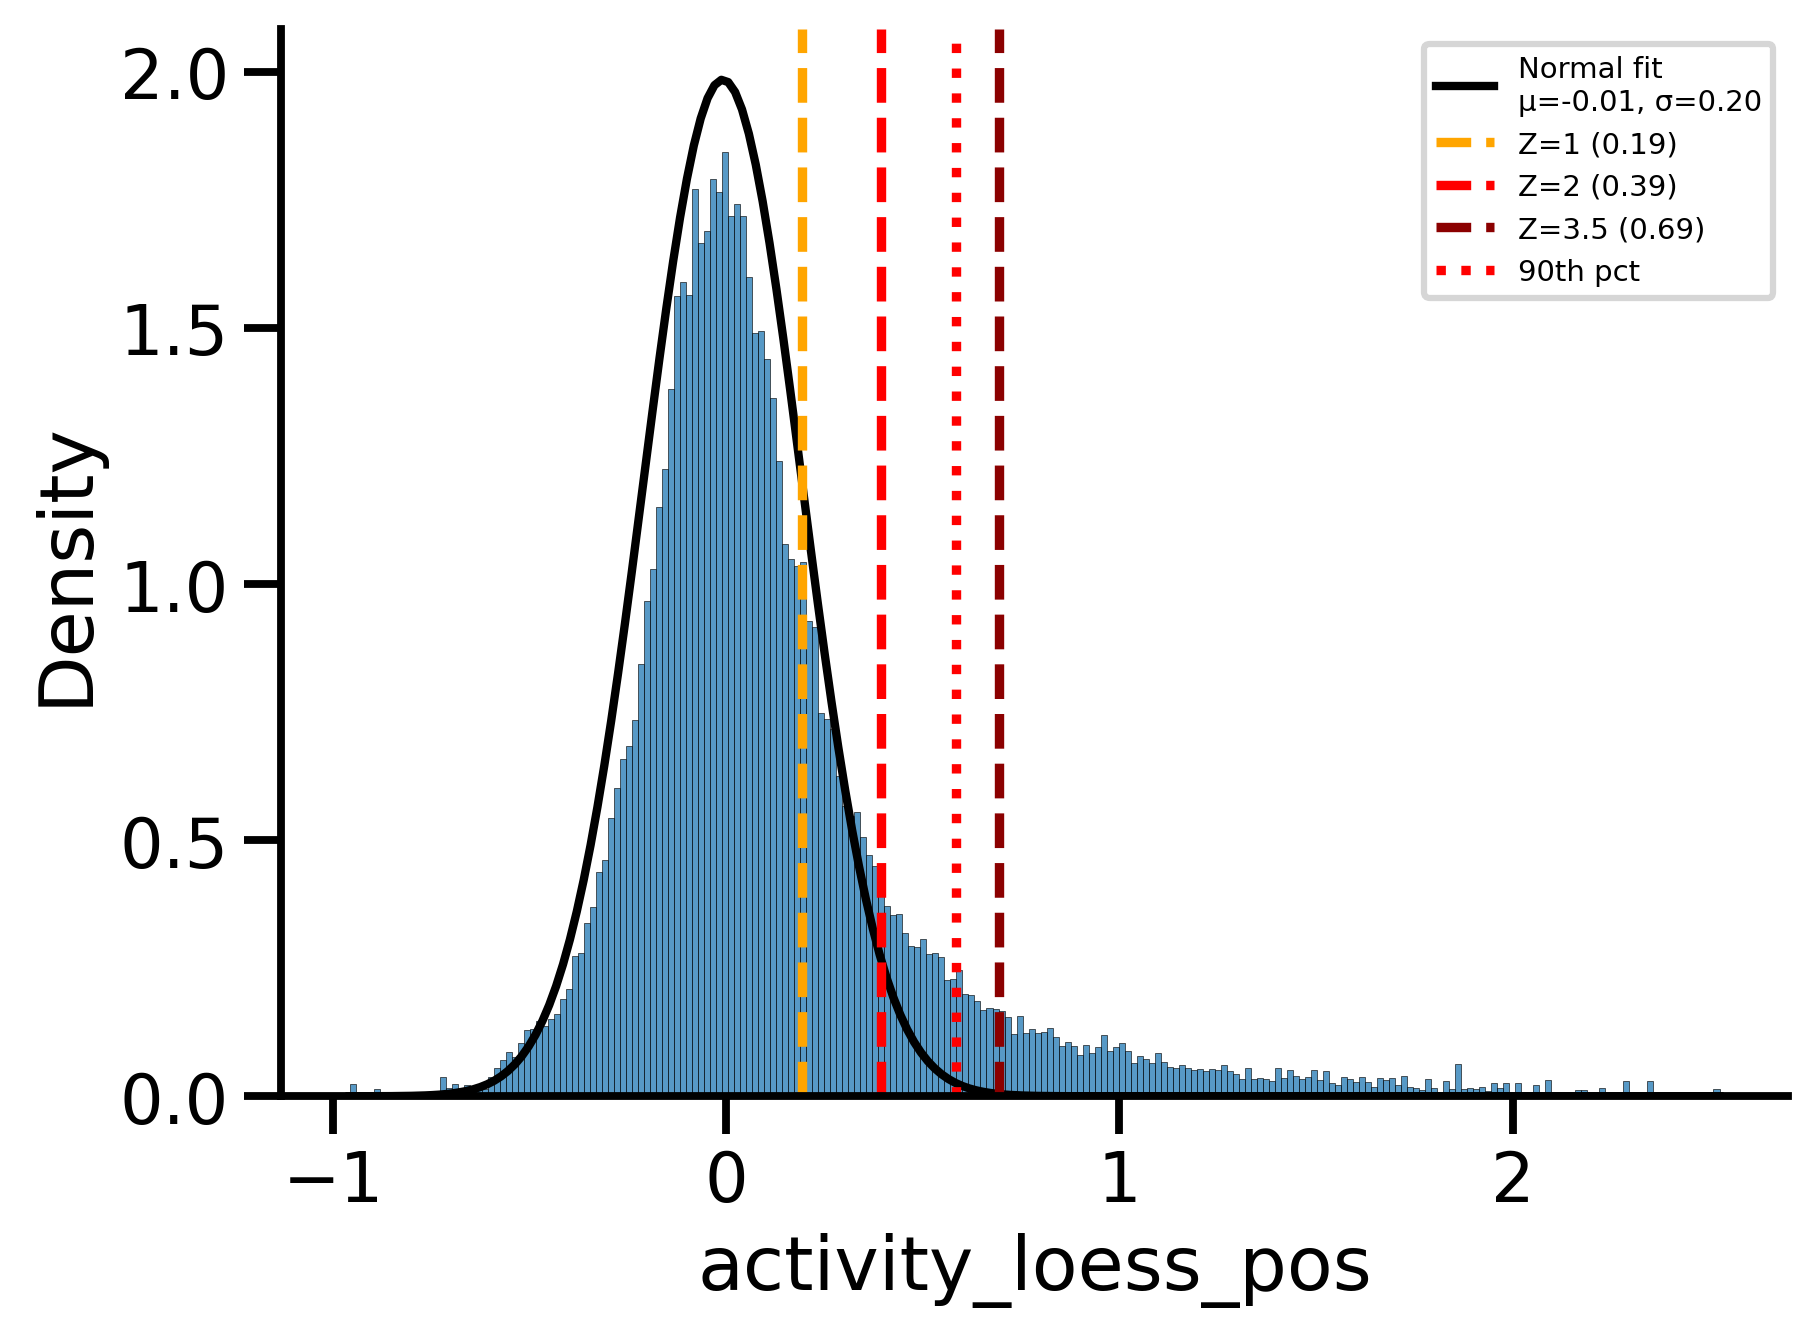

μ = -0.009, σ = 0.201
Z=1 threshold: 0.192
Z=2 threshold: 0.393
Z=3 threshold: 0.594


In [256]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(dpi=300)

# Plot histogram (density=True so it matches the PDF scale)
sns.histplot(data=loess_pos, x="activity_loess_pos", stat="density", ax=ax)

# Fit normal distribution and overlay
# Fit only values below the median or a low percentile — captures the "background"
background = loess_pos["activity_loess_pos"][
    loess_pos["activity_loess_pos"] < loess_pos["activity_loess_pos"].quantile(0.85)
]
mu, std = stats.norm.fit(background)

x = np.linspace(loess_pos["activity_loess_pos"].min(), 
                loess_pos["activity_loess_pos"].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, std), color="black", lw=2, label=f"Normal fit\nμ={mu:.2f}, σ={std:.2f}")

# Z-score threshold lines
for z, color, label in [(1, "orange", "Z=1"), (2, "red", "Z=2"), (3.5, "darkred", "Z=3.5")]:
    ax.axvline(mu + z*std, color=color, linestyle="--", label=f"{label} ({mu + z*std:.2f})")

# Your original 90th percentile line
ax.axvline(loess_pos["activity_loess_pos"].quantile(0.90), 
           color="red", linestyle=":", label="90th pct")

ax.legend(fontsize=7)
sns.despine()
plt.xlabel("activity_loess_pos")
plt.tight_layout()
plt.show()

print(f"μ = {mu:.3f}, σ = {std:.3f}")
print(f"Z=1 threshold: {mu + std:.3f}")
print(f"Z=2 threshold: {mu + 2*std:.3f}")
print(f"Z=3 threshold: {mu + 3*std:.3f}")

In [140]:
loess_pos

,id,position,activity_loess_pos,coverage
10,YAL051W,11,0.528731,2
11,YAL051W,12,0.528731,2
12,YAL051W,13,0.528731,2
13,YAL051W,14,0.528731,2
14,YAL051W,15,0.528731,2
...,...,...,...,...
78600,YPR196W,446,-0.360379,2
78601,YPR196W,447,-0.360379,2
78602,YPR196W,448,-0.360379,2
78603,YPR196W,449,-0.360379,2


Searching for ADs as Sanborn did, except activity threshold of 1 instead of MPZ of 3.5.

"To define ADs across all TFs, at each protein position a mean Z-score was calculated from the Z-scores of all fragments overlapping that position. ADs were defined for all intervals of the protein that had a mean positional Z-score (MPZ) greater than 3.5. Starting with intervals that had the highest maximal MPZ score, the start and stop positions of the AD were defined by the full width half maximum; that is, the positions in the protein at which the MPZ fell below half of the maximal MPZ value in that interval. If the AD defined in this manner includes a new region with an MPZ score higher than the original maximal value, this indicated that the MPZ peak was only small relative to nearby peaks, so the AD was then excluded."

In [181]:
import numpy as np
import pandas as pd


def find_ads(loess_hc, threshold=3.5):

    ads = []

    for pid, g in loess_hc.groupby("id"):

        g = g.sort_values("position").reset_index(drop=True)

        pos = g["position"].values
        val = g["activity_loess_pos"].values

        # -----------------------------------
        # 1. candidate intervals > threshold
        # -----------------------------------
        above = val > threshold

        if not above.any():
            continue

        starts = np.where(np.diff(np.r_[0, above.astype(int)]) == 1)[0]
        ends = np.where(np.diff(np.r_[above.astype(int), 0]) == -1)[0]

        for s, e in zip(starts, ends):

            interval_pos = pos[s:e+1]
            interval_val = val[s:e+1]

            # -----------------------------------
            # 2. peak in interval
            # -----------------------------------
            peak_idx_local = np.argmax(interval_val)
            peak_val = interval_val[peak_idx_local]
            peak_pos = interval_pos[peak_idx_local]

            # -----------------------------------
            # 3. FWHM boundaries
            # -----------------------------------
            half = peak_val / 2

            global_peak_idx = s + peak_idx_local

            # left boundary
            left = global_peak_idx
            while left > 0 and val[left] >= half:
                left -= 1

            # right boundary
            right = global_peak_idx
            while right < len(val)-1 and val[right] >= half:
                right += 1

            ad_start = pos[left + 1]
            ad_end = pos[right - 1]

            # -----------------------------------
            # 4. shoulder rejection
            # -----------------------------------
            inside = (pos >= ad_start) & (pos <= ad_end)

            if val[inside].max() > peak_val:
                continue

            ads.append({
                "id": pid,
                "ad_start": ad_start,
                "ad_end": ad_end,
                "length": ad_end - ad_start + 1,
                "peak_pos": peak_pos,
                "peak_activity": peak_val,
            })

    return pd.DataFrame(ads)

In [257]:
stricter_ads = find_ads(loess_pos, threshold=0.7)

stricter_ads_intervals = (
    stricter_ads[["id", "ad_start", "ad_end"]]
    .rename(columns={
        "ad_start": "tile_start",
        "ad_end": "tile_end"
    })
)

stricter_ads_merged = merge_intervals(stricter_ads_intervals)

compare_intervals(
    stricter_ads_merged,
    sanborn_merged,
    names=("Stricter ADs", "Sanborn")
)

Stricter ADs intervals overlapping Sanborn: 94 / 238 (39.5%)
Stricter ADs intervals missed by Sanborn:  144 / 238 (60.5%)
Sanborn intervals overlapping Stricter ADs: 88 / 98 (89.8%)
Sanborn intervals missed by Stricter ADs:  10 / 98 (10.2%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [258]:
compare_intervals(
    stricter_ads_merged,
    our_repressors_merged,
    names=("Stricter ADs", "Repressors")
)

Stricter ADs intervals overlapping Repressors: 2 / 238 (0.8%)
Stricter ADs intervals missed by Repressors:  236 / 238 (99.2%)
Repressors intervals overlapping Stricter ADs: 2 / 13 (15.4%)
Repressors intervals missed by Stricter ADs:  11 / 13 (84.6%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [259]:
compare_intervals(
    sanborn_merged,
    our_repressors_merged,
    names=("Sanborn ADs", "RDs")
)

Sanborn ADs intervals overlapping RDs: 1 / 98 (1.0%)
Sanborn ADs intervals missed by RDs:  97 / 98 (99.0%)
RDs intervals overlapping Sanborn ADs: 1 / 13 (7.7%)
RDs intervals missed by Sanborn ADs:  12 / 13 (92.3%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

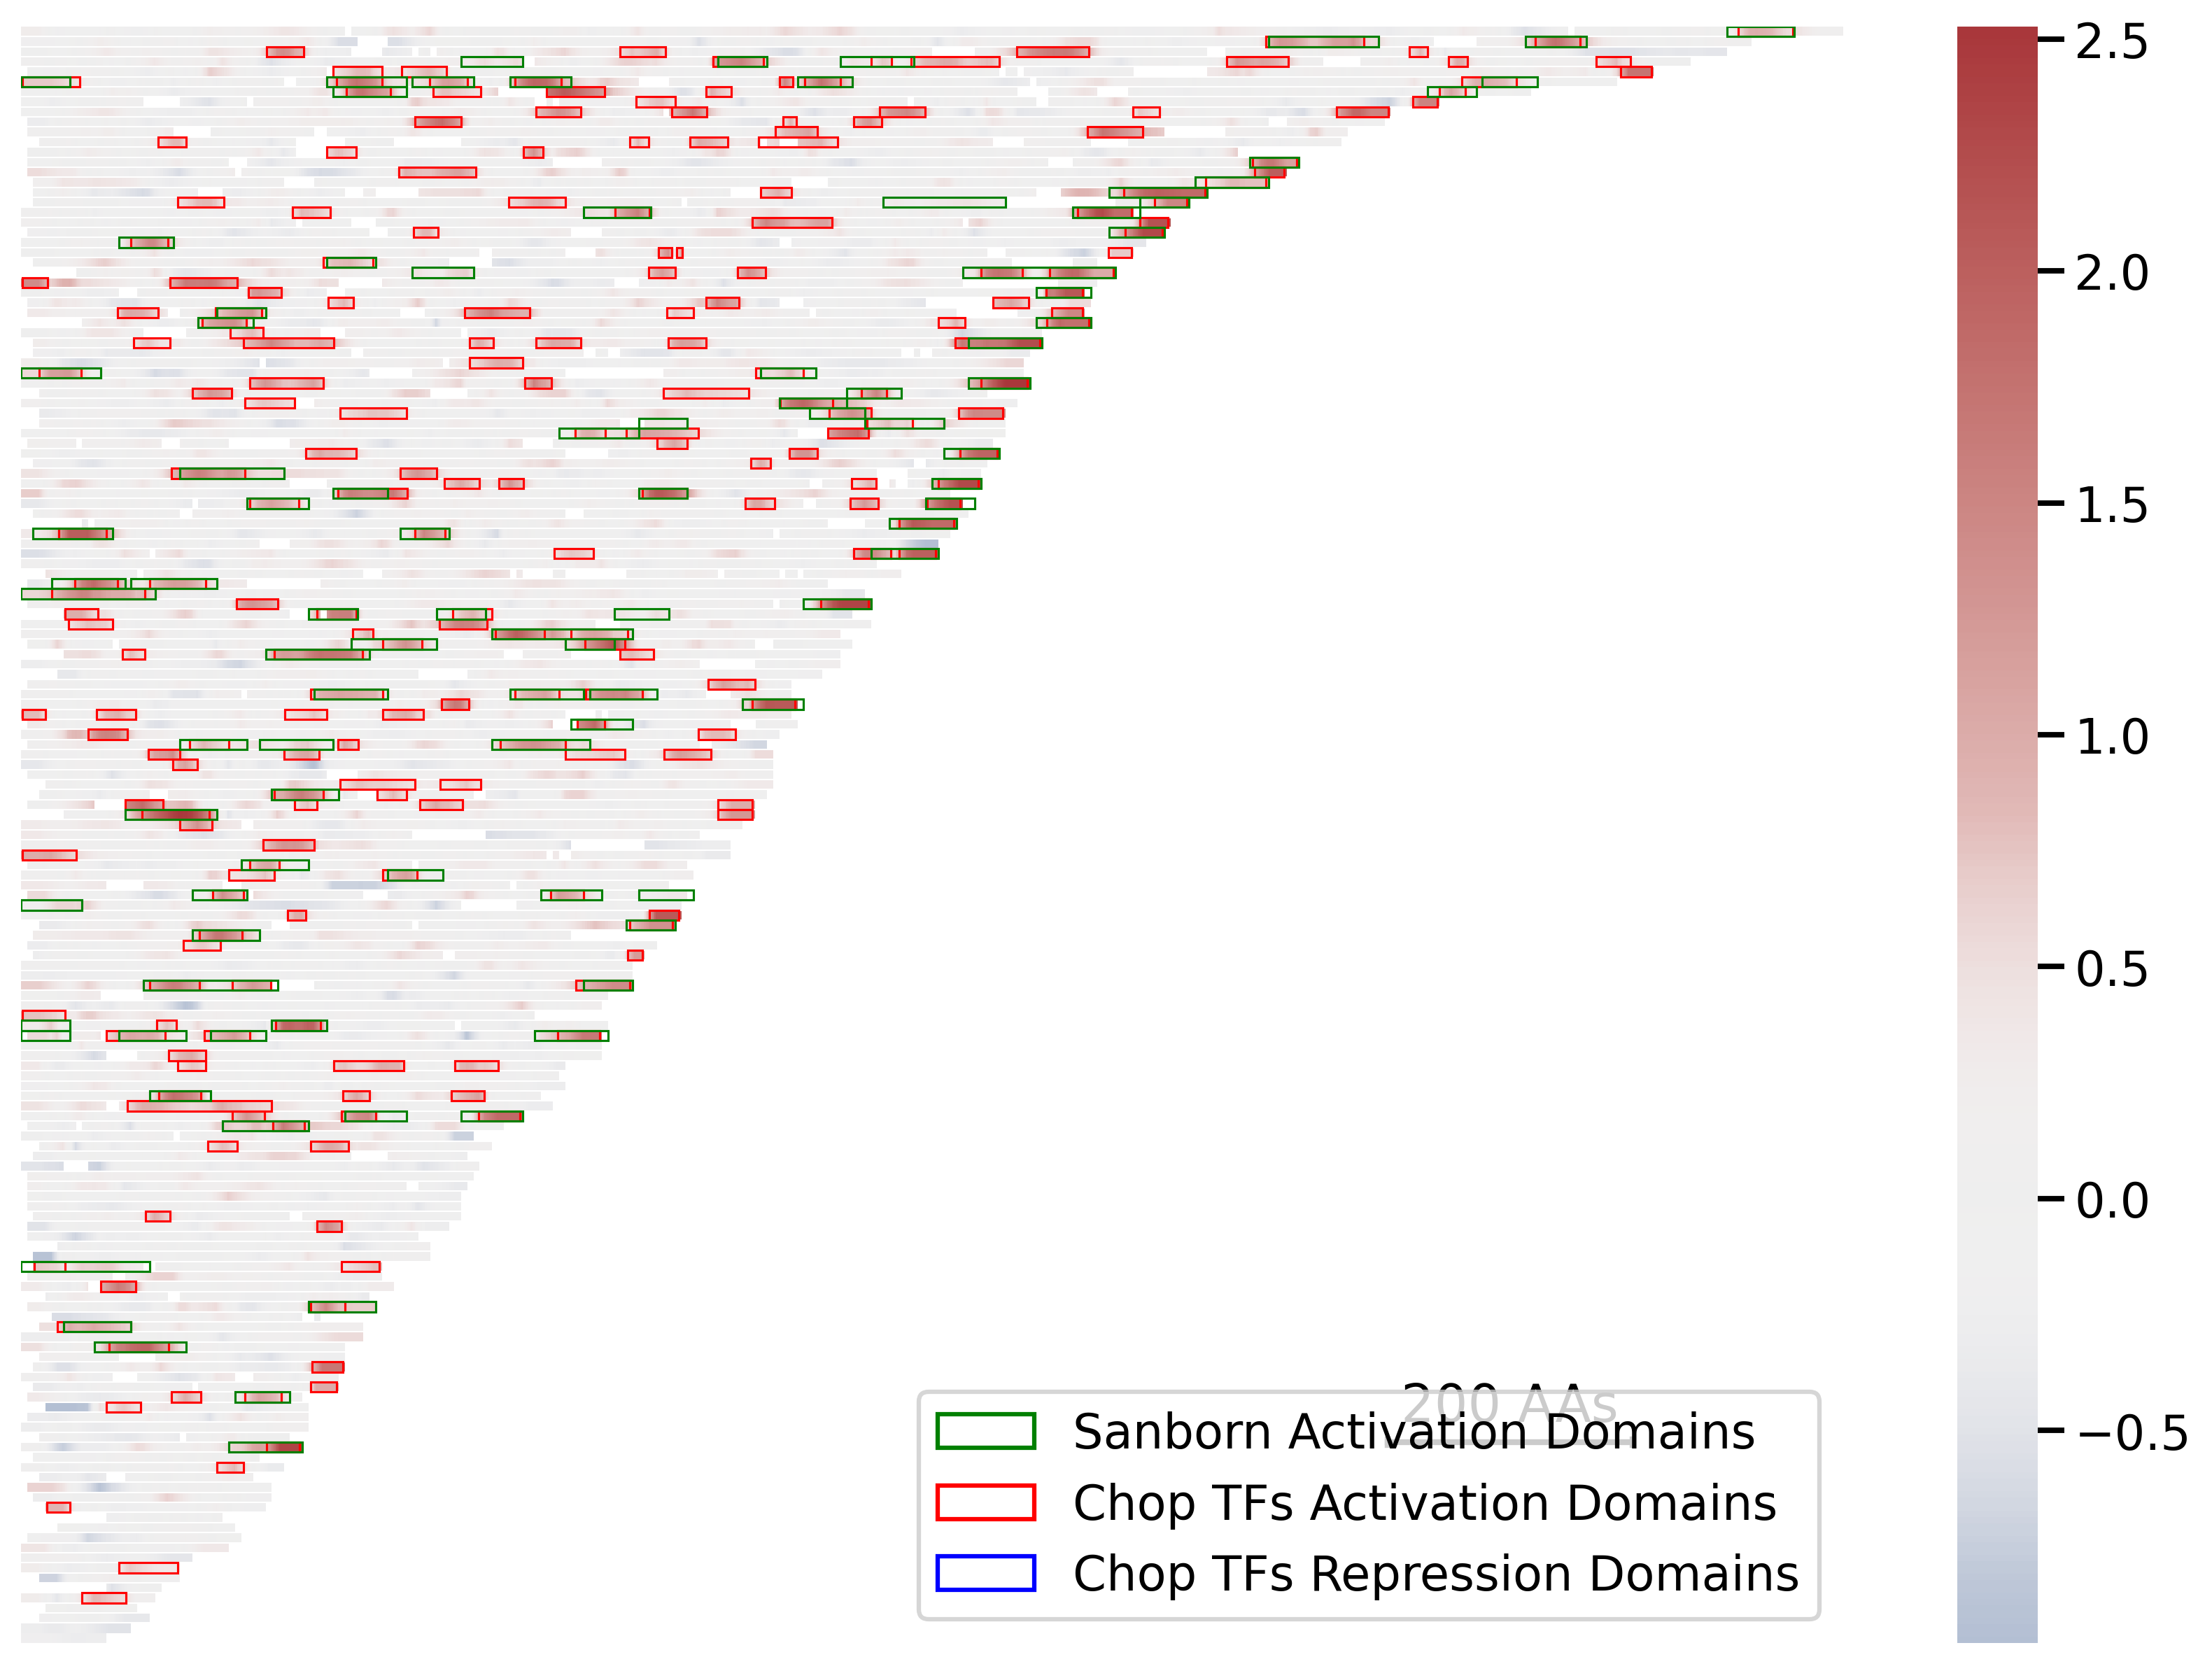

In [260]:
plot_heatmap(mat, 
             should_add_boxes=True, 
             ADs = stricter_ads_merged, 
             RDs = None)

In [261]:
ids = set(sanborn["id"]) | set(pd.DataFrame(stricter_ads_merged)[0]) | set(pd.DataFrame(our_repressors_merged)[0])

In [262]:
! mkdir ../../../output/ChopTFs_pipeline/paper_figs

mkdir: cannot create directory ‘../../../output/ChopTFs_pipeline/paper_figs’: File exists


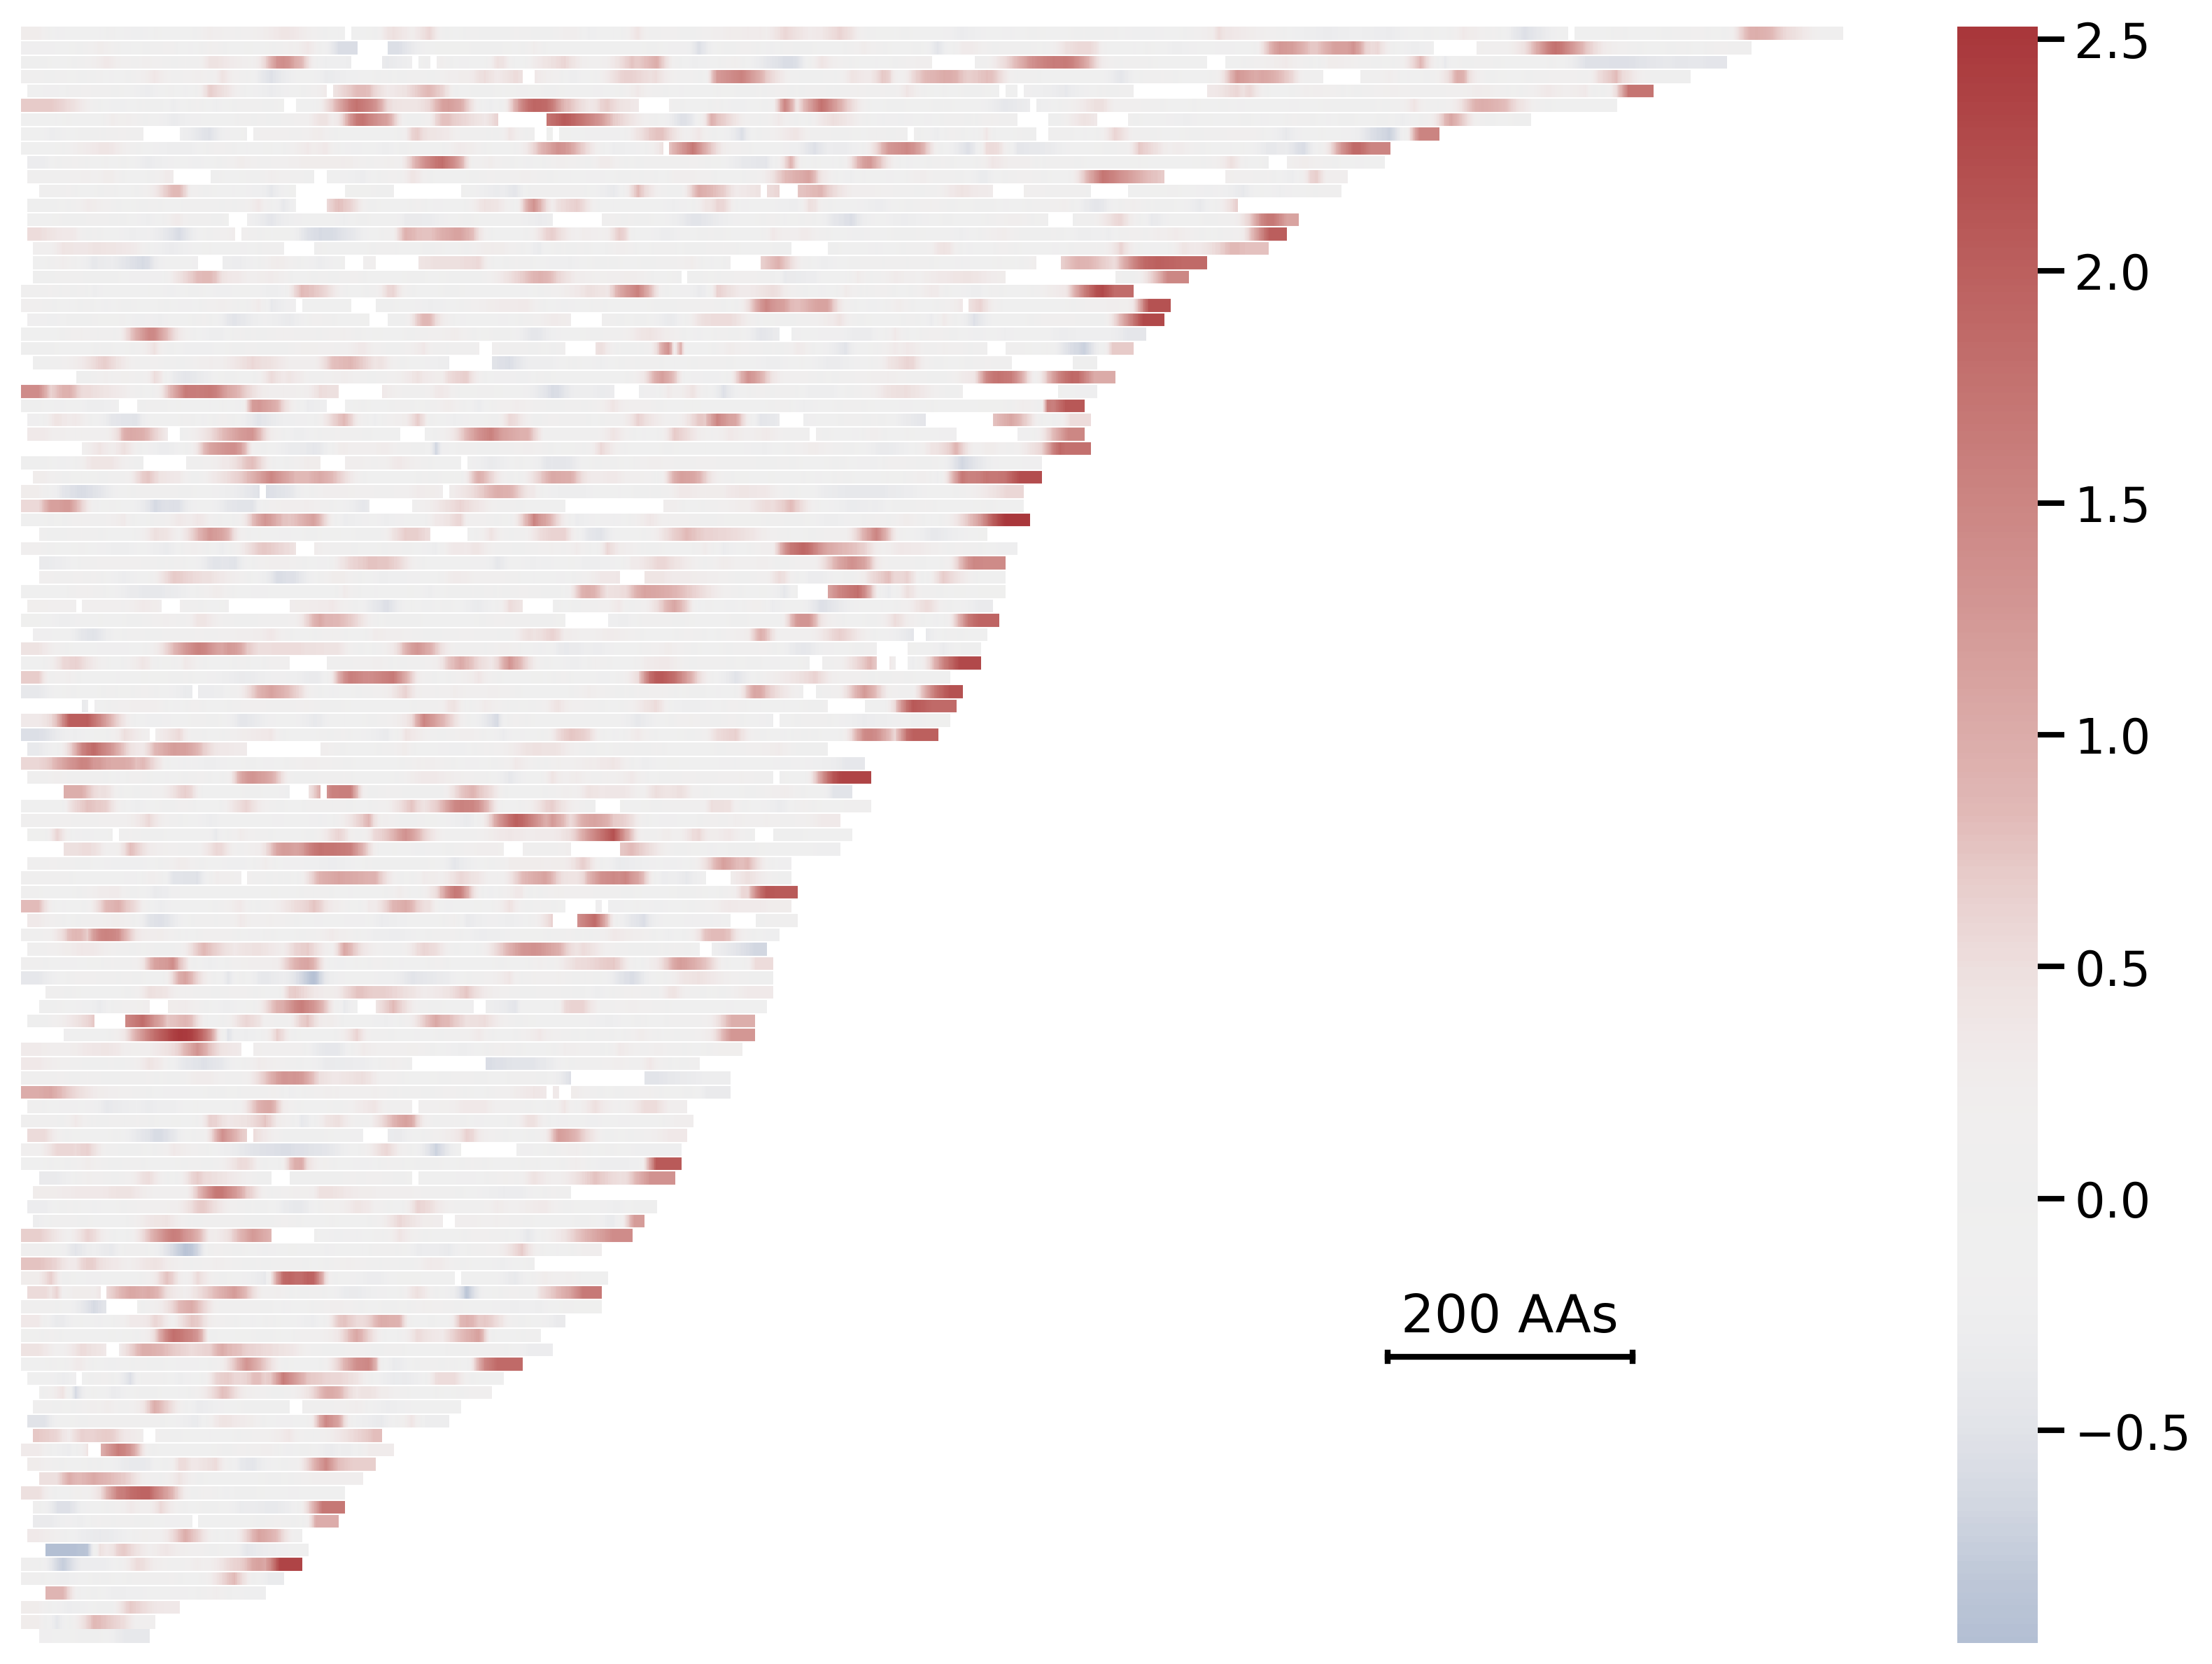

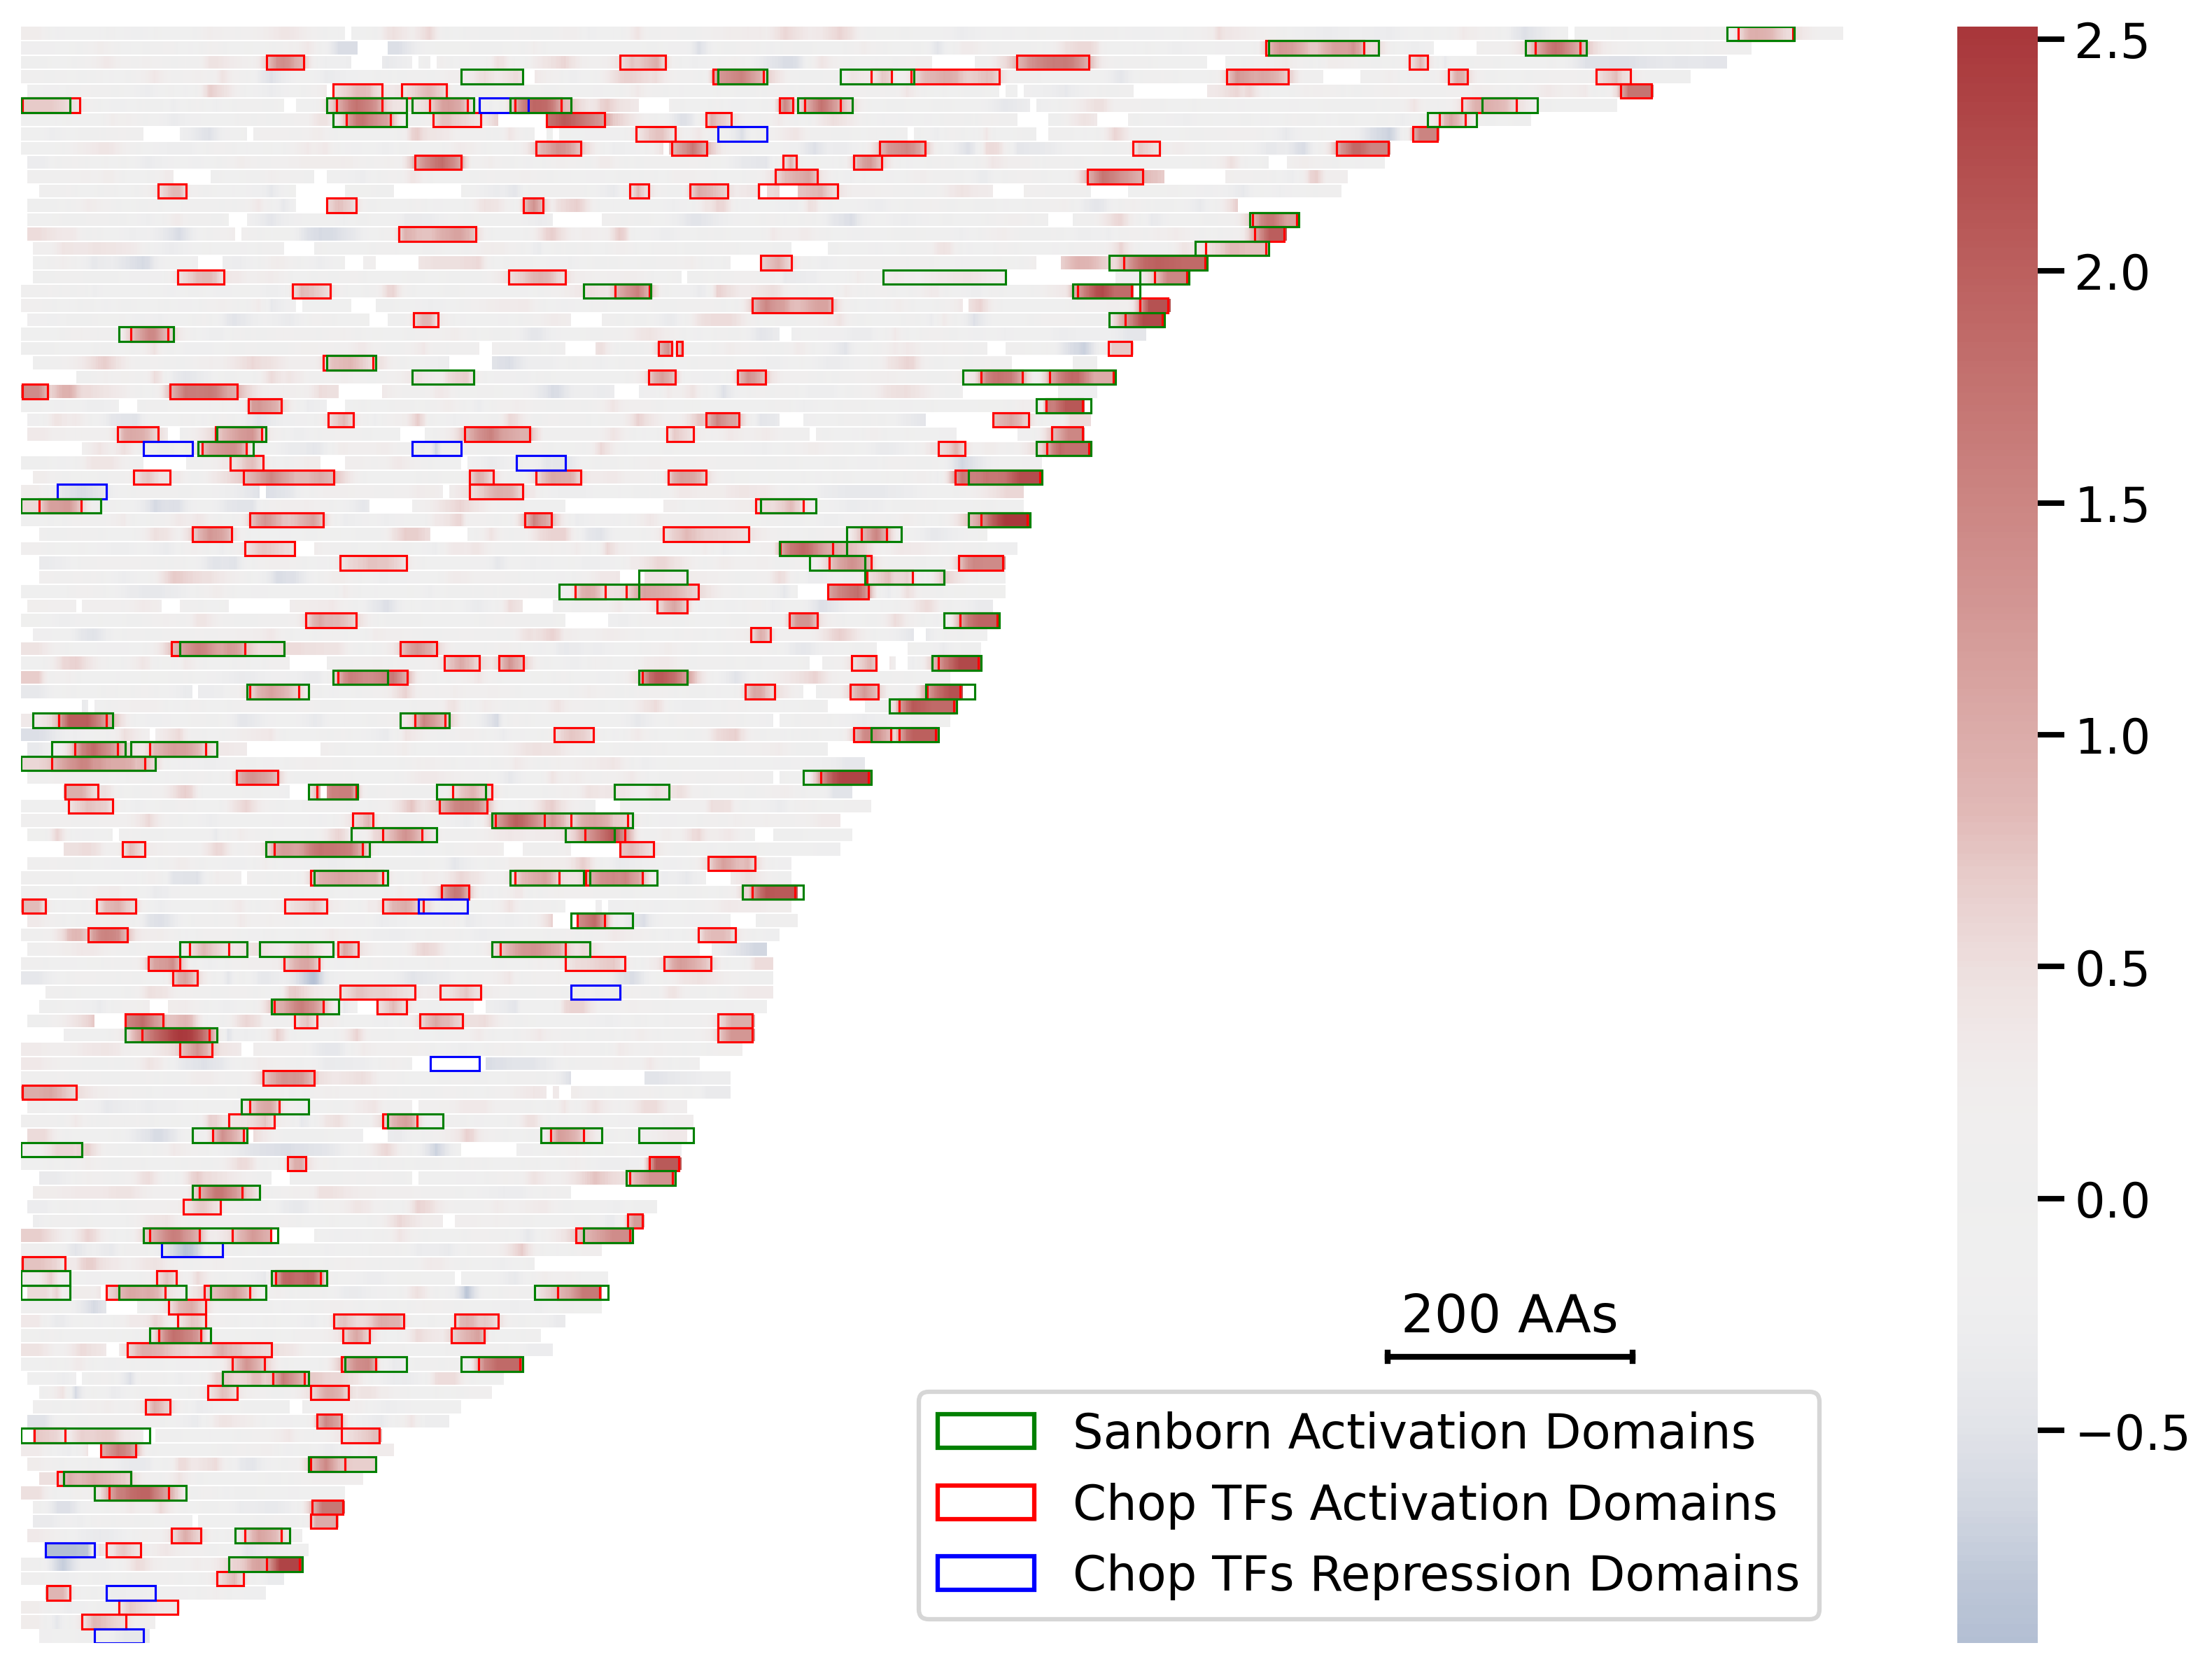

In [263]:
plot_heatmap(
    mat[mat.index.isin(ids)],
    should_add_boxes=False
)
plot_heatmap(
    mat[mat.index.isin(ids)],
    should_add_boxes=True,              
    ADs = stricter_ads_merged
)


In [237]:
# Only 2 of our ADs lie within TFs which are known repressors
set(pd.DataFrame(our_activators_merged)[0]) & set(RD_ids)

{'YKL038W', 'YNL216W'}

In [238]:
len(set(pd.DataFrame(our_activators_merged)[0]))

112

In [239]:
len(set(RD_ids))

8

# Visualizing heatmap

In [237]:
activity_pre_interp = merged_activities_with_sanborn[["id", "tile_center", "activity"]]
activity_pre_interp

,id,tile_center,activity
0,YBR049C,635,0.184532
1,YBR049C,610,0.261823
2,YKL032C,240,-0.065389
3,YBR267W,75,-0.281288
4,YKL062W,485,0.333446
...,...,...,...
11957,YMR280C,550,-0.214925
11958,YOR172W,615,0.544561
11959,YMR016C,190,0.115395
11960,YPL230W,230,0.540437


In [238]:
import numpy as np
import pandas as pd

def make_regular_grid(df, step=5, tol=1.0):
    out = []
    # preserve original uid order
    uid_order = df["id"].unique()  # maintains first-appearance order
    for uid in uid_order:
        g = df[df["id"] == uid].sort_values("tile_center")
        x = g["tile_center"].values
        y = g["activity"].values
        x_grid = np.arange(
            np.floor(x.min() / step) * step,
            np.ceil(x.max() / step) * step + step,
            step
        )
        y_grid = np.full_like(x_grid, np.nan, dtype=float)
        for xi, yi in zip(x, y):
            idx = np.argmin(np.abs(x_grid - xi))
            if abs(x_grid[idx] - xi) <= tol:
                y_grid[idx] = yi
        out.append(pd.DataFrame({
            "id": uid,
            "tile_center": x_grid,
            "activity": y_grid
        }))
    return pd.concat(out, ignore_index=True)

In [239]:
grid_df = make_regular_grid(merged_activities_with_sanborn)
grid_df

,id,tile_center,activity
0,YBR049C,25.0,0.107945
1,YBR049C,30.0,0.080145
2,YBR049C,35.0,NaN
3,YBR049C,40.0,-0.310197
4,YBR049C,45.0,-0.144562
...,...,...,...
18131,YCR018C,175.0,0.215066
18132,YCR018C,180.0,NaN
18133,YCR018C,185.0,NaN
18134,YCR018C,190.0,NaN


In [240]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_protein_heatmap(df, uniprot_id):
    g = df[df["id"] == uniprot_id].sort_values("tile_center")

    # reshape to 2D (required for heatmap)
    heat = g.set_index("tile_center")[["activity"]].T

    plt.figure(figsize=(12, 2))

    sns.heatmap(
        heat,
        cmap="coolwarm",
        center=0,
        cbar=True,
        linewidths=0,
        linecolor="none"
    )

    plt.xlabel("Tile center (AA)")
    plt.ylabel("")  # remove y label
    plt.yticks([])  # cleaner look
    plt.title(uniprot_id)

    plt.show()

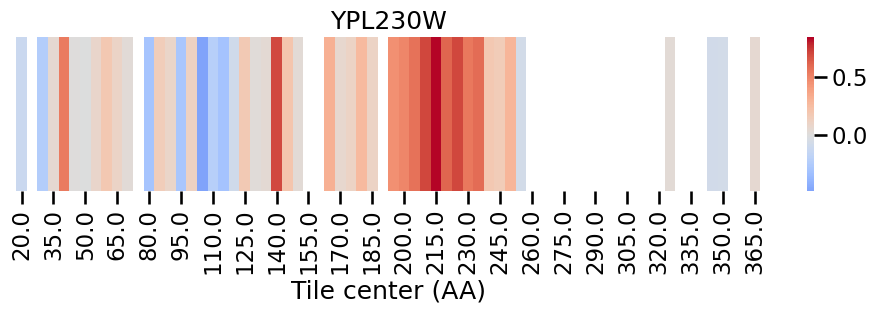

In [241]:
plot_protein_heatmap(grid_df, "YPL230W")

In [242]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d

def plot_protein_heatmap_smooth(df, uniprot_id, smooth_px=3):
    g = df[df["id"] == uniprot_id].sort_values("tile_center")
    centers_all = g["tile_center"].values
    activity_all = g["activity"].values

    x_fine = np.linspace(centers_all[0], centers_all[-1], 1000)
    y_fine = np.full_like(x_fine, np.nan)

    finite_mask = np.isfinite(activity_all)
    indices = np.where(finite_mask)[0]
    if len(indices) == 0:
        print(f"No finite data for {uniprot_id}")
        return

    breaks = np.where(np.diff(indices) > 1)[0] + 1
    segments = np.split(indices, breaks)

    # Estimate tile half-width from median spacing
    tile_hw = np.median(np.diff(centers_all)) / 2

    for seg in segments:
        cx = centers_all[seg]
        cy = activity_all[seg]

        if len(seg) == 1:
            # Single tile: fill a flat block of its own width
            in_range = (x_fine >= cx[0] - tile_hw) & (x_fine <= cx[0] + tile_hw)
            y_fine[in_range] = cy[0]
        else:
            y_seg = np.interp(x_fine, cx, cy)
            in_range = (x_fine >= cx[0]) & (x_fine <= cx[-1])
            y_fine[in_range] = y_seg[in_range]

    # Gaussian blur only over valid regions
    valid = np.isfinite(y_fine)
    if valid.any():
        y_blurred = y_fine.copy()
        y_blurred[valid] = gaussian_filter1d(y_fine[valid], sigma=smooth_px)
        center_positions = np.searchsorted(x_fine, centers_all[finite_mask])
        blend = np.ones_like(y_fine)
        for cp in center_positions:
            lo = max(0, cp - smooth_px)
            hi = min(len(blend), cp + smooth_px + 1)
            w = np.linspace(1, 0, cp - lo + 1)
            blend[lo:cp+1] = np.minimum(blend[lo:cp+1], w)
            w2 = np.linspace(0, 1, hi - cp)
            blend[cp:hi] = np.minimum(blend[cp:hi], w2)
        y_final = blend * y_blurred + (1 - blend) * y_fine
        y_final[~valid] = np.nan
    else:
        y_final = y_fine

    data_2d = y_final.reshape(1, -1)
    finite_vals = activity_all[finite_mask]
    vmax = np.abs(finite_vals).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(12, 1.5))
    im = ax.imshow(
        data_2d,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        extent=[centers_all[0], centers_all[-1], 0, 1],
        interpolation="none",
    )
    ax.set_xticks(centers_all[::max(1, len(centers_all)//10)])
    ax.set_yticks([])
    ax.set_xlabel("Tile center (AA)")
    ax.set_title(uniprot_id)
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2597871/437294833.py:80: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


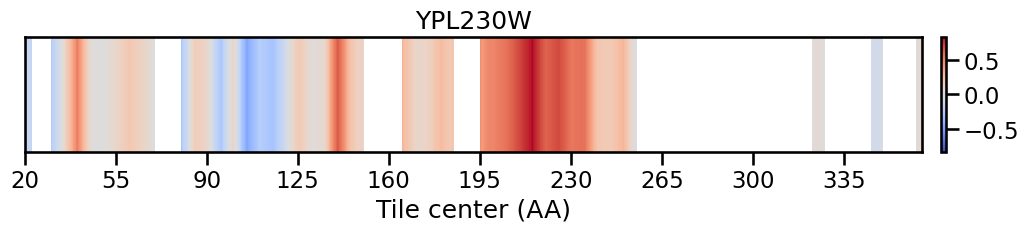

In [243]:
plot_protein_heatmap_smooth(grid_df, "YPL230W")

In [244]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d

def build_row(centers_all, activity_all, x_fine, smooth_px=3):
    """Build a single smoothed row for one protein."""
    y_fine = np.full_like(x_fine, np.nan)
    finite_mask = np.isfinite(activity_all)
    indices = np.where(finite_mask)[0]
    if len(indices) == 0:
        return y_fine

    breaks = np.where(np.diff(indices) > 1)[0] + 1
    segments = np.split(indices, breaks)
    tile_hw = np.median(np.diff(centers_all)) / 2

    for seg in segments:
        cx = centers_all[seg]
        cy = activity_all[seg]
        if len(seg) == 1:
            in_range = (x_fine >= cx[0] - tile_hw) & (x_fine <= cx[0] + tile_hw)
            y_fine[in_range] = cy[0]
        else:
            in_range = (x_fine >= cx[0]) & (x_fine <= cx[-1])
            y_fine[in_range] = np.interp(x_fine[in_range], cx, cy)

    valid = np.isfinite(y_fine)
    if valid.any():
        y_blurred = y_fine.copy()
        y_blurred[valid] = gaussian_filter1d(y_fine[valid], sigma=smooth_px)
        center_positions = np.searchsorted(x_fine, centers_all[finite_mask])
        blend = np.ones_like(y_fine)
        for cp in center_positions:
            lo, hi = max(0, cp - smooth_px), min(len(blend), cp + smooth_px + 1)
            blend[lo:cp+1] = np.minimum(blend[lo:cp+1], np.linspace(1, 0, cp - lo + 1))
            blend[cp:hi] = np.minimum(blend[cp:hi], np.linspace(0, 1, hi - cp))
        y_final = blend * y_blurred + (1 - blend) * y_fine
        y_final[~valid] = np.nan
        return y_final
    return y_fine


def plot_protein_heatmap_multi(df, uniprot_ids, smooth_px=3, row_height=0.1):
    # Build a shared x axis across all proteins
    all_centers = df[df["id"].isin(uniprot_ids)]["tile_center"]
    x_min, x_max = all_centers.min(), all_centers.max()
    x_fine = np.linspace(x_min, x_max, 1000)

    rows = []
    for uid in uniprot_ids:
        g = df[df["id"] == uid].sort_values("tile_center")
        if g.empty:
            rows.append(np.full_like(x_fine, np.nan))
            continue
        rows.append(build_row(g["tile_center"].values, g["activity"].values, x_fine, smooth_px))

    data_2d = np.vstack(rows)

    # Shared color scale centered at 0
    vmax = np.nanmax(np.abs(data_2d))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad(color="white")

    n = len(uniprot_ids)
    fig, ax = plt.subplots(figsize=(14, row_height * n + 1))
    im = ax.imshow(
        data_2d,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        extent=[x_min, x_max, n, 0],
        interpolation="none",
    )

    ax.set_yticks([])
    # ax.set_yticklabels(uniprot_ids, fontsize=9)
    ax.set_xlabel("Tile center (AA)")
    ax.set_title("Protein activity heatmap")
    ax.tick_params(axis="y", length=0)  # hide tick marks, keep labels

    # Horizontal grid lines between rows
    for i in range(1, n):
        ax.axhline(i, color="white", linewidth=0.8)

    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02, label="Activity")
    plt.tight_layout()
    sns.despine()
    plt.show()

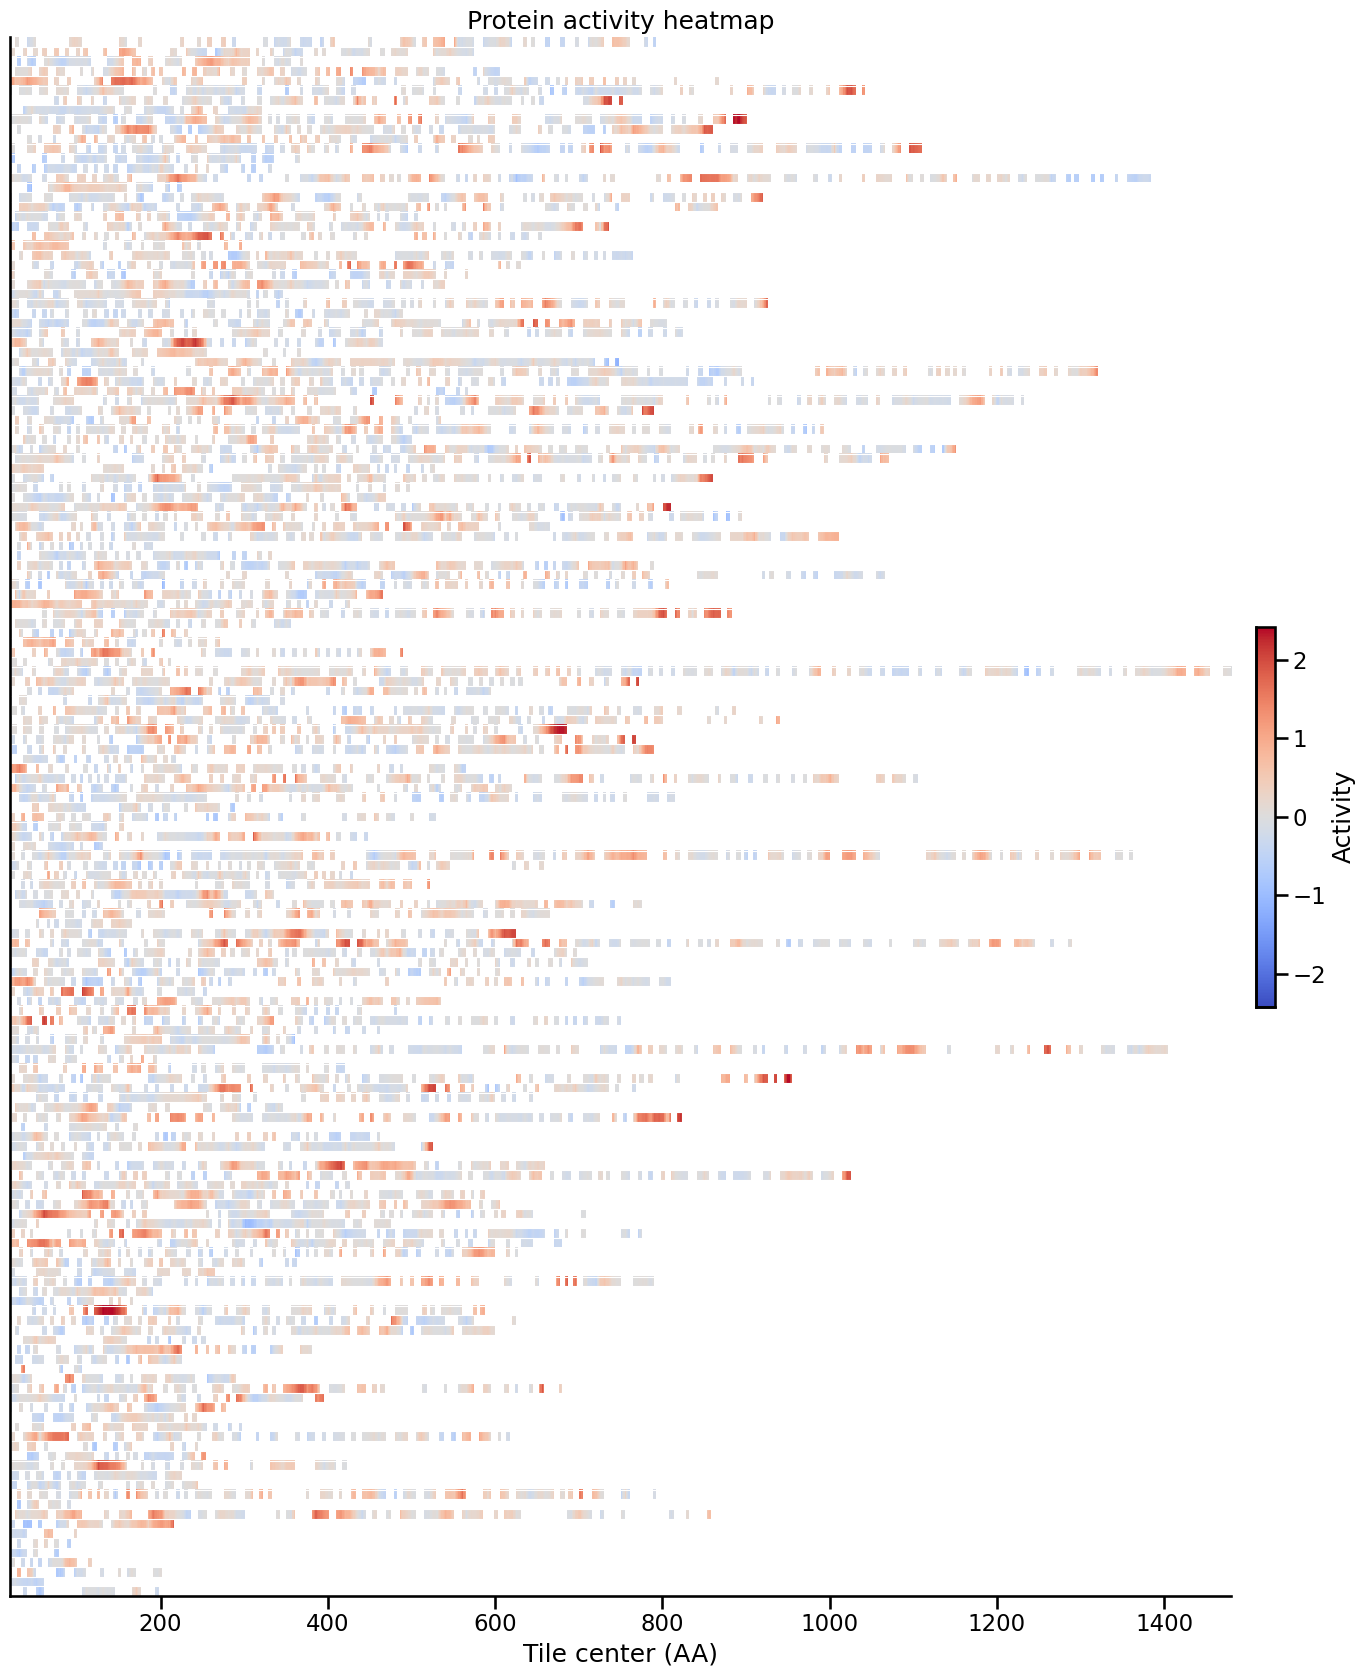

In [245]:
plot_protein_heatmap_multi(grid_df, grid_df["id"].unique())

In [246]:
activator_ids = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"]["id"].unique()
len(activator_ids)

127

In [247]:
merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"].sort_values(by = "activity")

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center,sanborn
3287,HQNQPHDGHNHEQHQTVQKDMQTHESLEIMGNTLLEEFKD,60,0.162729,-0.120684,0.453215,activator,0.704195,0.000558,0.573899,YGL071W,636,676,650,655,no
8447,RDTFDQLMNATVGNLIERCGPDSSELIFMASSVAKRTEPK,60,0.208839,-0.005705,0.438068,activator,0.601852,0.000558,0.443772,YLR278C,721,761,1301,740,no
5310,LLDSGDSFYHPVFKILQNDIKIIELKNDEMFSLIKGLGSL,60,0.245648,0.089292,0.465952,activator,0.601960,0.000558,0.376660,YMR168C,526,566,568,545,no
3130,HFNDIGFIYSPPSSRSSIPNKSPPNHSATSLNHEKASLSP,60,0.291452,-0.130696,0.730234,activator,0.654190,0.009344,0.860930,YJR127C,611,651,1340,630,no
2159,EYSSVDMSNLLNVHQNNTDLPHNIIEPSDYGDYVKKPRVV,60,0.304432,0.171138,0.455617,activator,0.612496,0.000558,0.284478,YBR182C,56,96,412,75,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10491,TILNDLEGPLEDFSENFIDDILGSPSAFFDTAISGWSNFE,60,2.345336,2.112537,2.553890,activator,1.607470,0.000558,0.441353,YKL222C,661,701,665,680,yes
6337,NDITTALLNNELFQGPSLSDEVTDWFGASEDIGLEFVEPW,60,2.349543,2.104368,2.679645,activator,1.577932,0.000558,0.575276,YDR421W,866,906,910,885,yes
3064,GWDTSLPIDFDFDEFNTETTDFDDFLKLLGDNSPSKEQKS,60,2.407588,2.245301,2.607114,activator,1.296800,0.000558,0.361813,YNR063W,121,161,567,140,yes
10642,TNDAVIFNNDGWDTSLPIDFDFDEFNTETTDFDDFLKLLG,60,2.439449,2.316593,2.607036,activator,1.443655,0.000558,0.290443,YNR063W,111,151,567,130,yes


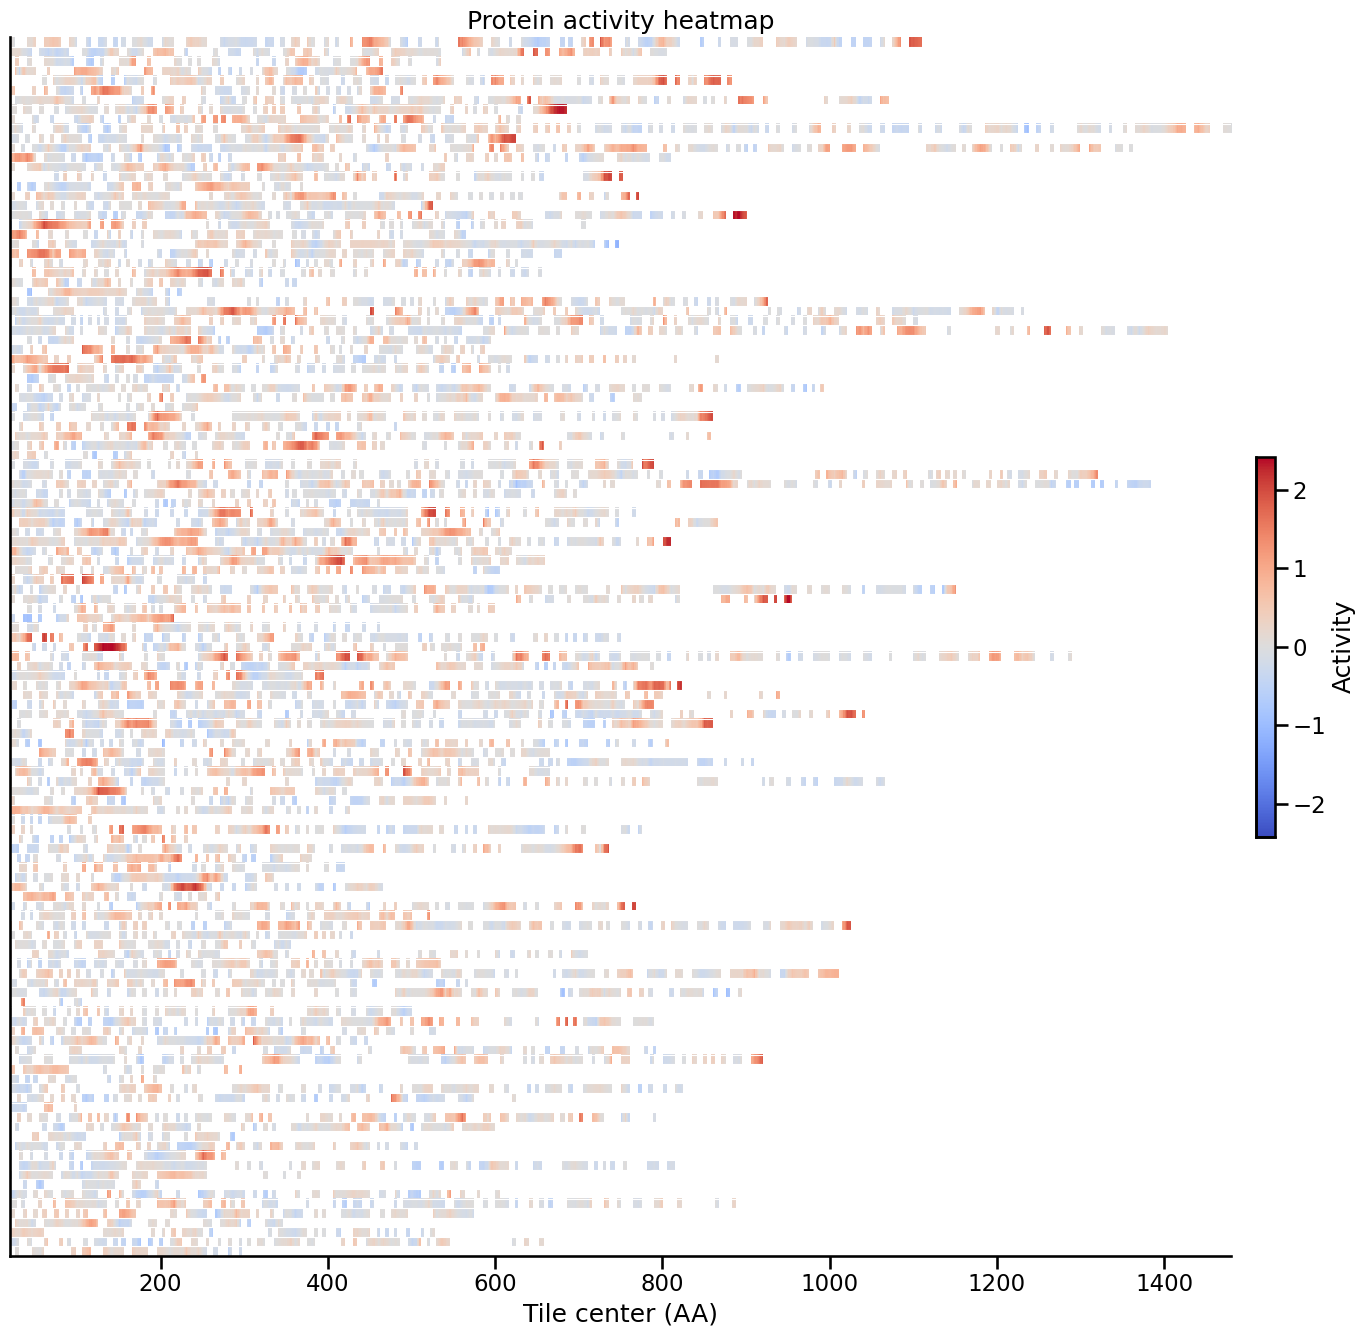

In [248]:
plot_protein_heatmap_multi(grid_df, activator_ids)

# Old

In [249]:
def merge_intervals(intervals):
    """
    intervals: list of (start, end)
    returns merged non-overlapping intervals
    """
    if not intervals:
        return []
    
    # sort by start
    intervals = sorted(intervals, key=lambda x: x[0])
    
    merged = [intervals[0]]
    
    for curr_start, curr_end in intervals[1:]:
        prev_start, prev_end = merged[-1]
        
        if curr_start <= prev_end:  # overlap OR touching
            merged[-1] = (prev_start, max(prev_end, curr_end))
        else:
            merged.append((curr_start, curr_end))
    
    return merged

In [250]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from matplotlib.patches import Rectangle

sns.set_context("talk")

def plot_heatmap_with_boxes(df, sigma=2, grid_step=1):
    df = df.copy()
    
    # ---- TF lengths ----
    tf_lengths = (
        df.groupby("uniprotID")
        .agg(min_pos=("tile_start", "min"),
             max_pos=("tile_end", "max"))
    )
    tf_lengths["length"] = tf_lengths["max_pos"] - tf_lengths["min_pos"]
    
    smoothed_rows = []
    
    # ---- smooth per TF ----
    for tf, sub in df.groupby("uniprotID"):
        sub = sub.sort_values("tile_center")
        
        x = sub["tile_center"].values
        y = sub["activity"].values
        
        x_new = np.arange(sub["tile_start"].min(), sub["tile_end"].max(), grid_step)
        
        f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
        y_interp = f(x_new)
        y_smooth = gaussian_filter1d(
            np.nan_to_num(y_interp, nan=np.nanmean(y_interp)),
            sigma=sigma
        )
        
        smoothed_rows.append(pd.DataFrame({
            "uniprotID": tf,
            "position": x_new,
            "activity": y_smooth
        }))
    
    df_smooth = pd.concat(smoothed_rows)
    
    # ---- pivot ----
    heatmap_df = df_smooth.pivot(
        index="uniprotID",
        columns="position",
        values="activity"
    )
    
    # ---- sort ----
    ordered = tf_lengths.sort_values("length", ascending=False).index
    heatmap_df = heatmap_df.loc[ordered]
    
    # ---- plot heatmap ----
    plt.figure(figsize=(14, 14), dpi=300)
    ax = sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        center=0,
        cbar_kws={"label": "Smoothed activity"}
    )
    
    # ---- overlay boxes ----
    from matplotlib.patches import Rectangle

    # map TF → row index
    tf_to_y = {tf: i for i, tf in enumerate(heatmap_df.index)}
    
    for tf, sub in df.groupby("uniprotID"):
        
        y = tf_to_y.get(tf)
        if y is None:
            continue
        
        # ---- collect intervals per class ----
        act_intervals = []
        rep_intervals = []
        
        for _, row in sub.iterrows():
            if row["class"] == "activator":
                act_intervals.append((row["tile_start"], row["tile_end"]))
            elif row["class"] == "repressor":
                rep_intervals.append((row["tile_start"], row["tile_end"]))
        
        # ---- merge them ----
        act_merged = merge_intervals(act_intervals)
        rep_merged = merge_intervals(rep_intervals)

        sanborn_intervals = []
        
        for _, row in sub.iterrows():
            if row["sanborn"] == "yes":
                sanborn_intervals.append((row["tile_start"], row["tile_end"]))
        
        sanborn_merged = merge_intervals(sanborn_intervals)
        
        # ---- draw activator boxes ----
        for start, end in act_merged:
            rect = Rectangle(
                (start, y),
                end - start,
                1,
                fill=False,
                edgecolor="red",
                linewidth=0.5
            )
            ax.add_patch(rect)
        
        # # ---- draw repressor boxes ----
        # for start, end in rep_merged:
        #     rect = Rectangle(
        #         (start, y),
        #         end - start,
        #         1,
        #         fill=False,
        #         edgecolor="blue",
        #         linewidth=0.2
        #     )
        #     ax.add_patch(rect)

    plt.yticks([])
    
    # ---- labels ----
    plt.xlabel("Position")
    plt.ylabel("TF (sorted by length)")
    plt.title("Smoothed Activity with Tile-Level Functional Boxes")
    
    plt.tight_layout()
    plt.show()

In [251]:
plot_heatmap_with_boxes(merged)

NameError: name 'merged' is not defined

In [ ]:
sanborn_ADs = pd.read_excel("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/sanborn_known_ADs_elife-68068-fig1-data2-v3.xlsx")
sanborn_ADs = sanborn_ADs.rename(columns = {"protein ID" : "uniprotID"})
sanborn_ADs

In [ ]:
tiles = []

for _, row in sanborn_ADs.iterrows():
    tf_id = row["uniprotID"]
    seq = row["sequence"]

    for i in range(len(seq) - 39):   # 40-mer window
        tile = seq[i:i+40]
        tiles.append({
            "seq": tile,
            "uniprotID": tf_id,
            "tile_start": i + 1,
            "tile_end": i + 40
        })

sanborn_tiles_df = pd.DataFrame(tiles)
sanborn_tiles_df["sanborn"] = "yes"
sanborn_tiles_df

In [ ]:
merged = merged.merge(
    sanborn_tiles_df[["seq", "sanborn"]],
    on="seq",
    how="left"
)
merged

In [ ]:
merged["sanborn"] = merged["sanborn"].fillna("no")
merged

In [ ]:
merged[["class", "sanborn"]].value_counts()

In [ ]:
from collections import defaultdict
import numpy as np
import pandas as pd

# store activities per residue per TF
activity_per_pos = defaultdict(list)

for _, row in merged.iterrows():
    if pd.isna(row["tile_start"]) or pd.isna(row["tile_end"]):
        continue  # skip tiles with no TF
    tf = row["uniprotID"]
    start = int(row["tile_start"])
    end = int(row["tile_end"])
    activity = row["activity"]
    
    # assign activity to every position in this tile
    for pos in range(start, end + 1):
        activity_per_pos[(tf, pos)].append(activity)

residues = []
for (tf, pos), acts in activity_per_pos.items():
    residues.append({
        "uniprotID": tf,
        "position": pos,
        "activity_mean": np.nanmean(acts)  # ignores NaNs in the mean
    })

df_residues = pd.DataFrame(residues)
df_residues

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

sns.set_context('talk')

def plot_tf_traces(tf_id, activity_col="Activity", sigma=1):
    """
    Plots 2 vertically stacked traces for a single TF:
    1. Raw tile activity
    2. Smoothed tile activity
    """
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10,5), dpi=300)
    
    # ---- Raw tile activity ----
    tf_tiles = merged[merged["uniprotID"] == tf_id].sort_values("tile_center")
    
    sns.lineplot(
        data=tf_tiles, 
        x="tile_center", 
        y="activity", 
        ax=axs[0], 
        label="Tile activity"
    )
    
    # ---- Smoothed tile activity ----
    smoothed = gaussian_filter1d(tf_tiles["activity"].values, sigma=sigma)
    
    axs[1].plot(
        tf_tiles["tile_center"], 
        smoothed, 
        label=f"Smoothed (σ={sigma})"
    )
    axs[1].legend()
    
    # ---- Labels ----
    axs[1].set_xlabel("Position")
    axs[0].set_ylabel("")
    fig.supylabel(activity_col, x=-0.01)
    plt.suptitle(f"{tf_id} WT")
    
    sns.despine()
    plt.tight_layout(pad=0.5)
    plt.show()

# Example usage
plot_tf_traces("P03069", activity_col="Activity")

In [ ]:
df = merged.copy()

df["tile_center"] = (df["tile_start"] + df["tile_end"]) / 2

df_mean = (
    df.groupby(["uniprotID", "tile_center"])
    ["activity"]
    .mean()
    .reset_index()
)

df_mean

In [ ]:
tf_lengths = (
    df.groupby("uniprotID")["tile_end"]
    .max()
    .sort_values(ascending=False)
)
tf_lengths

In [ ]:
heatmap_df = df_mean.pivot(
    index="uniprotID",
    columns="tile_center",
    values="activity"
)

heatmap_df = heatmap_df.loc[tf_lengths.index]
heatmap_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_df,
    cmap="Reds",
    center=0,
    vmin=-1,
    vmax=1
)

plt.xlabel("Protein position")
plt.ylabel("TF (longest → shortest)")
sns.despine()
plt.show()

In [ ]:
min(df_residues["activity_mean"])

In [ ]:
max(df_residues["activity_mean"])

In [ ]:
sanborn_ADs = pd.read_excel("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/sanborn_known_ADs_elife-68068-fig1-data2-v3.xlsx")
sanborn_ADs = sanborn_ADs.rename(columns = {"protein ID" : "uniprotID"})
sanborn_ADs

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

# -------------------------
# 1. Determine TF order
tf_lengths = df.groupby("uniprotID")["tile_end"].max().sort_values(ascending=False)

# -------------------------
# 2. Pivot df_residues
heatmap_df = df_residues.pivot(
    index="uniprotID",
    columns="position",
    values="activity_mean"
)

heatmap_df = heatmap_df.loc[tf_lengths.index]

# -------------------------
# 3. Smooth each row without affecting NaNs
heatmap_array = heatmap_df.values
nan_mask = np.isnan(heatmap_array)

heatmap_filled = np.where(nan_mask, 0, heatmap_array)

smoothed_array = gaussian_filter1d(
    heatmap_filled,
    sigma=2,
    axis=1
)

smoothed_array[nan_mask] = np.nan

smoothed_heatmap = pd.DataFrame(
    smoothed_array,
    index=heatmap_df.index,
    columns=heatmap_df.columns
)

# -------------------------
# 4. Mask inactive residues (≤2)
threshold = 2

smoothed_heatmap_masked = smoothed_heatmap.where(
    smoothed_heatmap > threshold
)

# -------------------------
# 5. Colormap setup
cmap = sns.color_palette("Reds", as_cmap=True)
cmap.set_under("white")

norm = Normalize(
    vmin=threshold,
    vmax=np.nanmax(smoothed_heatmap_masked)
)

# -------------------------
# 6. Plot heatmap
sns.set_style("white")

fig, ax = plt.subplots(
    figsize=(12,10),
    dpi=150
)

hm = sns.heatmap(
    smoothed_heatmap_masked,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6
    },
    ax=ax
)

# -------------------------
# 7. Format axes
plt.yticks([])
plt.ylabel("")
plt.xlabel("Protein position")

plt.gcf().patch.set_facecolor('white')

# -------------------------
# 8. Highlight activation threshold on colorbar
cbar = hm.collections[0].colorbar

cbar.ax.axhline(
    threshold,
    color="black",
    lw=2
)

cbar.set_label("Residue activity (active > 2)")

# optional cleaner ticks
cbar.set_ticks([
    threshold,
    threshold+1,
    threshold+2,
    threshold+3
])

# -------------------------
# 9. Overlay AD boxes
for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="black",
        facecolor="none",
        lw=1.2
    )

    ax.add_patch(rect)

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

neg_thresh = -2
pos_thresh = 2

# Get finite data range (ignore NaNs)
data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# Make sure bounds extend beyond thresholds
lower = min(data_min, neg_thresh - 1)
upper = max(data_max, pos_thresh + 1)

# Define discrete colormap
cmap = ListedColormap(["blue", "lightgray", "red"])

# Use FINITE bounds (this fixes your crash)
bounds = [lower, neg_thresh, pos_thresh, upper]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(12,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,   # <-- NOT masked anymore
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6,
        "ticks": [neg_thresh, 0, pos_thresh]
    },
    ax=ax
)
plt.show()

In [ ]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt

#data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

norm = TwoSlopeNorm(
    vmin=-1 * data_max,
    vcenter=0,
    vmax=data_max
)

cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6
    },
    ax=ax
)

for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="black",
        facecolor="none",
        lw=0.75
    )

    ax.add_patch(rect)


plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import numpy as np

# zero-centered normalization
data_max = np.nanmax(smoothed_heatmap.values)
norm = TwoSlopeNorm(vmin=-data_max, vcenter=0, vmax=data_max)
cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# draw heatmap
hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# iterate over each protein (row)
for row_idx, uniprot in enumerate(smoothed_heatmap.index):
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 2  # boolean array

    # find consecutive stretches above threshold
    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 5:  # keep regions ≥5 residues
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="black",
                    facecolor="none",
                    lw=0.75
                )
                ax.add_patch(rect)
    # handle region that goes to the end
    if in_region and len(row_data) - start_idx >= 5:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="black",
            facecolor="none",
            lw=0.75
        )
        ax.add_patch(rect)

for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="limegreen",
        facecolor="none",
        lw=0.75
    )

    ax.add_patch(rect)



plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

neg_thresh = -2
pos_thresh = 2

data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# --- make symmetric
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

# positions in [0,1]
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

# --- colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

fig, ax = plt.subplots(figsize=(16,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# --- white border around each TF row
for row_idx in range(len(smoothed_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=smoothed_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- draw Sanborn ADs first (background)
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.75
    )
    ax.add_patch(rect)

# --- draw newly detected ADs on top
for row_idx, uniprot in enumerate(smoothed_heatmap.index):
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 2

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 10:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=1.2
                )
                ax.add_patch(rect)
    if in_region and len(row_data) - start_idx >= 10:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="limegreen",
            facecolor="none",
            lw=1.2
        )
        ax.add_patch(rect)

# --- remove full x-axis labels
ax.set_yticklabels([])
ax.set_ylabel("")

# x ticks
n_cols = smoothed_heatmap.shape[1]

# set x-ticks every 50 residues
xticks = np.arange(0, n_cols, 100)
ax.set_xticks(xticks)

# optionally label them with actual residue numbers
ax.set_xticklabels(xticks)  # +1 if residue indexing starts at 1

# rotate if needed for readability
plt.xticks(rotation=0)

fig.suptitle("ChopTFs vs Sanborn", x= 0.4)

from matplotlib.patches import Patch

# --- create a legend patch for newly detected ADs
new_ad_patch = Patch(
    edgecolor="limegreen",
    facecolor="none",
    lw=1.2,
    label="TREBL ADs"
)

old_ad_patch = Patch(
    edgecolor="gray",
    facecolor="none",
    lw=1.2,
    label="Sanborn ADs"
)

# add legend to the heatmap
ax.legend(
    handles=[new_ad_patch, old_ad_patch],
    loc="upper right",  # adjust as needed
    fontsize=10,
    bbox_to_anchor = (1,0.5)
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

neg_thresh = -2
pos_thresh = 2

data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# --- make symmetric
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

# positions in [0,1]
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

# --- colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

fig, ax = plt.subplots(figsize=(16,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# --- white border around each TF row
for row_idx in range(len(smoothed_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=smoothed_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- draw Sanborn ADs first (background)
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.75
    )
    ax.add_patch(rect)

# --- draw newly detected ADs on top
# for row_idx, uniprot in enumerate(smoothed_heatmap.index):
#     row_data = smoothed_heatmap.loc[uniprot].values
#     above_thresh = row_data > 2

#     in_region = False
#     start_idx = None
#     for i, val in enumerate(above_thresh):
#         if val and not in_region:
#             in_region = True
#             start_idx = i
#         elif not val and in_region:
#             in_region = False
#             if i - start_idx >= 10:
#                 rect = Rectangle(
#                     (start_idx, row_idx),
#                     width=i - start_idx,
#                     height=1,
#                     edgecolor="limegreen",
#                     facecolor="none",
#                     lw=1.2
#                 )
#                 ax.add_patch(rect)
#     if in_region and len(row_data) - start_idx >= 10:
#         rect = Rectangle(
#             (start_idx, row_idx),
#             width=len(row_data) - start_idx,
#             height=1,
#             edgecolor="limegreen",
#             facecolor="none",
#             lw=1.2
#         )
#         ax.add_patch(rect)

# --- remove full x-axis labels
ax.set_yticklabels([])
ax.set_ylabel("")

# x ticks
n_cols = smoothed_heatmap.shape[1]

# set x-ticks every 50 residues
xticks = np.arange(0, n_cols, 100)
ax.set_xticks(xticks)

# optionally label them with actual residue numbers
ax.set_xticklabels(xticks)  # +1 if residue indexing starts at 1

# rotate if needed for readability
plt.xticks(rotation=0)

fig.suptitle("ChopTFs vs Sanborn", x= 0.4)

from matplotlib.patches import Patch

# --- create a legend patch for newly detected ADs
new_ad_patch = Patch(
    edgecolor="limegreen",
    facecolor="none",
    lw=1.2,
    label="TREBL ADs"
)

old_ad_patch = Patch(
    edgecolor="gray",
    facecolor="none",
    lw=1.2,
    label="Sanborn ADs"
)

# add legend to the heatmap
ax.legend(
    handles=[new_ad_patch, old_ad_patch],
    loc="upper right",  # adjust as needed
    fontsize=10,
    bbox_to_anchor = (1,0.5)
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle
import seaborn as sns
from matplotlib.patches import Patch

sns.set_context('talk')

neg_thresh = -2
pos_thresh = 2

# --- Identify TFs with Sanborn ADs
sanborn_tfs = set(sanborn_ADs["uniprotID"])

# --- Identify TFs with TREBL ADs (newly detected ADs)
trebl_tfs = []
for uniprot in smoothed_heatmap.index:
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 1.5

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 10:
                trebl_tfs.append(uniprot)
    if in_region and len(row_data) - start_idx >= 10:
        trebl_tfs.append(uniprot)

trebl_tfs = set(trebl_tfs)

# --- Keep only TFs that have Sanborn or TREBL ADs
keep_tfs = list(sanborn_tfs.union(trebl_tfs))
filtered_heatmap = smoothed_heatmap.loc[smoothed_heatmap.index.isin(keep_tfs)]

# --- Normalize and colormap
data_min = np.nanmin(filtered_heatmap.values)
data_max = np.nanmax(filtered_heatmap.values)
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

# --- Plot
fig, ax = plt.subplots(figsize=(12,7), dpi=300)
hm = sns.heatmap(
    filtered_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6, "pad" : -0.15},
    ax=ax
)

# --- White border around each TF row
for row_idx in range(len(filtered_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=filtered_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- Sanborn ADs
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    if uniprot not in filtered_heatmap.index:
        continue
    row_idx = filtered_heatmap.index.get_loc(uniprot)
    start, end = ad["start"], ad["stop"]

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- TREBL ADs
for row_idx, uniprot in enumerate(filtered_heatmap.index):
    row_data = filtered_heatmap.loc[uniprot].values
    above_thresh = row_data > 2

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 5:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=1.2
                )
                ax.add_patch(rect)
    if in_region and len(row_data) - start_idx >= 5:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="limegreen",
            facecolor="none",
            lw=0.75
        )
        ax.add_patch(rect)

# --- Axes and ticks
ax.set_yticklabels([])
ax.set_ylabel("")
n_cols = filtered_heatmap.shape[1]
xticks = np.arange(0, n_cols, 200)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
plt.xticks(rotation=0)

# --- Legend
new_ad_patch = Patch(edgecolor="limegreen", facecolor="none", lw=1.2, label="TREBL ADs")
old_ad_patch = Patch(edgecolor="gray", facecolor="none", lw=1.2, label="Sanborn ADs")
ax.legend(handles=[new_ad_patch, old_ad_patch], loc="upper right", fontsize='small', bbox_to_anchor=(0.95,0.15))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle, Patch
import seaborn as sns

sns.set_context('talk')

# --- Prepare normalized colormap
data_min = np.nanmin(filtered_heatmap.values)
data_max = np.nanmax(filtered_heatmap.values)
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

neg_thresh = -1.5
pos_thresh = 1.5
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

# --- Helper function to plot heatmap with optional boxes
def plot_heatmap(filtered_heatmap, show_sanborn=False, show_trebl=False, figsize=(12,7), dpi=300):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Plot heatmap
    hm = sns.heatmap(
        filtered_heatmap,
        cmap=cmap,
        norm=norm,
        linewidths=0,
        cbar_kws={"label": "Residue activity", "shrink": 0.6, "pad" : -0.15},
        ax=ax
    )

    # --- White border around each TF row
    for row_idx in range(len(filtered_heatmap.index)):
        rect = Rectangle(
            (0, row_idx),
            width=filtered_heatmap.shape[1],
            height=1,
            edgecolor="white",
            facecolor="none",
            lw=0.5
        )
        ax.add_patch(rect)
        
    # Optional: Sanborn boxes
    if show_sanborn:
        for _, ad in sanborn_ADs.iterrows():
            uniprot = ad["uniprotID"]
            if uniprot not in filtered_heatmap.index:
                continue
            row_idx = filtered_heatmap.index.get_loc(uniprot)
            start, end = ad["start"], ad["stop"]
            rect = Rectangle(
                (start, row_idx),
                width=end-start+1,
                height=1,
                edgecolor="gray",
                facecolor="none",
                lw=0.5
            )
            ax.add_patch(rect)
    
    # Optional: TREBL boxes
    if show_trebl:
        for row_idx, uniprot in enumerate(filtered_heatmap.index):
            row_data = filtered_heatmap.loc[uniprot].values
            above_thresh = row_data > 2
            in_region = False
            start_idx = None
            for i, val in enumerate(above_thresh):
                if val and not in_region:
                    in_region = True
                    start_idx = i
                elif not val and in_region:
                    in_region = False
                    if i - start_idx >= 5:
                        rect = Rectangle(
                            (start_idx, row_idx),
                            width=i - start_idx,
                            height=1,
                            edgecolor="limegreen",
                            facecolor="none",
                            lw=1.2
                        )
                        ax.add_patch(rect)
            if in_region and len(row_data) - start_idx >= 5:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=len(row_data) - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=0.75
                )
                ax.add_patch(rect)
    
    # Axes and ticks
    ax.set_yticklabels([])
    ax.set_ylabel("")
    n_cols = filtered_heatmap.shape[1]
    xticks = np.arange(0, n_cols, 200)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    plt.xticks(rotation=0)
    
    # Legend if boxes are shown
    legend_handles = []
    if show_sanborn:
        legend_handles.append(Patch(edgecolor="gray", facecolor="none", lw=1.2, label="Sanborn ADs"))
    if show_trebl:
        legend_handles.append(Patch(edgecolor="limegreen", facecolor="none", lw=1.2, label="TREBL ADs"))
    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right", fontsize='small',
                  bbox_to_anchor=(0.95, 0.15), frameon=True, facecolor="white")
    
    plt.tight_layout()
    return fig, ax

# --- Plot versions
fig1, ax1 = plot_heatmap(filtered_heatmap, show_sanborn=False, show_trebl=False)  # Heatmap only
fig2, ax2 = plot_heatmap(filtered_heatmap, show_sanborn=True, show_trebl=False)   # Heatmap + Sanborn
fig3, ax3 = plot_heatmap(filtered_heatmap, show_sanborn=True, show_trebl=True)    # Heatmap + Sanborn + TREBL